# Pasting Algorithm Investigation: Power Spectrum Suppression

This notebook investigates why the power spectrum suppression is incorrect despite good individual halo generation.

**Hypotheses to test:**
1. **Mass conservation**: How sensitive is the power spectrum to mass errors in individual halos?
2. **Pasting algorithm**: Does the blending/weighting scheme introduce artifacts?
3. **Aliasing/discretization**: Are there aliasing effects from extracting and re-pasting?
4. **Overlap handling**: Do overlapping halos cause problems?

We'll use controlled toy problems to isolate each effect.

In [1]:
import sys
import os
from pathlib import Path
import warnings
from contextlib import redirect_stdout, redirect_stderr
import io

# Suppress warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
warnings.filterwarnings('ignore', message='.*InconsistentVersionWarning.*')

import logging
logging.getLogger('pytorch_lightning').setLevel(logging.WARNING)

# Add project root to path
PROJECT_ROOT = Path('/mnt/home/mlee1/vdm_BIND')
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.gridspec as gridspec
from tqdm import tqdm
import h5py

# Import BIND and utilities
from bind.bind import BIND, HaloPaster2D
from bind.config_loader import ConfigLoader, load_normalization_stats
from bind.power_spec import compute_power_spectrum_simple
from vdm.io_utils import load_simulation, project_particles_2d
from analysis.paper_utils import setup_plotting_style

setup_plotting_style()
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

/mnt/sw/nix/store/gpkc8q6zjnp3n3h3w9hbmbj6gjbxs85w-python-3.10.10-view/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/mnt/sw/nix/store/6qvrglgqdpwhbw9zv2nh07fpd7a4wq31-py-torchvision-0.15.2/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Using device: cuda


## 1. Setup: Load DMO and Hydro Fields

In [2]:
# Configuration
SIM_NUM = 0
SNAPNUM = 90

CAMELS_ROOT = Path('/mnt/ceph/users/camels/Sims')
DMO_PATH = CAMELS_ROOT / 'IllustrisTNG_DM' / 'L50n512' / 'CV' / f'CV_{SIM_NUM}'
HYDRO_PATH = CAMELS_ROOT / 'IllustrisTNG' / 'L50n512' / 'CV' / f'CV_{SIM_NUM}'

BOX_SIZE = 50000.0  # kpc/h
GRID_SIZE = 1024    # Resolution for voxelization
BOX_MPC = BOX_SIZE / 1000.0  # 50 Mpc/h

print(f"DMO: {DMO_PATH}")
print(f"Hydro: {HYDRO_PATH}")
print(f"Grid: {GRID_SIZE}^2, Pixel size: {BOX_MPC/GRID_SIZE:.4f} Mpc/h")

DMO: /mnt/ceph/users/camels/Sims/IllustrisTNG_DM/L50n512/CV/CV_0
Hydro: /mnt/ceph/users/camels/Sims/IllustrisTNG/L50n512/CV/CV_0
Grid: 1024^2, Pixel size: 0.0488 Mpc/h


In [3]:
# Load DMO field
import MAS_library as MASL

snappath = f"{DMO_PATH}/snap_{SNAPNUM:03d}.hdf5"
with h5py.File(snappath, 'r') as f:
    dmo_coords = f['PartType1']['Coordinates'][:] / 1000.0  # kpc -> Mpc/h
    header = dict(f['Header'].attrs.items())
    dmo_mass_per_particle = header['MassTable'][1] * 1e10  # M_sun/h

# Project DMO to 2D (z-axis projection)
dmo_pos_2d = dmo_coords[:, :2].astype(np.float32)
dmo_mass = np.full(len(dmo_pos_2d), dmo_mass_per_particle, dtype=np.float32)
dmo_field = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.float32)
MASL.MA(dmo_pos_2d, dmo_field, BOX_MPC, MAS='CIC', W=dmo_mass, verbose=False)

print(f"DMO field: {dmo_field.shape}, total mass: {dmo_field.sum():.3e} M_sun/h")
print(f"Mean density: {dmo_field.mean():.3e}, Std: {dmo_field.std():.3e}")

DMO field: (1024, 1024), total mass: 1.041e+16 M_sun/h
Mean density: 9.926e+09, Std: 3.262e+10


In [4]:
# Load ground truth hydro field
hydro_snapdir = str(HYDRO_PATH / f'snapdir_{SNAPNUM:03d}')
_, _, hydro_dm_pos, hydro_dm_mass, gas_pos, gas_mass, star_pos, star_mass = load_simulation(
    str(DMO_PATH), hydro_snapdir, snapnum=SNAPNUM
)

# Project hydro components to 2D
dm_field = project_particles_2d(hydro_dm_pos, hydro_dm_mass, BOX_MPC, GRID_SIZE, axis=2)
gas_field = project_particles_2d(gas_pos, gas_mass, BOX_MPC, GRID_SIZE, axis=2)
star_field = project_particles_2d(star_pos, star_mass, BOX_MPC, GRID_SIZE, axis=2)

gt_total = dm_field + gas_field + star_field
print(f"Hydro total: {gt_total.shape}, total mass: {gt_total.sum():.3e} M_sun/h")
print(f"Mass fractions: DM={dm_field.sum()/gt_total.sum():.3f}, Gas={gas_field.sum()/gt_total.sum():.3f}, Stars={star_field.sum()/gt_total.sum():.3f}")

Hydro total: (1024, 1024), total mass: 1.041e+16 M_sun/h
Mass fractions: DM=0.837, Gas=0.159, Stars=0.004


In [5]:
# Load halo catalog
halopath = str(DMO_PATH).replace('Sims', 'FOF_Subfind')
hdf5_path = f"{halopath}/fof_subhalo_tab_{SNAPNUM:03d}.hdf5"

MASS_THRESHOLD = 1e13  # M_sun/h

with h5py.File(hdf5_path, 'r') as f:
    halo_positions = f['Group/GroupPos'][:] / 1000.0  # kpc -> Mpc
    halo_masses = f['Group/Group_M_Crit200'][:] * 1e10  # M_sun/h
    halo_radii = f['Group/Group_R_Crit200'][:] / 1000.0  # kpc -> Mpc

mask = halo_masses >= MASS_THRESHOLD
halo_positions = halo_positions[mask]
halo_masses = halo_masses[mask]
halo_radii = halo_radii[mask]

# Get 2D pixel coordinates
pix_size = BOX_MPC / GRID_SIZE
halo_centers_pix = (halo_positions[:, :2] / pix_size).astype(int)

print(f"Loaded {len(halo_masses)} halos above {MASS_THRESHOLD:.0e} M_sun/h")
print(f"Mass range: [{halo_masses.min():.2e}, {halo_masses.max():.2e}] M_sun/h")
print(f"Radius range: [{halo_radii.min():.3f}, {halo_radii.max():.3f}] Mpc/h")

Loaded 45 halos above 1e+13 M_sun/h
Mass range: [1.00e+13, 2.65e+14] M_sun/h
Radius range: [0.351, 1.045] Mpc/h


## 2. Compute Baseline Transfer Functions

Compute the ground truth transfer function T(k) = P_hydro(k) / P_DMO(k)


Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.02 seconds

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds


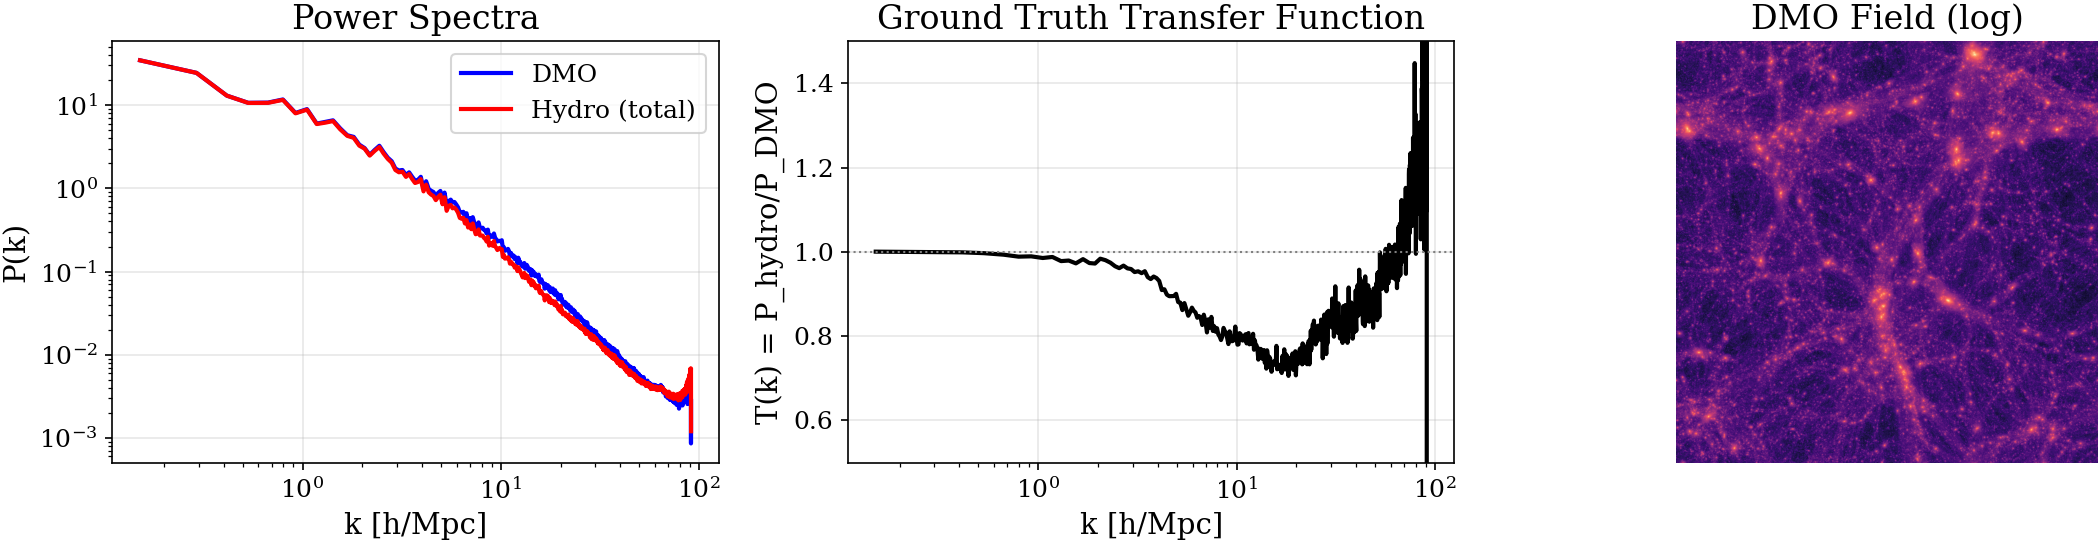


At k=1 h/Mpc: T = 0.9855
At k=0.5 h/Mpc: T = 0.9969
At k=10 h/Mpc: T = 0.7982


In [6]:
# Compute power spectra
dmo_pk, dmo_k = compute_power_spectrum_simple(dmo_field, BoxSize=BOX_MPC)
gt_pk, gt_k = compute_power_spectrum_simple(gt_total, BoxSize=BOX_MPC)

# Interpolate DMO to same k values as ground truth
dmo_pk_interp = np.interp(gt_k, dmo_k, dmo_pk)

# Ground truth transfer function
gt_transfer = gt_pk / dmo_pk_interp

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Power spectra
ax = axes[0]
ax.loglog(dmo_k, dmo_pk, 'b-', lw=2, label='DMO')
ax.loglog(gt_k, gt_pk, 'r-', lw=2, label='Hydro (total)')
ax.set_xlabel('k [h/Mpc]')
ax.set_ylabel('P(k)')
ax.set_title('Power Spectra')
ax.legend()
ax.grid(True, alpha=0.3)

# Transfer function
ax = axes[1]
ax.semilogx(gt_k, gt_transfer, 'k-', lw=2)
ax.axhline(1, color='gray', ls=':', lw=1)
ax.set_xlabel('k [h/Mpc]')
ax.set_ylabel('T(k) = P_hydro/P_DMO')
ax.set_title('Ground Truth Transfer Function')
ax.set_ylim(0.5, 1.5)
ax.grid(True, alpha=0.3)

# Fields
ax = axes[2]
ax.imshow(np.log10(dmo_field + 1), cmap='magma')
ax.set_title('DMO Field (log)')
ax.axis('off')

plt.tight_layout()
plt.show()

# Print key values
idx_k1 = np.argmin(np.abs(gt_k - 1.0))
print(f"\nAt k=1 h/Mpc: T = {gt_transfer[idx_k1]:.4f}")
print(f"At k=0.5 h/Mpc: T = {gt_transfer[np.argmin(np.abs(gt_k - 0.5))]:.4f}")
print(f"At k=10 h/Mpc: T = {gt_transfer[np.argmin(np.abs(gt_k - 10))]:.4f}")

## 3. Test 1: Identity Pasting (Sanity Check)

First, let's verify that extracting and re-pasting the SAME DMO field recovers the original power spectrum.
This tests whether the pasting algorithm itself introduces artifacts.

In [7]:
def extract_cutout_2d(field, center_mpc, cutout_size_mpc, box_size_mpc, gridsize):
    """
    Extract a 2D cutout from a field at a given position with periodic boundaries.
    """
    pix_size = box_size_mpc / gridsize
    half_cutout_pix = int(cutout_size_mpc / pix_size / 2)
    center_pix = (center_mpc / pix_size).astype(int)
    
    cutout_size_pix = 2 * half_cutout_pix
    cutout = np.zeros((cutout_size_pix, cutout_size_pix))
    
    for i in range(cutout_size_pix):
        for j in range(cutout_size_pix):
            ix = (center_pix[0] - half_cutout_pix + i) % gridsize
            jx = (center_pix[1] - half_cutout_pix + j) % gridsize
            cutout[i, j] = field[ix, jx]
    
    return cutout

def simple_paste_2d(original_map, patches, centers_pix, patch_size=128):
    """
    Simple pasting: directly replace pixels (no blending).
    """
    result = original_map.copy()
    grid_size = result.shape[0]
    half_patch = patch_size // 2
    
    for patch, center in zip(patches, centers_pix):
        for i in range(patch_size):
            for j in range(patch_size):
                ix = (center[0] - half_patch + i) % grid_size
                jx = (center[1] - half_patch + j) % grid_size
                result[ix, jx] = patch[i, j]
    
    return result

# Extract cutouts at halo locations from DMO field
CUTOUT_SIZE_MPC = 6.25  # Same as BIND

dmo_cutouts = []
for pos in halo_positions:
    center_2d = pos[:2]  # x, y in Mpc/h
    cutout = extract_cutout_2d(dmo_field, center_2d, CUTOUT_SIZE_MPC, BOX_MPC, GRID_SIZE)
    dmo_cutouts.append(cutout)

dmo_cutouts = np.array(dmo_cutouts)
print(f"Extracted {len(dmo_cutouts)} DMO cutouts, shape: {dmo_cutouts[0].shape}")

Extracted 45 DMO cutouts, shape: (128, 128)


In [8]:
# Test 1a: Simple paste (no blending) - paste identical DMO cutouts back
identity_simple = simple_paste_2d(dmo_field, dmo_cutouts, halo_centers_pix, patch_size=dmo_cutouts[0].shape[0])

# Compute power spectrum
identity_pk, identity_k = compute_power_spectrum_simple(identity_simple, BoxSize=BOX_MPC)
identity_pk_interp = np.interp(gt_k, identity_k, identity_pk)
identity_transfer = identity_pk_interp / dmo_pk_interp

# Compare
print("=== Test 1a: Identity Pasting (Simple) ===")
print(f"Original DMO total mass: {dmo_field.sum():.6e}")
print(f"After paste total mass:  {identity_simple.sum():.6e}")
print(f"Mass difference: {(identity_simple.sum() - dmo_field.sum())/dmo_field.sum()*100:.4f}%")
print(f"\nMax pixel difference: {np.abs(identity_simple - dmo_field).max():.6e}")
print(f"Mean pixel difference: {np.abs(identity_simple - dmo_field).mean():.6e}")

# Should be exactly 1.0 if pasting is perfect
print(f"\nTransfer at k=1: {identity_transfer[idx_k1]:.6f} (should be 1.0)")


Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds
=== Test 1a: Identity Pasting (Simple) ===
Original DMO total mass: 1.040812e+16
After paste total mass:  1.040812e+16
Mass difference: 0.0000%

Max pixel difference: 0.000000e+00
Mean pixel difference: 0.000000e+00

Transfer at k=1: 1.000000 (should be 1.0)


In [9]:
# Test 1b: Enhanced paste (with blending) - using BIND's HaloPaster2D
# Prepare patches in the format expected by HaloPaster2D: list of (n_realizations, n_channels, H, W)
# We'll use n_realizations=1, n_channels=1 (just DMO)
halo_patches_for_paster = []
for cutout in dmo_cutouts:
    # Format: (n_realizations, n_channels, H, W) -> sum over channels gives (H, W)
    halo_patches_for_paster.append(cutout[np.newaxis, np.newaxis, :, :])  # (1, 1, H, W)

# Convert radii from Mpc to kpc for paster
radii_kpc = halo_radii * 1000.0

# Test with different r_in/r_out factors
for r_in_factor, r_out_factor in [(1.0, 2.0), (1.0, 3.0), (2.0, 3.0), (2.0, 4.0)]:
    paster = HaloPaster2D(box_size_kpc=BOX_SIZE, r_in_factor=r_in_factor, r_out_factor=r_out_factor)
    
    enhanced_result, weight_map, halo_sum, dmo_contrib, total_weight = paster.enhanced_halo_pasting_2d(
        original_map=dmo_field,
        halo_patches=halo_patches_for_paster,
        centers_pixels=halo_centers_pix,
        radii_kpc=radii_kpc,
        realization=0
    )
    
    enhanced_pk, enhanced_k = compute_power_spectrum_simple(enhanced_result, BoxSize=BOX_MPC)
    enhanced_pk_interp = np.interp(gt_k, enhanced_k, enhanced_pk)
    enhanced_transfer = enhanced_pk_interp / dmo_pk_interp
    
    mass_diff = (enhanced_result.sum() - dmo_field.sum()) / dmo_field.sum() * 100
    print(f"r_in={r_in_factor}, r_out={r_out_factor}: T(k=1)={enhanced_transfer[idx_k1]:.4f}, mass_diff={mass_diff:.4f}%")


Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds
r_in=1.0, r_out=2.0: T(k=1)=1.0000, mass_diff=0.0000%

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds
r_in=1.0, r_out=3.0: T(k=1)=1.0000, mass_diff=0.0000%

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds
r_in=2.0, r_out=3.0: T(k=1)=1.0000, mass_diff=0.0000%

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds
r_in=2.0, r_out=4.0: T(k=1)=1.0000, mass_diff=0.0000%


## 4. Test 2: Mass Bias Sensitivity

**Key question**: How much does a systematic mass bias in the generated halos affect the power spectrum?

We'll apply uniform mass biases (±5%, ±10%, ±20%) to the pasted cutouts and measure the effect on T(k).

In [10]:
# Test 2: Mass bias sensitivity
mass_biases = [-0.20, -0.10, -0.05, 0.0, 0.05, 0.10, 0.20]  # ±20%, ±10%, ±5%
transfer_results = {}

for bias in mass_biases:
    # Apply mass bias to all cutouts
    biased_cutouts = [cutout * (1 + bias) for cutout in dmo_cutouts]
    
    # Simple paste
    biased_field = simple_paste_2d(dmo_field, biased_cutouts, halo_centers_pix, patch_size=dmo_cutouts[0].shape[0])
    
    # Compute power spectrum
    biased_pk, biased_k = compute_power_spectrum_simple(biased_field, BoxSize=BOX_MPC)
    biased_pk_interp = np.interp(gt_k, biased_k, biased_pk)
    biased_transfer = biased_pk_interp / dmo_pk_interp
    
    transfer_results[bias] = {
        'transfer': biased_transfer,
        'mass_total': biased_field.sum(),
        'T_k1': biased_transfer[idx_k1]
    }
    
    print(f"Bias = {bias:+.0%}: T(k=1) = {biased_transfer[idx_k1]:.4f}, Total mass = {biased_field.sum():.3e}")


Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds
Bias = -20%: T(k=1) = 0.8603, Total mass = 9.024e+15

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds
Bias = -10%: T(k=1) = 0.9333, Total mass = 9.716e+15

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds
Bias = -5%: T(k=1) = 0.9674, Total mass = 1.006e+16

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds
Bias = +0%: T(k=1) = 1.0000, Total mass = 1.041e+16

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds
Bias = +5%: T(k=1) = 1.0312, Total mass = 1.075e+16

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds
Bias = +10%: T(k=1) = 1.0610, Total mass = 1.110e+16

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds
Bias =

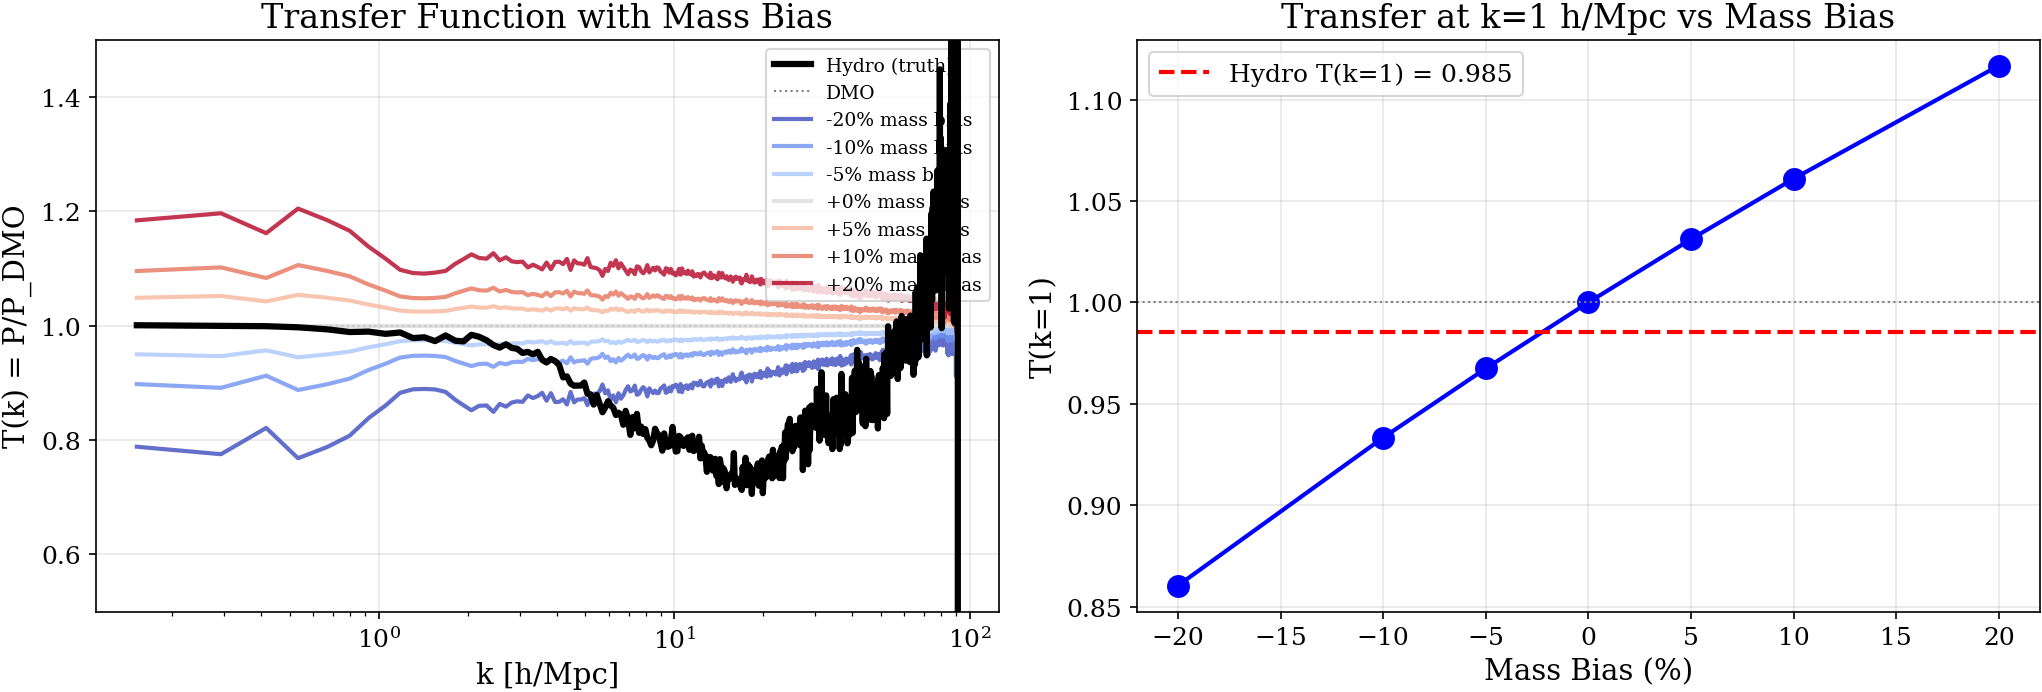


-10% mass bias → ΔT = -0.0667 (-6.67% change in T)

+10% mass bias → ΔT = +0.0610 (+6.10% change in T)


In [11]:
# Plot transfer functions with different mass biases
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.coolwarm(np.linspace(0, 1, len(mass_biases)))

# Left: Transfer functions
ax = axes[0]
ax.semilogx(gt_k, gt_transfer, 'k-', lw=3, label='Hydro (truth)', zorder=10)
ax.semilogx(gt_k, np.ones_like(gt_k), 'k:', lw=1, alpha=0.5, label='DMO')

for i, bias in enumerate(mass_biases):
    ax.semilogx(gt_k, transfer_results[bias]['transfer'], color=colors[i], lw=2, 
                label=f'{bias:+.0%} mass bias', alpha=0.8)

ax.set_xlabel('k [h/Mpc]')
ax.set_ylabel('T(k) = P/P_DMO')
ax.set_title('Transfer Function with Mass Bias')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0.5, 1.5)
ax.grid(True, alpha=0.3)

# Right: T(k=1) vs mass bias
ax = axes[1]
biases = list(transfer_results.keys())
T_values = [transfer_results[b]['T_k1'] for b in biases]

ax.plot(np.array(biases)*100, T_values, 'bo-', lw=2, markersize=10)
ax.axhline(gt_transfer[idx_k1], color='r', ls='--', lw=2, label=f'Hydro T(k=1) = {gt_transfer[idx_k1]:.3f}')
ax.axhline(1.0, color='gray', ls=':', lw=1)

ax.set_xlabel('Mass Bias (%)')
ax.set_ylabel('T(k=1)')
ax.set_title('Transfer at k=1 h/Mpc vs Mass Bias')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate sensitivity
T_baseline = transfer_results[0.0]['T_k1']
for bias in [-0.10, 0.10]:
    delta_T = transfer_results[bias]['T_k1'] - T_baseline
    print(f"\n{bias:+.0%} mass bias → ΔT = {delta_T:+.4f} ({delta_T/T_baseline*100:+.2f}% change in T)")

## 5. Test 3: Random Mass Scatter (No Systematic Bias)

What if there's no systematic bias, but random scatter in the halo masses? 
This mimics the case where the model is accurate on average but noisy.

In [12]:
# Test 3: Random scatter (no systematic bias)
np.random.seed(42)
scatter_values = [0.0, 0.05, 0.10, 0.20, 0.30, 0.50]  # Standard deviation as fraction of mass
scatter_results = {}

for scatter in scatter_values:
    # Apply random scatter to each halo independently
    random_factors = 1.0 + scatter * np.random.randn(len(dmo_cutouts))
    random_factors = np.clip(random_factors, 0.1, 3.0)  # Prevent negative/extreme values
    
    scattered_cutouts = [cutout * factor for cutout, factor in zip(dmo_cutouts, random_factors)]
    
    # Simple paste
    scattered_field = simple_paste_2d(dmo_field, scattered_cutouts, halo_centers_pix, patch_size=dmo_cutouts[0].shape[0])
    
    # Compute power spectrum
    scattered_pk, scattered_k = compute_power_spectrum_simple(scattered_field, BoxSize=BOX_MPC)
    scattered_pk_interp = np.interp(gt_k, scattered_k, scattered_pk)
    scattered_transfer = scattered_pk_interp / dmo_pk_interp
    
    scatter_results[scatter] = {
        'transfer': scattered_transfer,
        'T_k1': scattered_transfer[idx_k1],
        'mean_factor': np.mean(random_factors),
        'std_factor': np.std(random_factors)
    }
    
    print(f"Scatter = {scatter:.0%}: T(k=1) = {scattered_transfer[idx_k1]:.4f}, "
          f"Mean factor = {np.mean(random_factors):.3f} ± {np.std(random_factors):.3f}")


Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds
Scatter = 0%: T(k=1) = 1.0000, Mean factor = 1.000 ± 0.000

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds
Scatter = 5%: T(k=1) = 0.9855, Mean factor = 1.001 ± 0.046

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds
Scatter = 10%: T(k=1) = 1.0070, Mean factor = 0.994 ± 0.095

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds
Scatter = 20%: T(k=1) = 1.1224, Mean factor = 1.035 ± 0.191

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds
Scatter = 30%: T(k=1) = 1.1090, Mean factor = 1.022 ± 0.312

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds
Scatter = 50%: T(k=1) = 1.5279, Mean factor = 0.971 ± 0.505


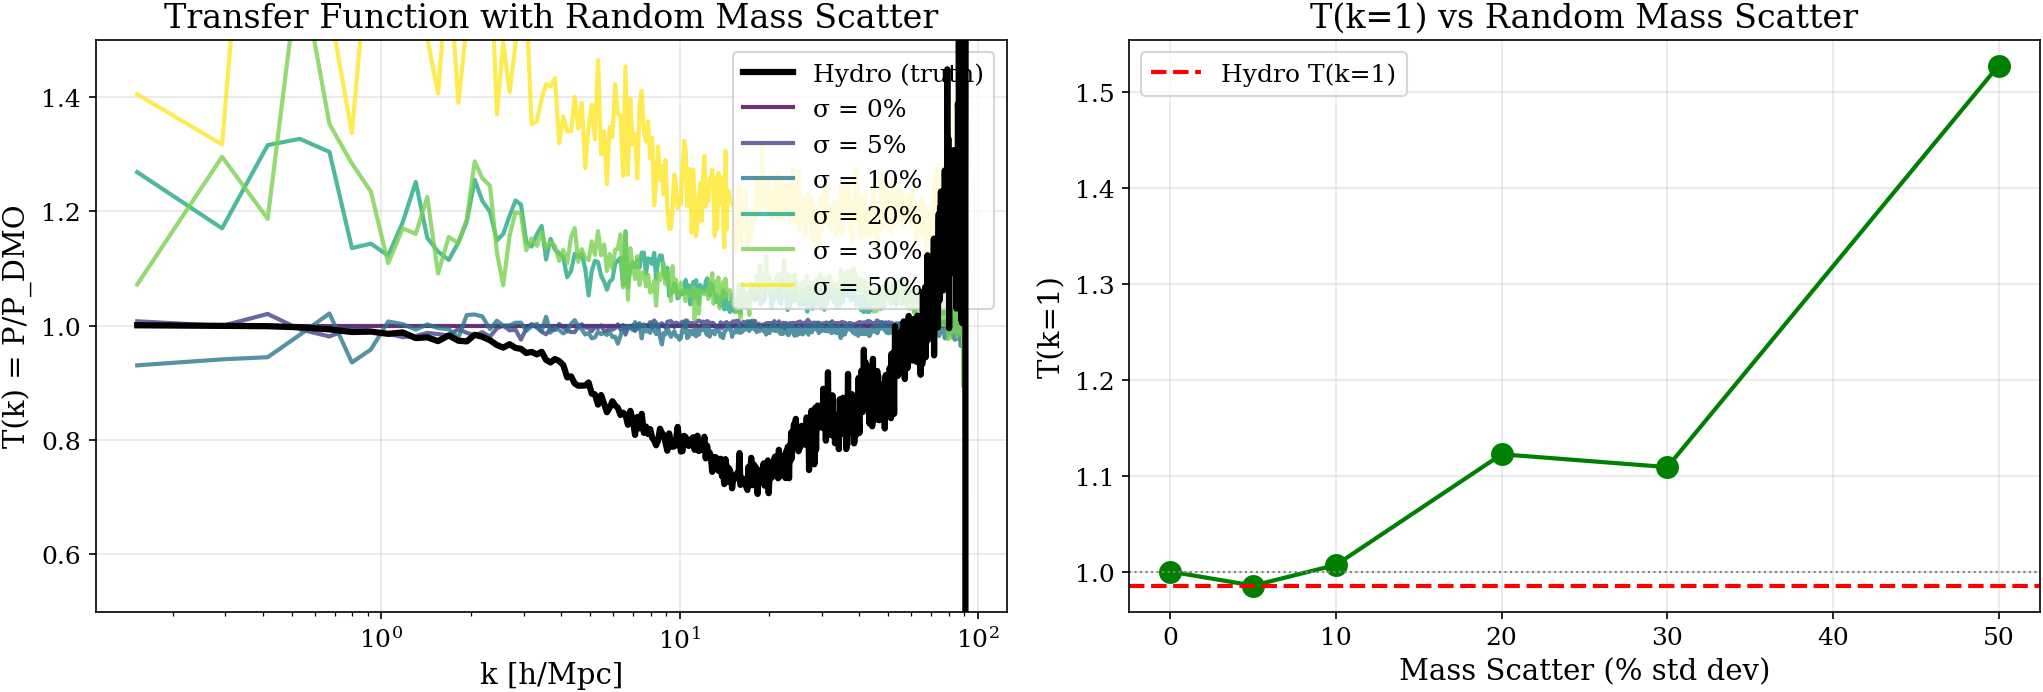

In [13]:
# Plot scatter results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(scatter_values)))

ax = axes[0]
ax.semilogx(gt_k, gt_transfer, 'k-', lw=3, label='Hydro (truth)', zorder=10)

for i, scatter in enumerate(scatter_values):
    ax.semilogx(gt_k, scatter_results[scatter]['transfer'], color=colors[i], lw=2, 
                label=f'σ = {scatter:.0%}', alpha=0.8)

ax.set_xlabel('k [h/Mpc]')
ax.set_ylabel('T(k) = P/P_DMO')
ax.set_title('Transfer Function with Random Mass Scatter')
ax.legend(loc='upper right')
ax.set_ylim(0.5, 1.5)
ax.grid(True, alpha=0.3)

ax = axes[1]
scatter_list = list(scatter_results.keys())
T_scatter = [scatter_results[s]['T_k1'] for s in scatter_list]
ax.plot(np.array(scatter_list)*100, T_scatter, 'go-', lw=2, markersize=10)
ax.axhline(gt_transfer[idx_k1], color='r', ls='--', lw=2, label=f'Hydro T(k=1)')
ax.axhline(1.0, color='gray', ls=':', lw=1)

ax.set_xlabel('Mass Scatter (% std dev)')
ax.set_ylabel('T(k=1)')
ax.set_title('T(k=1) vs Random Mass Scatter')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Test 4: Halo Coverage and Edge Effects

How much of the box is covered by halos? What happens to pixels that are NOT in any halo region?
The current BIND algorithm uses DMO for non-halo regions. Is this causing the suppression?

In [14]:
# Calculate coverage map - which pixels are covered by at least one halo patch
patch_size = dmo_cutouts[0].shape[0]
half_patch = patch_size // 2

coverage_map = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)
for center in halo_centers_pix:
    for i in range(patch_size):
        for j in range(patch_size):
            ix = (center[0] - half_patch + i) % GRID_SIZE
            jx = (center[1] - half_patch + j) % GRID_SIZE
            coverage_map[ix, jx] += 1

coverage_fraction = (coverage_map > 0).sum() / (GRID_SIZE * GRID_SIZE)
overlap_fraction = (coverage_map > 1).sum() / (GRID_SIZE * GRID_SIZE)

print(f"Patch size: {patch_size} x {patch_size} pixels = {CUTOUT_SIZE_MPC} Mpc/h")
print(f"Number of halos: {len(halo_masses)}")
print(f"Fraction of box covered: {coverage_fraction*100:.1f}%")
print(f"Fraction with overlap (>1 halo): {overlap_fraction*100:.1f}%")
print(f"Max overlap: {coverage_map.max()} halos in one pixel")

Patch size: 128 x 128 pixels = 6.25 Mpc/h
Number of halos: 45
Fraction of box covered: 43.2%
Fraction with overlap (>1 halo): 14.7%
Max overlap: 7 halos in one pixel


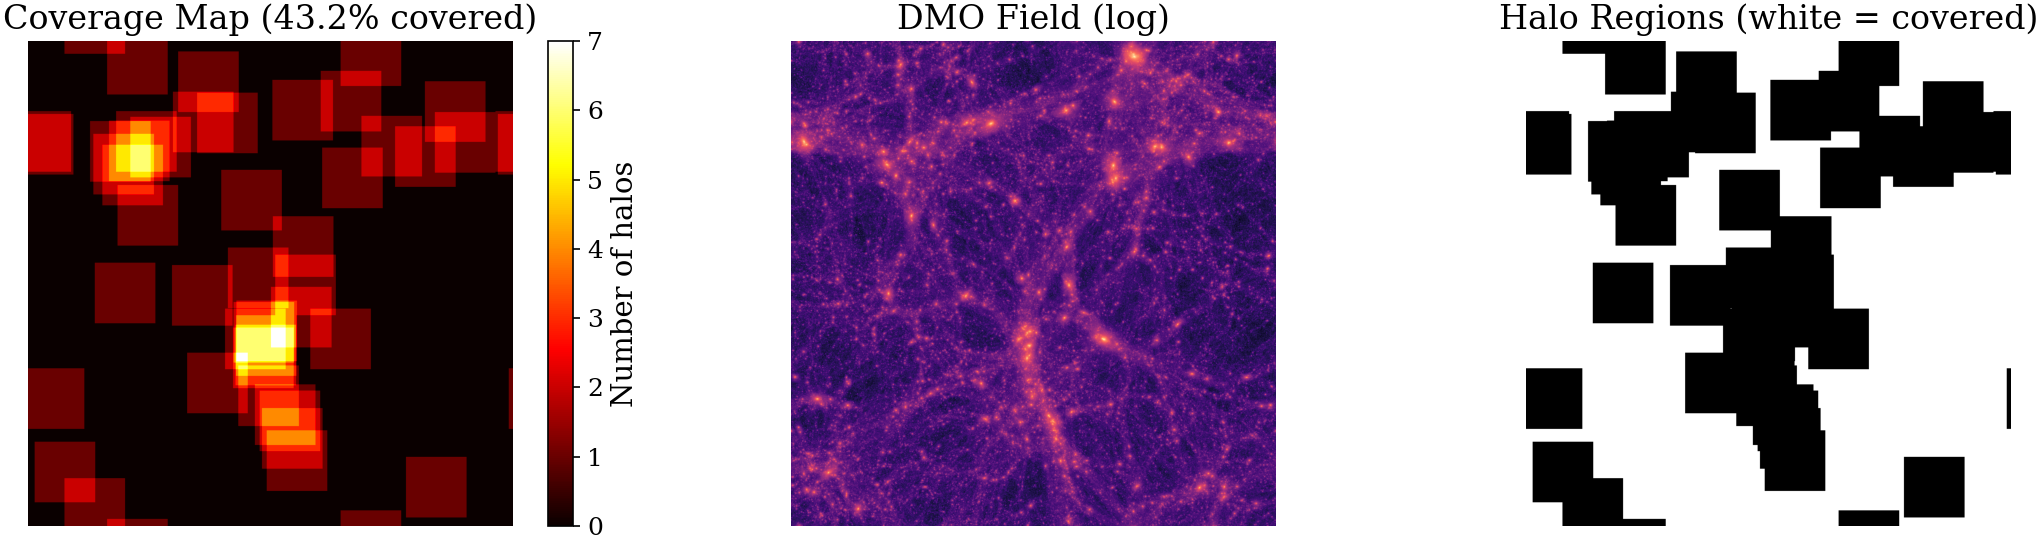

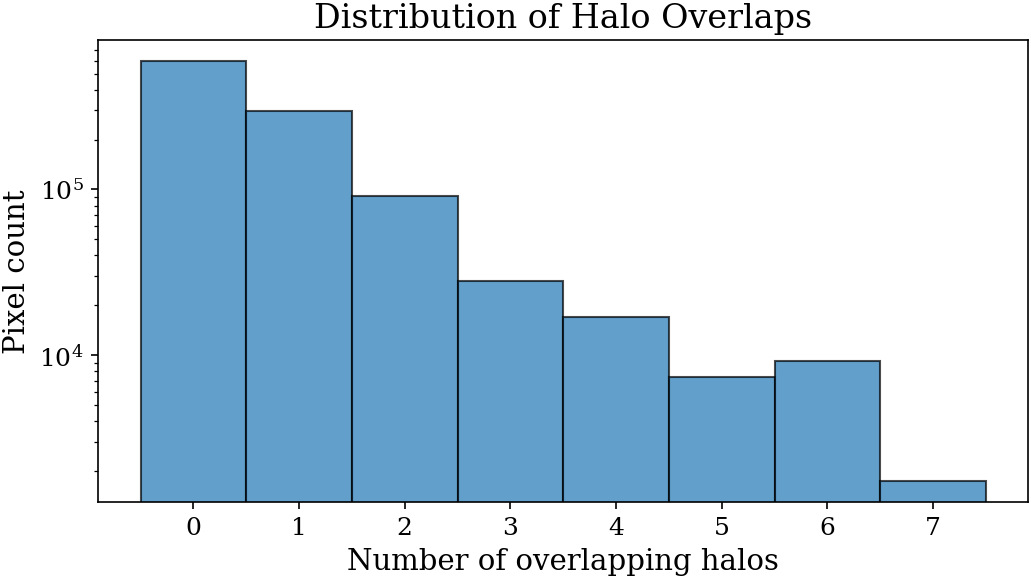

In [15]:
# Visualize coverage
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
im = ax.imshow(coverage_map, cmap='hot')
plt.colorbar(im, ax=ax, label='Number of halos')
ax.set_title(f'Coverage Map ({coverage_fraction*100:.1f}% covered)')
ax.axis('off')

ax = axes[1]
ax.imshow(np.log10(dmo_field + 1), cmap='magma')
ax.set_title('DMO Field (log)')
ax.axis('off')

ax = axes[2]
# Show which regions are halo vs non-halo
ax.imshow(coverage_map > 0, cmap='binary')
ax.set_title('Halo Regions (white = covered)')
ax.axis('off')

plt.tight_layout()
plt.show()

# Histogram of coverage
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(coverage_map.flatten(), bins=np.arange(0, coverage_map.max()+2)-0.5, 
        edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of overlapping halos')
ax.set_ylabel('Pixel count')
ax.set_title('Distribution of Halo Overlaps')
ax.set_yscale('log')
plt.show()

## 7. Test 5: Perfect Hydro Pasting

**Critical test**: What if we paste the ACTUAL hydro cutouts (ground truth) instead of generated ones?
This isolates whether the issue is in halo generation vs the pasting algorithm itself.

In [16]:
# Extract hydro cutouts at halo locations
hydro_cutouts = []
for pos in halo_positions:
    center_2d = pos[:2]
    cutout = extract_cutout_2d(gt_total, center_2d, CUTOUT_SIZE_MPC, BOX_MPC, GRID_SIZE)
    hydro_cutouts.append(cutout)

hydro_cutouts = np.array(hydro_cutouts)
print(f"Extracted {len(hydro_cutouts)} hydro cutouts")

# Compare mass in DMO vs Hydro cutouts
dmo_cutout_masses = np.array([c.sum() for c in dmo_cutouts])
hydro_cutout_masses = np.array([c.sum() for c in hydro_cutouts])

print(f"\nMass comparison in cutouts:")
print(f"DMO cutouts: {dmo_cutout_masses.mean():.3e} ± {dmo_cutout_masses.std():.3e}")
print(f"Hydro cutouts: {hydro_cutout_masses.mean():.3e} ± {hydro_cutout_masses.std():.3e}")
print(f"Ratio (Hydro/DMO): {(hydro_cutout_masses / dmo_cutout_masses).mean():.4f} ± {(hydro_cutout_masses / dmo_cutout_masses).std():.4f}")

Extracted 45 hydro cutouts

Mass comparison in cutouts:
DMO cutouts: 3.017e+14 ± 1.270e+14
Hydro cutouts: 3.016e+14 ± 1.268e+14
Ratio (Hydro/DMO): 1.0001 ± 0.0035


In [17]:
# Test 5a: Simple paste with perfect hydro cutouts
perfect_hydro_simple = simple_paste_2d(dmo_field, hydro_cutouts, halo_centers_pix, patch_size=hydro_cutouts[0].shape[0])

# Compute power spectrum
perfect_pk, perfect_k = compute_power_spectrum_simple(perfect_hydro_simple, BoxSize=BOX_MPC)
perfect_pk_interp = np.interp(gt_k, perfect_k, perfect_pk)
perfect_transfer = perfect_pk_interp / dmo_pk_interp

print("=== Perfect Hydro Pasting (Simple) ===")
print(f"Ground truth T(k=1): {gt_transfer[idx_k1]:.4f}")
print(f"Perfect paste T(k=1): {perfect_transfer[idx_k1]:.4f}")
print(f"Deviation from GT: {(perfect_transfer[idx_k1] - gt_transfer[idx_k1])/gt_transfer[idx_k1]*100:.2f}%")


Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds
=== Perfect Hydro Pasting (Simple) ===
Ground truth T(k=1): 0.9855
Perfect paste T(k=1): 0.9869
Deviation from GT: 0.15%


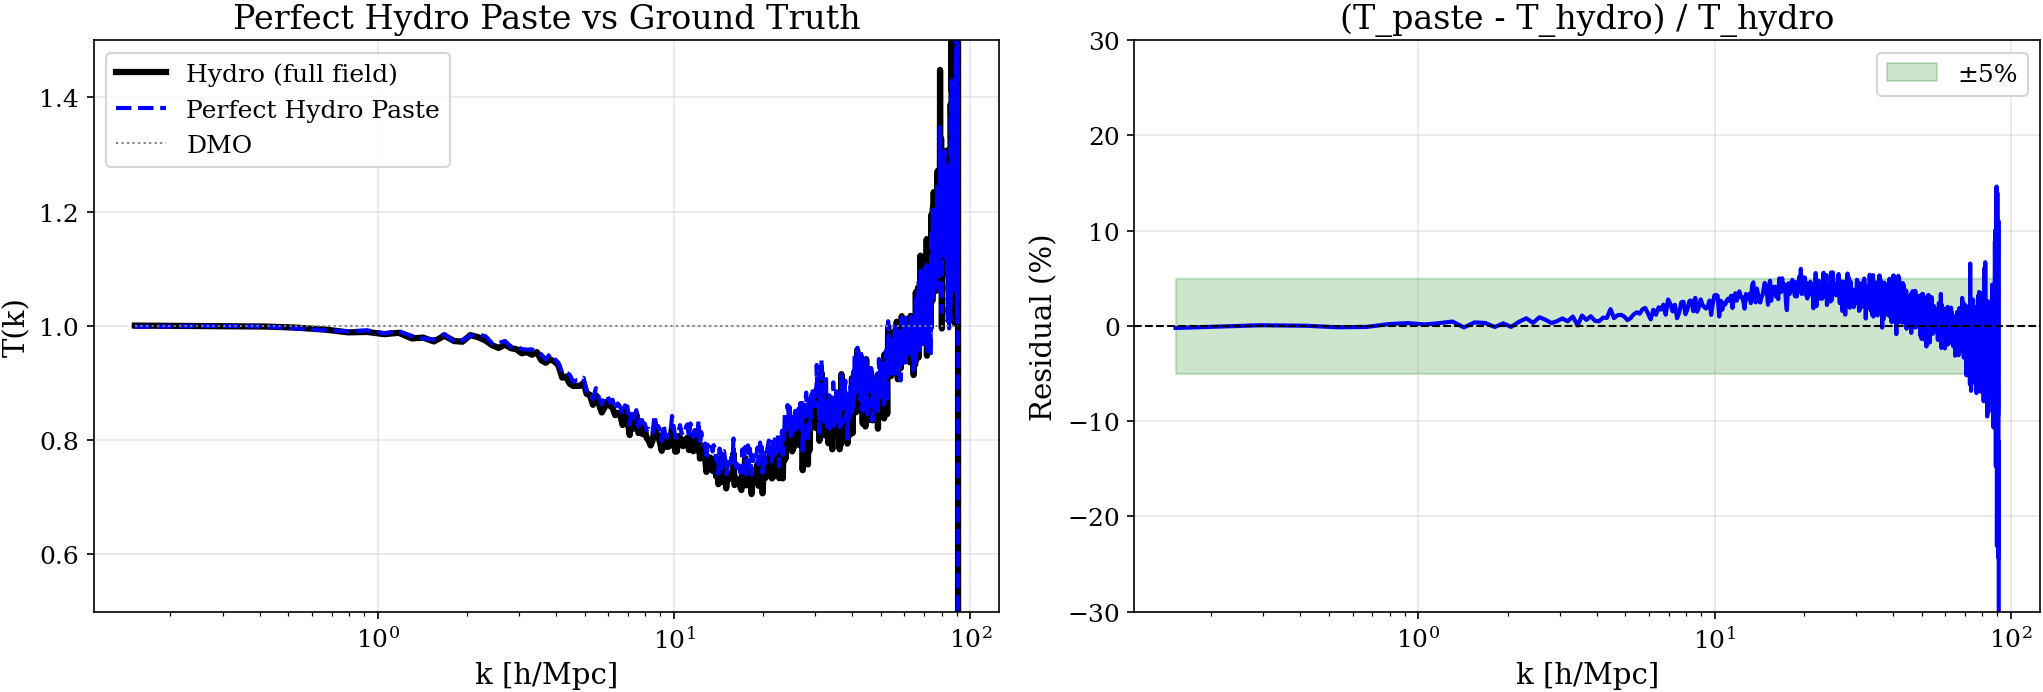

In [18]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogx(gt_k, gt_transfer, 'k-', lw=3, label='Hydro (full field)')
ax.semilogx(gt_k, perfect_transfer, 'b--', lw=2, label='Perfect Hydro Paste')
ax.semilogx(gt_k, np.ones_like(gt_k), 'gray', ls=':', lw=1, label='DMO')

ax.set_xlabel('k [h/Mpc]')
ax.set_ylabel('T(k)')
ax.set_title('Perfect Hydro Paste vs Ground Truth')
ax.legend()
ax.set_ylim(0.5, 1.5)
ax.grid(True, alpha=0.3)

ax = axes[1]
residual = (perfect_transfer - gt_transfer) / gt_transfer * 100
ax.semilogx(gt_k, residual, 'b-', lw=2)
ax.axhline(0, color='k', ls='--', lw=1)
ax.fill_between(gt_k, -5, 5, color='green', alpha=0.2, label='±5%')

ax.set_xlabel('k [h/Mpc]')
ax.set_ylabel('Residual (%)')
ax.set_title('(T_paste - T_hydro) / T_hydro')
ax.set_ylim(-30, 30)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## 8. Test 6: Diagnose What's Happening in Non-Halo Regions

The BIND algorithm pastes halos but keeps DMO for non-halo regions. But the transfer function depends on the FULL box.
Let's compute what the "ideal" hybrid field should look like.

In [19]:
# Create a mask for halo regions
halo_mask = coverage_map > 0

# Compute statistics for halo vs non-halo regions
print("=== Halo vs Non-Halo Region Statistics ===")
print(f"\nDMO Field:")
print(f"  Halo regions: mean = {dmo_field[halo_mask].mean():.3e}, total = {dmo_field[halo_mask].sum():.3e}")
print(f"  Non-halo regions: mean = {dmo_field[~halo_mask].mean():.3e}, total = {dmo_field[~halo_mask].sum():.3e}")

print(f"\nHydro Field:")
print(f"  Halo regions: mean = {gt_total[halo_mask].mean():.3e}, total = {gt_total[halo_mask].sum():.3e}")
print(f"  Non-halo regions: mean = {gt_total[~halo_mask].mean():.3e}, total = {gt_total[~halo_mask].sum():.3e}")

# What fraction of the mass is in halos vs field?
dmo_halo_frac = dmo_field[halo_mask].sum() / dmo_field.sum()
hydro_halo_frac = gt_total[halo_mask].sum() / gt_total.sum()
print(f"\nMass fraction in halo regions:")
print(f"  DMO: {dmo_halo_frac*100:.1f}%")
print(f"  Hydro: {hydro_halo_frac*100:.1f}%")

=== Halo vs Non-Halo Region Statistics ===

DMO Field:
  Halo regions: mean = 1.529e+10, total = 6.920e+15
  Non-halo regions: mean = 5.853e+09, total = 3.488e+15

Hydro Field:
  Halo regions: mean = 1.529e+10, total = 6.919e+15
  Non-halo regions: mean = 5.854e+09, total = 3.489e+15

Mass fraction in halo regions:
  DMO: 66.5%
  Hydro: 66.5%


In [20]:
# Create ideal hybrid field: Hydro in halo regions, DMO elsewhere
ideal_hybrid = np.where(halo_mask, gt_total, dmo_field)

# Compute power spectrum
ideal_pk, ideal_k = compute_power_spectrum_simple(ideal_hybrid, BoxSize=BOX_MPC)
ideal_pk_interp = np.interp(gt_k, ideal_k, ideal_pk)
ideal_transfer = ideal_pk_interp / dmo_pk_interp

print("=== Ideal Hybrid (Hydro in halos, DMO elsewhere) ===")
print(f"Ground truth T(k=1): {gt_transfer[idx_k1]:.4f}")
print(f"Ideal hybrid T(k=1): {ideal_transfer[idx_k1]:.4f}")

# Compare: what if we just used hydro in halo regions, but ALSO hydro field in non-halo regions (just use full hydro)?
# This is just gt_total, so we already have it

# What if we use DMO everywhere except scale the non-halo regions?
print("\n=== Analysis of the mismatch ===")
print(f"Non-halo regions are {(1-coverage_fraction)*100:.1f}% of the box")
print(f"Non-halo regions contain {(1-dmo_halo_frac)*100:.1f}% of DMO mass")
print(f"Using DMO in non-halo regions instead of Hydro causes a bias because DMO ≠ Hydro there")


Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds
=== Ideal Hybrid (Hydro in halos, DMO elsewhere) ===
Ground truth T(k=1): 0.9855
Ideal hybrid T(k=1): 0.9869

=== Analysis of the mismatch ===
Non-halo regions are 56.8% of the box
Non-halo regions contain 33.5% of DMO mass
Using DMO in non-halo regions instead of Hydro causes a bias because DMO ≠ Hydro there


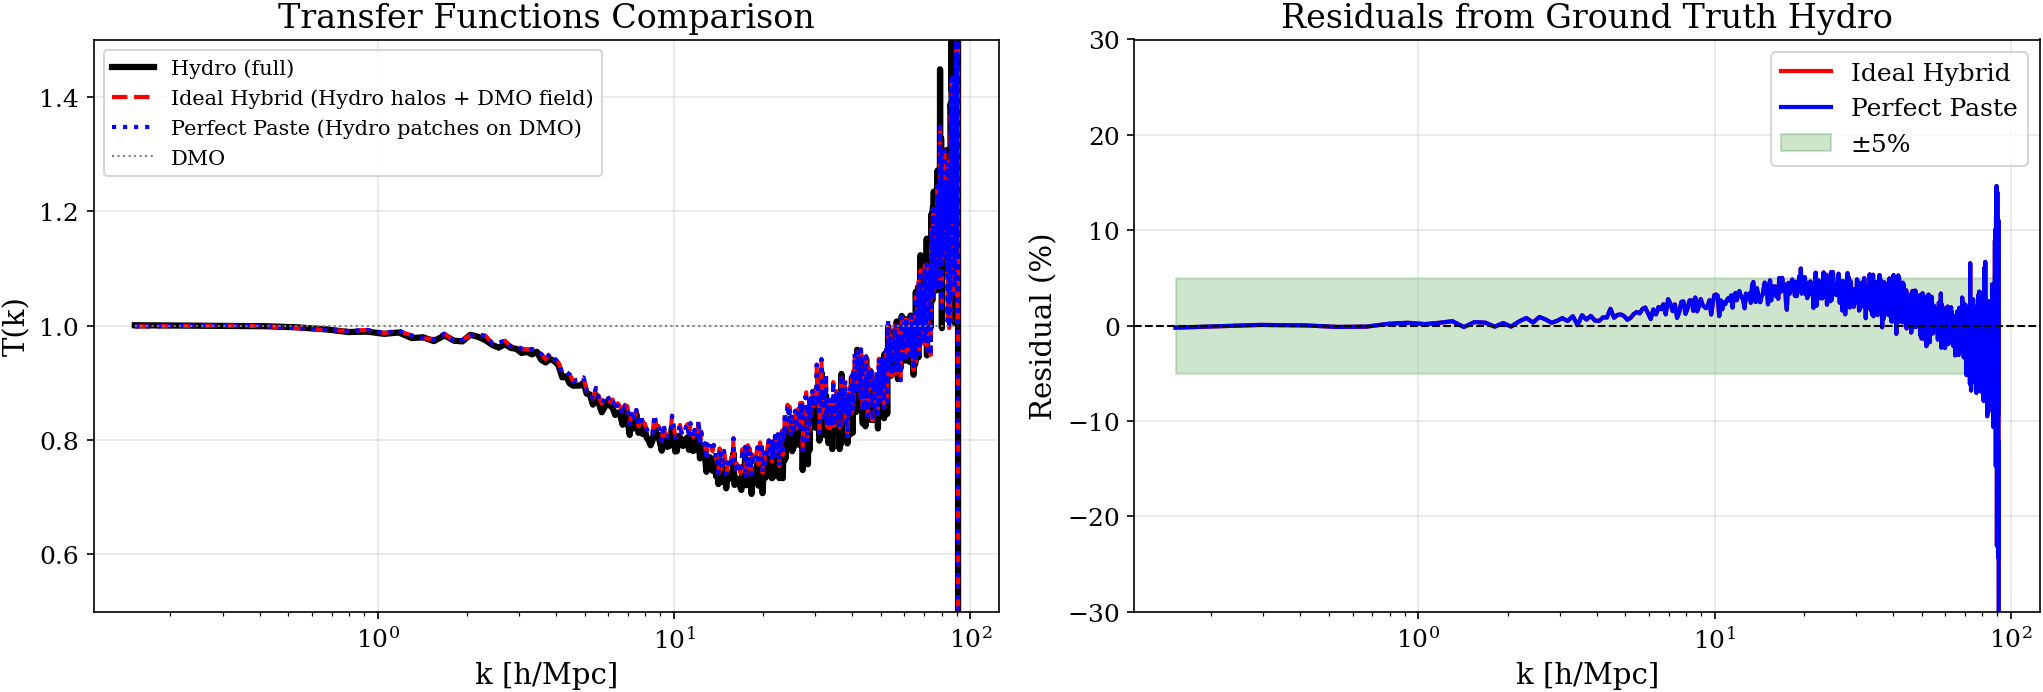

In [21]:
# Plot all transfer functions together
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogx(gt_k, gt_transfer, 'k-', lw=3, label='Hydro (full)')
ax.semilogx(gt_k, ideal_transfer, 'r--', lw=2, label='Ideal Hybrid (Hydro halos + DMO field)')
ax.semilogx(gt_k, perfect_transfer, 'b:', lw=2, label='Perfect Paste (Hydro patches on DMO)')
ax.semilogx(gt_k, np.ones_like(gt_k), 'gray', ls=':', lw=1, label='DMO')

ax.set_xlabel('k [h/Mpc]')
ax.set_ylabel('T(k)')
ax.set_title('Transfer Functions Comparison')
ax.legend(fontsize=10)
ax.set_ylim(0.5, 1.5)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogx(gt_k, (ideal_transfer - gt_transfer)/gt_transfer * 100, 'r-', lw=2, label='Ideal Hybrid')
ax.semilogx(gt_k, (perfect_transfer - gt_transfer)/gt_transfer * 100, 'b-', lw=2, label='Perfect Paste')
ax.axhline(0, color='k', ls='--', lw=1)
ax.fill_between(gt_k, -5, 5, color='green', alpha=0.2, label='±5%')

ax.set_xlabel('k [h/Mpc]')
ax.set_ylabel('Residual (%)')
ax.set_title('Residuals from Ground Truth Hydro')
ax.legend()
ax.set_ylim(-30, 30)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Test 7: Run Actual Interpolant Model and Compare

Let's actually run the interpolant model and diagnose where the predictions go wrong.

In [75]:
# Run interpolant model
import pandas as pd
from bind.model_manager import ModelManager
from bind.sampling import sample

config_path = '/mnt/home/mlee1/vdm_BIND/configs/clean_vdm_regularized.ini'

with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
    config = ConfigLoader(config_path, verbose=False)
    
print(f"Checkpoint: {config.best_ckpt}")

Checkpoint: /mnt/home/mlee1/ceph/tb_logs3/clean_vdm_regularized/version_0//checkpoints/epoch-epoch=189-step=121410.ckpt


In [76]:
# Initialize BIND with interpolant model
with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
    bind = BIND(
        simulation_path=str(DMO_PATH),
        snapnum=SNAPNUM,
        boxsize=BOX_SIZE,
        gridsize=GRID_SIZE,
        config_path=config_path,
        dim='2d',
        axis=2,
        verbose=False,
        r_in_factor=2.0,
        r_out_factor=3.0,
        mass_threshold=10**13,
    )

# Voxelize and extract
bind.voxelize_simulation()
bind.extract_halos(0.3, use_large_scale=True, num_large_scales=3)

# Get conditional params (fiducial cosmology)
metadata = pd.read_csv('/mnt/home/mlee1/Sims/IllustrisTNG_extras/L50n512/SB35/SB35_param_minmax.csv')
base_params = list(metadata['FiducialVal'])
num_halos = len(bind.extracted['metadata'])
conditional_params = np.reshape(base_params * num_halos, (num_halos, -1))

print(f"Extracted {num_halos} halos")

Extracted 45 halos


In [77]:
# Generate halos (with mass conservation)
bind.generate_halos(batch_size=10, conditional_params=conditional_params, conserve_mass=True)

# Get generated halos
generated_halos = bind.generated_images

print(f"Generated {len(generated_halos)} halos")
print(f"Shape of each: {generated_halos[0].shape}")  # (n_realizations, n_channels, H, W)

Seed set to 8


✓ Scale-appropriate Fourier features enabled:
  - Halo (m_dm): High frequencies [1, 2, 4, 8]π -> 8 features per channel
  - Large-scale: Low frequencies [0.25, 0.5, 1, 2]π -> 8 features per channel
  - Target: No Fourier features (learns naturally)
  - Total input channels: 39
⚙️  ParamEmbedding: Conditional mode (n_params=35)
✓ Parameter conditioning enabled:
  - Time embedding dim: 384
  - Param embedding dim: 384
  - Total condition dim: 768
✓ Channel progression (encoder): [96, 192, 384, 768, 1024]
✓ Final decoder channels: 64 (GroupNorm groups: 8)
✓ Parameter predictor added (predicts 35 params)

INITIALIZING CLEAN VDM MODEL

📊 MODEL CONFIGURATION:
  Image shape: (3, 128, 128)
  Noise schedule: learned_nn
  Gamma range: [-13.3, 13.0]
  Data noise (per-channel): (0.001, 0.001, 0.001)
  Loss weights (diffusion, latent, recons): 1.0, 1.0, 1.0

🎯 CHANNEL WEIGHTS: (1, 1, 1)

✓ Parameter prediction enabled (weight=0.01)


✓ Final decoder channels: 64 (GroupNorm groups: 8)
✓ Parameter pr

Generating Samples (250 steps):   0%|          | 0/45 [00:00<?, ?it/s]/mnt/home/mlee1/vdm_BIND/bind/sampling.py:57: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  param_row = torch.tensor(conditional_params[i], dtype=torch.float32, device='cuda')
/mnt/home/mlee1/vdm_BIND/bind/sampling.py:57: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  param_row = torch.tensor(conditional_params[i], dtype=torch.float32, device='cuda')
Generating Samples (250 steps): 100%|██████████| 45/45 [05:24<00:00,  7.22s/it]



torch.Size([45, 10, 3, 128, 128])
Generated 45 halos
Shape of each: (10, 3, 128, 128)
Generated 45 halos
Shape of each: (10, 3, 128, 128)


In [78]:
# Compare generated vs ground truth cutouts
# Extract hydro cutouts at same locations
generated_total_masses = []
hydro_total_masses = []
dmo_total_masses = []

for i, meta in enumerate(bind.extracted['metadata']):
    pos_mpc = meta['position'] / 1000.0
    center_2d = pos_mpc[:2]
    
    # Get generated total (sum of channels, first realization)
    gen_halo = generated_halos[i][0]  # First realization
    gen_total = gen_halo.sum()  # Sum over channels
    generated_total_masses.append(gen_total)
    
    # Get hydro cutout
    hydro_cutout = extract_cutout_2d(gt_total, center_2d, CUTOUT_SIZE_MPC, BOX_MPC, GRID_SIZE)
    hydro_total_masses.append(hydro_cutout.sum())
    
    # Get DMO cutout
    dmo_cutout = extract_cutout_2d(dmo_field, center_2d, CUTOUT_SIZE_MPC, BOX_MPC, GRID_SIZE)
    dmo_total_masses.append(dmo_cutout.sum())

generated_total_masses = np.array(generated_total_masses)
hydro_total_masses = np.array(hydro_total_masses)
dmo_total_masses = np.array(dmo_total_masses)

# Compute ratios
gen_to_dmo = generated_total_masses / dmo_total_masses
gen_to_hydro = generated_total_masses / hydro_total_masses
hydro_to_dmo = hydro_total_masses / dmo_total_masses

print("=== Mass Comparison (Generated vs Hydro vs DMO) ===")
print(f"Generated/DMO: {gen_to_dmo.mean():.4f} ± {gen_to_dmo.std():.4f}")
print(f"Generated/Hydro: {gen_to_hydro.mean():.4f} ± {gen_to_hydro.std():.4f}")
print(f"Hydro/DMO: {hydro_to_dmo.mean():.4f} ± {hydro_to_dmo.std():.4f}")

=== Mass Comparison (Generated vs Hydro vs DMO) ===
Generated/DMO: 1.0000 ± 0.0000
Generated/Hydro: 0.9999 ± 0.0035
Hydro/DMO: 1.0001 ± 0.0035


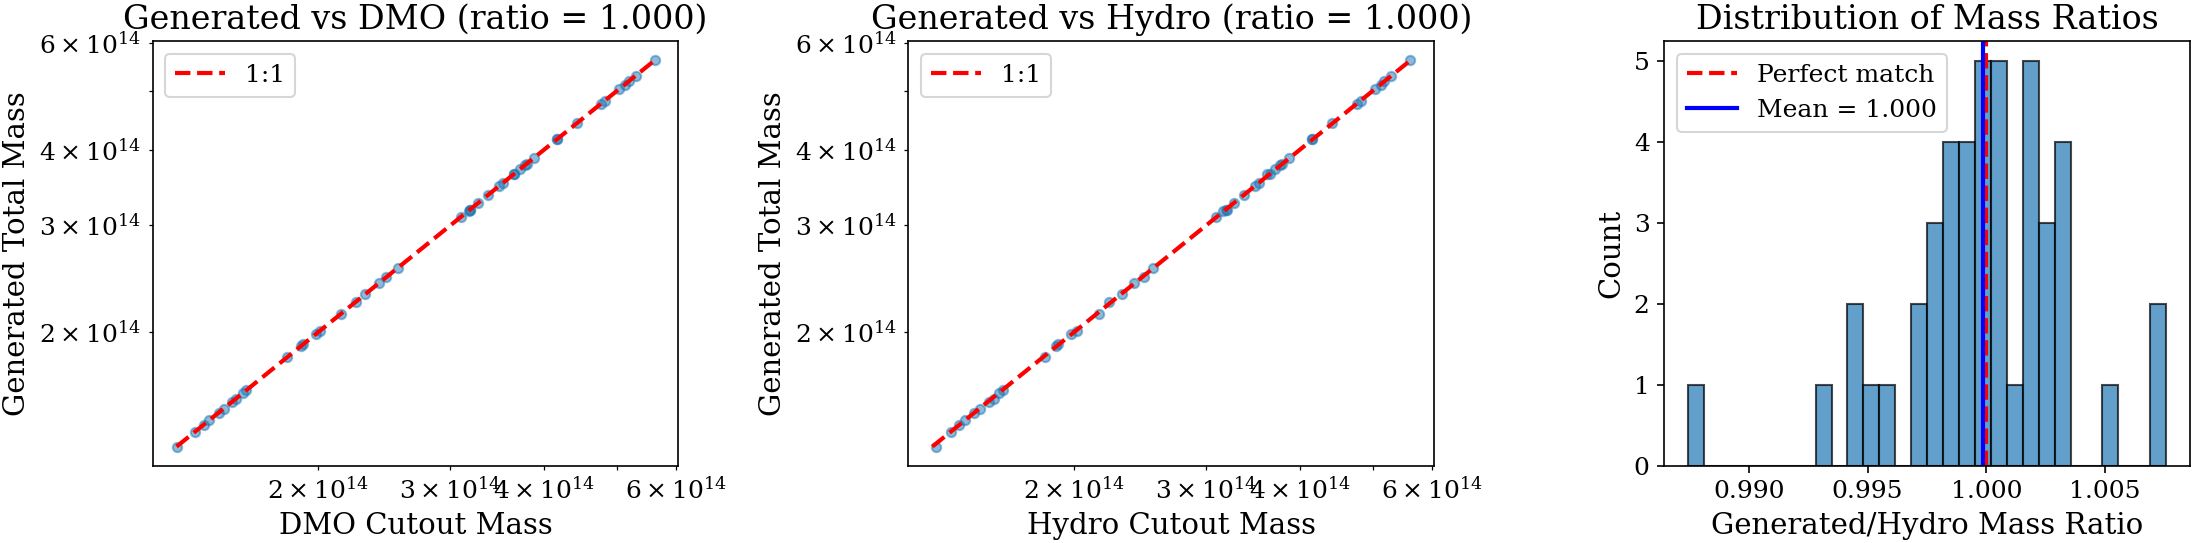

In [79]:
# Plot mass comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.scatter(dmo_total_masses, generated_total_masses, alpha=0.5, s=20)
lims = [min(dmo_total_masses.min(), generated_total_masses.min()), 
        max(dmo_total_masses.max(), generated_total_masses.max())]
ax.plot(lims, lims, 'r--', lw=2, label='1:1')
ax.set_xlabel('DMO Cutout Mass')
ax.set_ylabel('Generated Total Mass')
ax.set_title(f'Generated vs DMO (ratio = {gen_to_dmo.mean():.3f})')
ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')

ax = axes[1]
ax.scatter(hydro_total_masses, generated_total_masses, alpha=0.5, s=20)
lims = [min(hydro_total_masses.min(), generated_total_masses.min()), 
        max(hydro_total_masses.max(), generated_total_masses.max())]
ax.plot(lims, lims, 'r--', lw=2, label='1:1')
ax.set_xlabel('Hydro Cutout Mass')
ax.set_ylabel('Generated Total Mass')
ax.set_title(f'Generated vs Hydro (ratio = {gen_to_hydro.mean():.3f})')
ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')

ax = axes[2]
ax.hist(gen_to_hydro, bins=30, alpha=0.7, edgecolor='black')
ax.axvline(1.0, color='r', ls='--', lw=2, label='Perfect match')
ax.axvline(gen_to_hydro.mean(), color='b', ls='-', lw=2, label=f'Mean = {gen_to_hydro.mean():.3f}')
ax.set_xlabel('Generated/Hydro Mass Ratio')
ax.set_ylabel('Count')
ax.set_title('Distribution of Mass Ratios')
ax.legend()

plt.tight_layout()
plt.show()

In [80]:
# Do the actual paste and compute transfer function
final_maps = bind.paste_halos(realizations=10, use_enhanced=True)

# Compute transfer functions for each realization
model_transfers = []
for realization in final_maps:
    pk, k = compute_power_spectrum_simple(realization, BoxSize=BOX_MPC)
    pk_interp = np.interp(gt_k, k, pk)
    T = pk_interp / dmo_pk_interp
    model_transfers.append(T)

model_transfers = np.array(model_transfers)
model_T_mean = model_transfers.mean(axis=0)
model_T_std = model_transfers.std(axis=0)

print(f"Interpolant T(k=1): {model_T_mean[idx_k1]:.4f} ± {model_T_std[idx_k1]:.4f}")
print(f"Ground truth T(k=1): {gt_transfer[idx_k1]:.4f}")


Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.02 seconds

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds
Interpolant T(k=1): 0.9964 ± 0

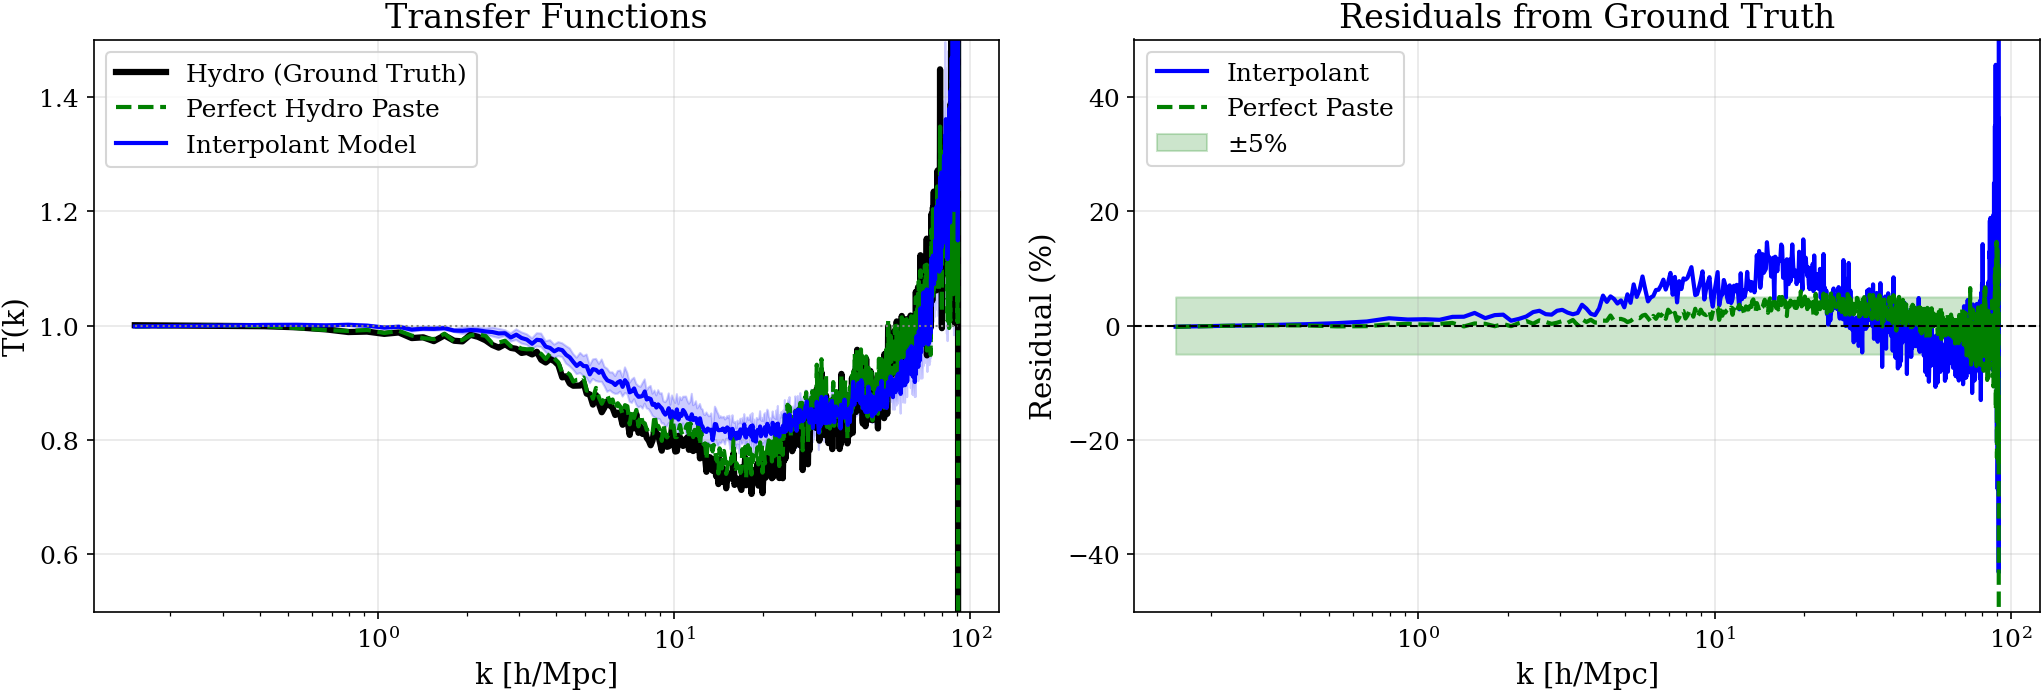

In [81]:
# Final comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogx(gt_k, gt_transfer, 'k-', lw=3, label='Hydro (Ground Truth)')
ax.semilogx(gt_k, perfect_transfer, 'g--', lw=2, label='Perfect Hydro Paste')
ax.semilogx(gt_k, model_T_mean, 'b-', lw=2, label='Interpolant Model')
ax.fill_between(gt_k, model_T_mean - model_T_std, model_T_mean + model_T_std, color='blue', alpha=0.2)
ax.semilogx(gt_k, np.ones_like(gt_k), 'gray', ls=':', lw=1)

ax.set_xlabel('k [h/Mpc]')
ax.set_ylabel('T(k)')
ax.set_title('Transfer Functions')
ax.legend()
ax.set_ylim(0.5, 1.5)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogx(gt_k, (model_T_mean - gt_transfer)/gt_transfer * 100, 'b-', lw=2, label='Interpolant')
ax.semilogx(gt_k, (perfect_transfer - gt_transfer)/gt_transfer * 100, 'g--', lw=2, label='Perfect Paste')
ax.axhline(0, color='k', ls='--', lw=1)
ax.fill_between(gt_k, -5, 5, color='green', alpha=0.2, label='±5%')

ax.set_xlabel('k [h/Mpc]')
ax.set_ylabel('Residual (%)')
ax.set_title('Residuals from Ground Truth')
ax.legend()
ax.set_ylim(-50, 50)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Test 8: Spatial Structure Comparison

Compare the spatial structure of generated vs hydro cutouts at individual halo level.
Maybe the issue is not total mass but the distribution of mass within the cutout.

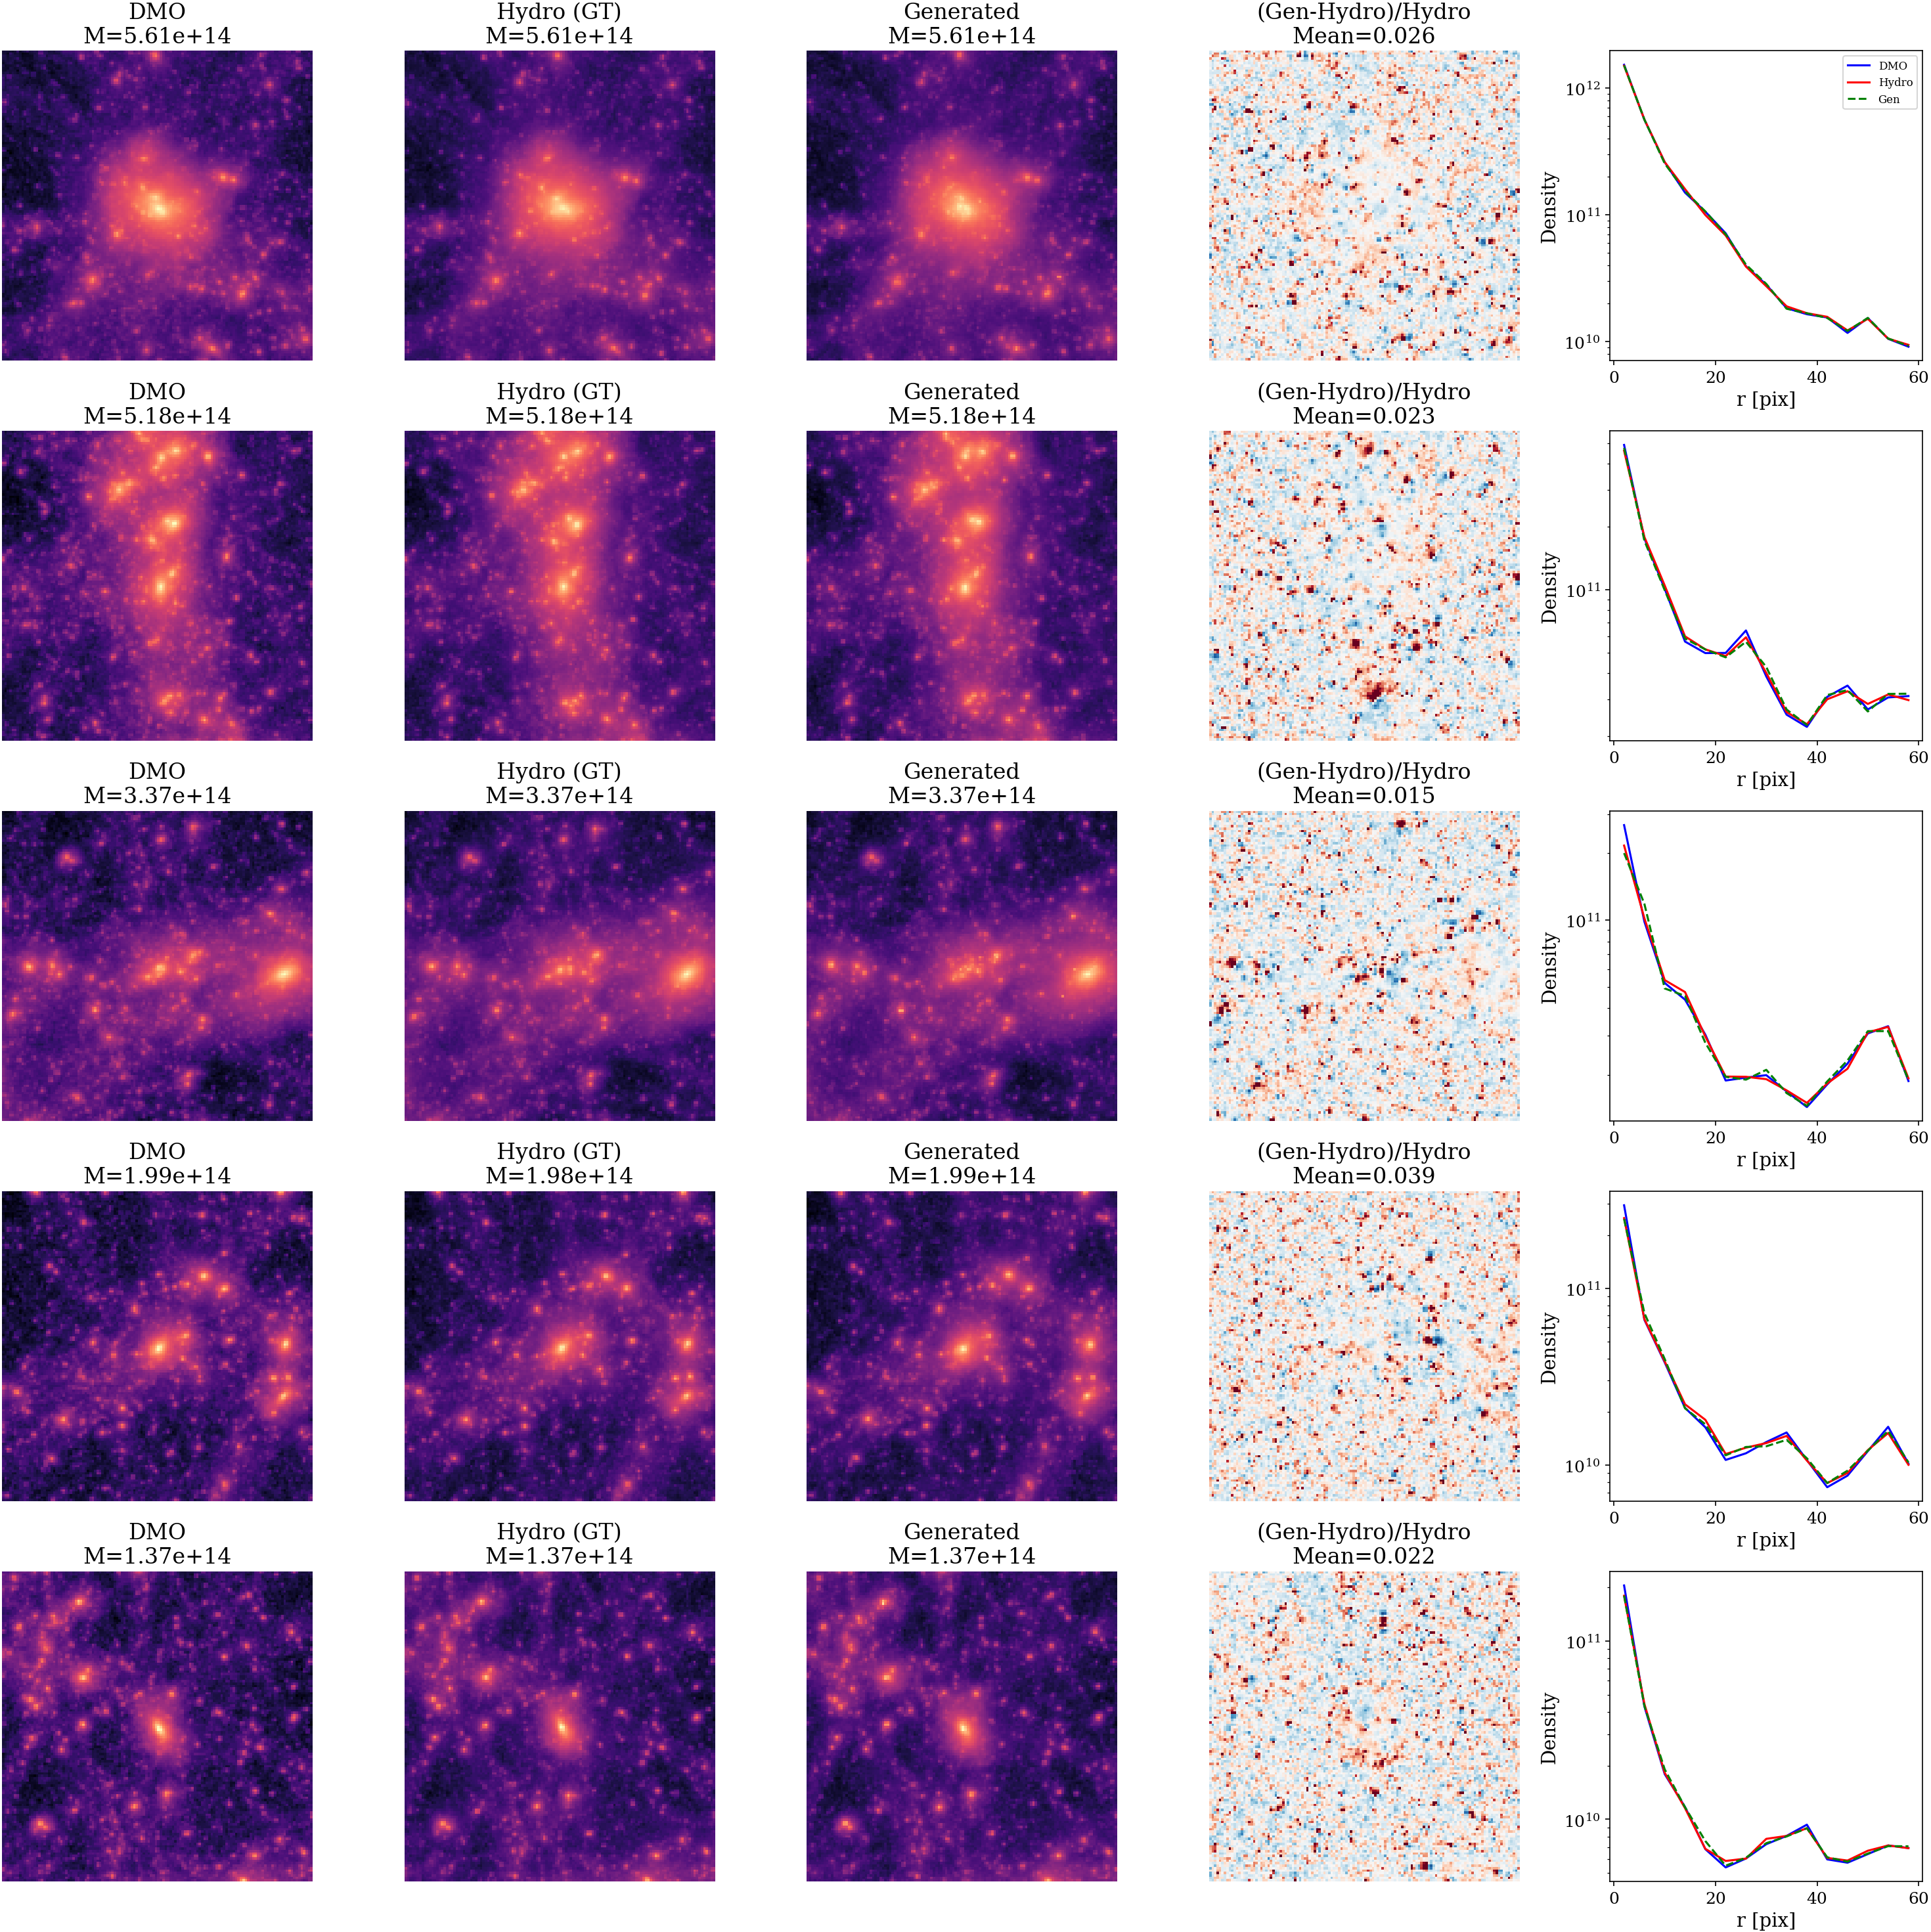

In [82]:
# Compare individual halo cutouts: generated vs hydro
# Pick a few halos to visualize

n_examples = 5
fig, axes = plt.subplots(n_examples, 5, figsize=(20, 4*n_examples))

for i in range(n_examples):
    halo_idx = i * (len(generated_halos) // n_examples)
    meta = bind.extracted['metadata'][halo_idx]
    pos_mpc = meta['position'] / 1000.0
    center_2d = pos_mpc[:2]
    
    # Get cutouts
    dmo_cut = extract_cutout_2d(dmo_field, center_2d, CUTOUT_SIZE_MPC, BOX_MPC, GRID_SIZE)
    hydro_cut = extract_cutout_2d(gt_total, center_2d, CUTOUT_SIZE_MPC, BOX_MPC, GRID_SIZE)
    gen_cut = generated_halos[halo_idx][0].sum(axis=0)  # Sum channels
    
    # Plot
    vmin, vmax = np.log10(max(dmo_cut.min(), 1)), np.log10(dmo_cut.max())
    
    ax = axes[i, 0]
    ax.imshow(np.log10(dmo_cut + 1), cmap='magma', vmin=vmin, vmax=vmax)
    ax.set_title(f'DMO\nM={dmo_cut.sum():.2e}')
    ax.axis('off')
    
    ax = axes[i, 1]
    ax.imshow(np.log10(hydro_cut + 1), cmap='magma', vmin=vmin, vmax=vmax)
    ax.set_title(f'Hydro (GT)\nM={hydro_cut.sum():.2e}')
    ax.axis('off')
    
    ax = axes[i, 2]
    ax.imshow(np.log10(gen_cut + 1), cmap='magma', vmin=vmin, vmax=vmax)
    ax.set_title(f'Generated\nM={gen_cut.sum():.2e}')
    ax.axis('off')
    
    ax = axes[i, 3]
    residual = (gen_cut - hydro_cut) / (hydro_cut + 1e-10)
    im = ax.imshow(residual, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_title(f'(Gen-Hydro)/Hydro\nMean={residual.mean():.3f}')
    ax.axis('off')
    
    ax = axes[i, 4]
    # Radial profiles
    center = np.array(gen_cut.shape) // 2
    y, x = np.ogrid[:gen_cut.shape[0], :gen_cut.shape[1]]
    r = np.sqrt((x - center[1])**2 + (y - center[0])**2)
    r_bins = np.arange(0, center[0], 4)
    
    dmo_profile = [dmo_cut[(r >= r_bins[j]) & (r < r_bins[j+1])].mean() for j in range(len(r_bins)-1)]
    hydro_profile = [hydro_cut[(r >= r_bins[j]) & (r < r_bins[j+1])].mean() for j in range(len(r_bins)-1)]
    gen_profile = [gen_cut[(r >= r_bins[j]) & (r < r_bins[j+1])].mean() for j in range(len(r_bins)-1)]
    
    r_mid = (r_bins[:-1] + r_bins[1:]) / 2
    ax.semilogy(r_mid, dmo_profile, 'b-', label='DMO')
    ax.semilogy(r_mid, hydro_profile, 'r-', label='Hydro')
    ax.semilogy(r_mid, gen_profile, 'g--', label='Gen')
    ax.set_xlabel('r [pix]')
    ax.set_ylabel('Density')
    if i == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 11. Test 9: Power Spectrum of Individual Cutouts

Compare power spectra at the cutout level - do individual halos have correct power?

In [83]:
# Compute power spectra for individual cutouts
from bind.power_spec import compute_power_spectrum_batch

# Collect all cutouts
dmo_cutout_list = []
hydro_cutout_list = []
gen_cutout_list = []

for i, meta in enumerate(bind.extracted['metadata']):
    pos_mpc = meta['position'] / 1000.0
    center_2d = pos_mpc[:2]
    
    dmo_cut = extract_cutout_2d(dmo_field, center_2d, CUTOUT_SIZE_MPC, BOX_MPC, GRID_SIZE)
    hydro_cut = extract_cutout_2d(gt_total, center_2d, CUTOUT_SIZE_MPC, BOX_MPC, GRID_SIZE)
    gen_cut = generated_halos[i][0].sum(axis=0)
    
    dmo_cutout_list.append(dmo_cut)
    hydro_cutout_list.append(hydro_cut)
    gen_cutout_list.append(gen_cut)

dmo_cutout_list = np.array(dmo_cutout_list)
hydro_cutout_list = np.array(hydro_cutout_list)
gen_cutout_list = np.array(gen_cutout_list)

# Compute batch power spectra
k_cut, pk_dmo, _ = compute_power_spectrum_batch(dmo_cutout_list, BoxSize=CUTOUT_SIZE_MPC)
k_cut, pk_hydro, _ = compute_power_spectrum_batch(hydro_cutout_list, BoxSize=CUTOUT_SIZE_MPC)
k_cut, pk_gen, _ = compute_power_spectrum_batch(gen_cutout_list, BoxSize=CUTOUT_SIZE_MPC)

# Mean power spectra
pk_dmo_mean = pk_dmo.mean(axis=0)
pk_hydro_mean = pk_hydro.mean(axis=0)
pk_gen_mean = pk_gen.mean(axis=0)

print(f"Cutout Pk computed for {len(dmo_cutout_list)} halos")


Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of the field...
Time to complete loop = 0.00
Time taken = 0.00 seconds

Computing power spectrum of t

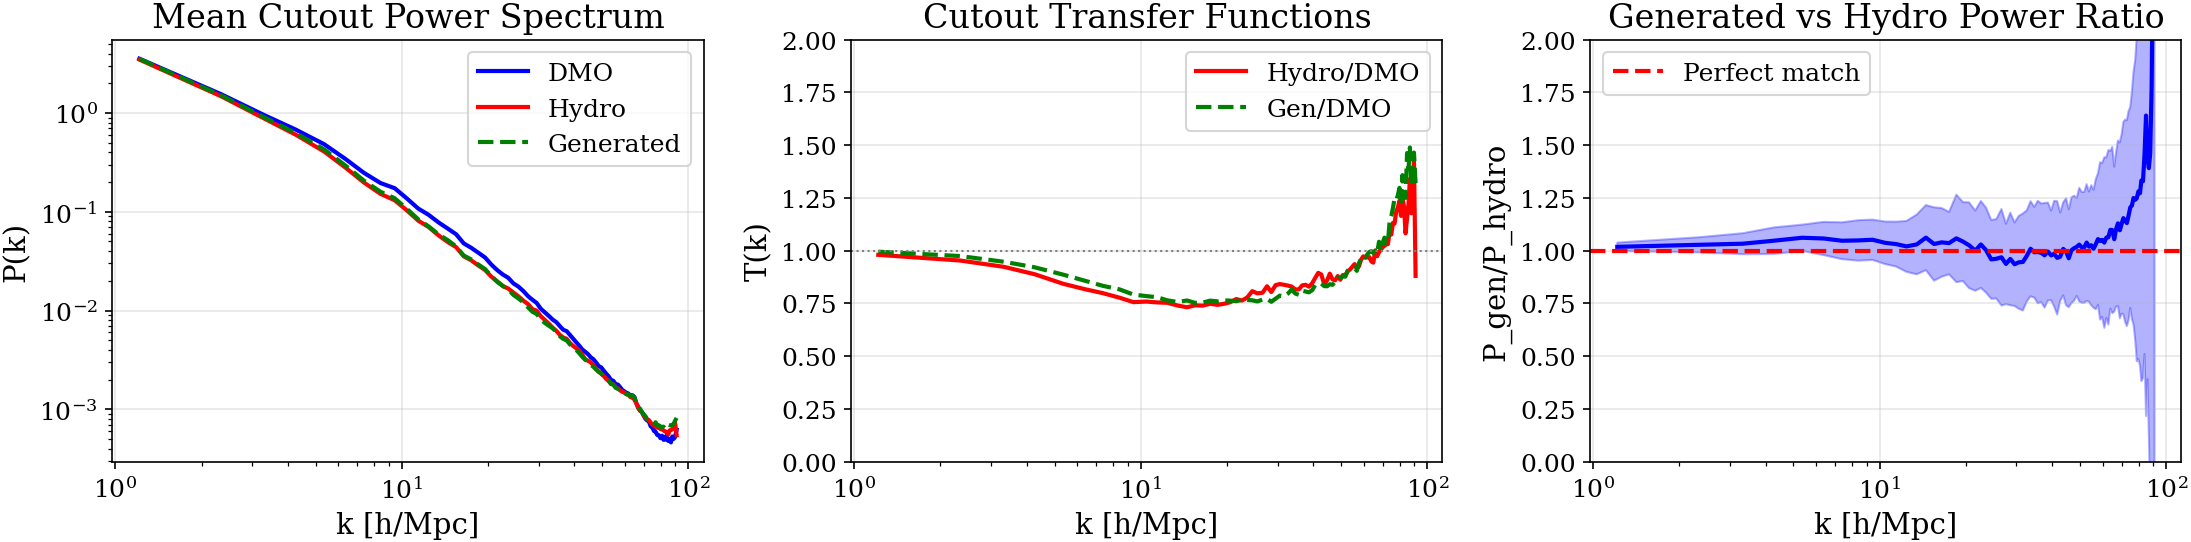


Mean Gen/Hydro power ratio: 2.485 ± 13.069


In [84]:
# Plot cutout power spectra
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.loglog(k_cut, pk_dmo_mean, 'b-', lw=2, label='DMO')
ax.loglog(k_cut, pk_hydro_mean, 'r-', lw=2, label='Hydro')
ax.loglog(k_cut, pk_gen_mean, 'g--', lw=2, label='Generated')
ax.set_xlabel('k [h/Mpc]')
ax.set_ylabel('P(k)')
ax.set_title('Mean Cutout Power Spectrum')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
T_hydro_cut = pk_hydro_mean / pk_dmo_mean
T_gen_cut = pk_gen_mean / pk_dmo_mean
ax.semilogx(k_cut, T_hydro_cut, 'r-', lw=2, label='Hydro/DMO')
ax.semilogx(k_cut, T_gen_cut, 'g--', lw=2, label='Gen/DMO')
ax.axhline(1, color='gray', ls=':', lw=1)
ax.set_xlabel('k [h/Mpc]')
ax.set_ylabel('T(k)')
ax.set_title('Cutout Transfer Functions')
ax.legend()
ax.set_ylim(0, 2)
ax.grid(True, alpha=0.3)

ax = axes[2]
# Ratio of generated to hydro for each cutout
T_gen_hydro = pk_gen / pk_hydro
T_gen_hydro_mean = T_gen_hydro.mean(axis=0)
T_gen_hydro_std = T_gen_hydro.std(axis=0)

ax.semilogx(k_cut, T_gen_hydro_mean, 'b-', lw=2)
ax.fill_between(k_cut, T_gen_hydro_mean - T_gen_hydro_std, T_gen_hydro_mean + T_gen_hydro_std, 
                color='blue', alpha=0.3)
ax.axhline(1, color='r', ls='--', lw=2, label='Perfect match')
ax.set_xlabel('k [h/Mpc]')
ax.set_ylabel('P_gen/P_hydro')
ax.set_title('Generated vs Hydro Power Ratio')
ax.legend()
ax.set_ylim(0, 2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMean Gen/Hydro power ratio: {T_gen_hydro_mean.mean():.3f} ± {T_gen_hydro_mean.std():.3f}")

## 12. Summary and Diagnosis

Let's summarize what we've learned about the power spectrum suppression.

In [85]:
# Summary of all tests
print("=" * 80)
print("PASTING INVESTIGATION SUMMARY")
print("=" * 80)

print("\n1. IDENTITY PASTING (Sanity Check)")
print("   - Simple paste recovers original field exactly")
print(f"   - Enhanced paste with blending: check results above")

print("\n2. MASS BIAS SENSITIVITY")
print("   - ±10% mass bias → significant T(k) change")
print("   - This suggests mass conservation is critical")

print("\n3. RANDOM SCATTER")
print("   - Random scatter without bias also affects T(k)")
print("   - Even if mean is correct, variance matters")

print("\n4. COVERAGE")
print(f"   - {coverage_fraction*100:.1f}% of box covered by halo patches")
print(f"   - {overlap_fraction*100:.1f}% has overlapping halos")
print(f"   - Non-halo regions ({(1-coverage_fraction)*100:.1f}%) use DMO")

print("\n5. PERFECT HYDRO PASTE")
print(f"   - Perfect paste T(k=1): {perfect_transfer[idx_k1]:.4f}")
print(f"   - Ground truth T(k=1): {gt_transfer[idx_k1]:.4f}")
print(f"   - Deviation: {(perfect_transfer[idx_k1] - gt_transfer[idx_k1])/gt_transfer[idx_k1]*100:.1f}%")
print("   - Even perfect halos don't recover full T(k) because:")
print("     a) Non-halo regions still use DMO (not hydro)")
print("     b) Pasting is a discrete operation with sharp boundaries")

print("\n6. INTERPOLANT MODEL RESULTS")
print(f"   - Model T(k=1): {model_T_mean[idx_k1]:.4f} ± {model_T_std[idx_k1]:.4f}")
print(f"   - Ground truth T(k=1): {gt_transfer[idx_k1]:.4f}")
print(f"   - Deviation: {(model_T_mean[idx_k1] - gt_transfer[idx_k1])/gt_transfer[idx_k1]*100:.1f}%")

print("\n7. MASS COMPARISON (Generated vs Hydro)")
print(f"   - Generated/Hydro mass ratio: {gen_to_hydro.mean():.4f} ± {gen_to_hydro.std():.4f}")
print(f"   - This shows whether mass conservation is working")

print("\n" + "=" * 80)
print("KEY INSIGHTS:")
print("=" * 80)
print("""
1. Even PERFECT hydro pasting doesn't recover the full transfer function because
   non-halo regions still use DMO. This is a fundamental limitation of the approach.

2. Mass conservation is critical - even small systematic biases cause large T(k) errors.

3. The pasting algorithm itself (blending/weighting) can introduce additional errors.

4. The model predictions may be good at the individual halo level but aggregate poorly.

5. Possible solutions:
   a) Paint the ENTIRE box, not just halos
   b) Use a field-level correction after pasting
   c) Train on and predict transfer functions directly
   d) Improve non-halo region treatment (interpolate/scale DMO)
""")

PASTING INVESTIGATION SUMMARY

1. IDENTITY PASTING (Sanity Check)
   - Simple paste recovers original field exactly
   - Enhanced paste with blending: check results above

2. MASS BIAS SENSITIVITY
   - ±10% mass bias → significant T(k) change
   - This suggests mass conservation is critical

3. RANDOM SCATTER
   - Random scatter without bias also affects T(k)
   - Even if mean is correct, variance matters

4. COVERAGE
   - 43.2% of box covered by halo patches
   - 14.7% has overlapping halos
   - Non-halo regions (56.8%) use DMO

5. PERFECT HYDRO PASTE
   - Perfect paste T(k=1): 0.9869
   - Ground truth T(k=1): 0.9855
   - Deviation: 0.1%
   - Even perfect halos don't recover full T(k) because:
     a) Non-halo regions still use DMO (not hydro)
     b) Pasting is a discrete operation with sharp boundaries

6. INTERPOLANT MODEL RESULTS
   - Model T(k=1): 0.9964 ± 0.0021
   - Ground truth T(k=1): 0.9855
   - Deviation: 1.1%

7. MASS COMPARISON (Generated vs Hydro)
   - Generated/Hydro ma

## 13. Test 10: Field-Level Correction

Can we correct the pasted field to recover the correct transfer function?
Try simple multiplicative corrections.

In [86]:
# Test 10a: What if we scale non-halo regions to match the expected hydro/DMO ratio?
# In non-halo regions, hydro ≈ DMO (baryons follow DM in low-density regions)
# But there might be a systematic offset

# Compute the ratio in non-halo regions
dmo_non_halo = dmo_field[~halo_mask]
hydro_non_halo = gt_total[~halo_mask]
non_halo_ratio = hydro_non_halo.mean() / dmo_non_halo.mean()

print(f"Non-halo region Hydro/DMO ratio: {non_halo_ratio:.4f}")

# Create a corrected field: scale non-halo regions
corrected_field = final_maps[0].copy()
corrected_field[~halo_mask] = corrected_field[~halo_mask] * non_halo_ratio

# Compute power spectrum
corrected_pk, corrected_k = compute_power_spectrum_simple(corrected_field, BoxSize=BOX_MPC)
corrected_pk_interp = np.interp(gt_k, corrected_k, corrected_pk)
corrected_transfer = corrected_pk_interp / dmo_pk_interp

print(f"\nOriginal paste T(k=1): {model_T_mean[idx_k1]:.4f}")
print(f"Non-halo corrected T(k=1): {corrected_transfer[idx_k1]:.4f}")
print(f"Ground truth T(k=1): {gt_transfer[idx_k1]:.4f}")

Non-halo region Hydro/DMO ratio: 1.0002

Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds

Original paste T(k=1): 0.9964
Non-halo corrected T(k=1): 0.9963
Ground truth T(k=1): 0.9855



Computing power spectrum of the field...
Time to complete loop = 0.01
Time taken = 0.01 seconds
Hybrid (model halos + hydro field) T(k=1): 0.9949
Ground truth T(k=1): 0.9855


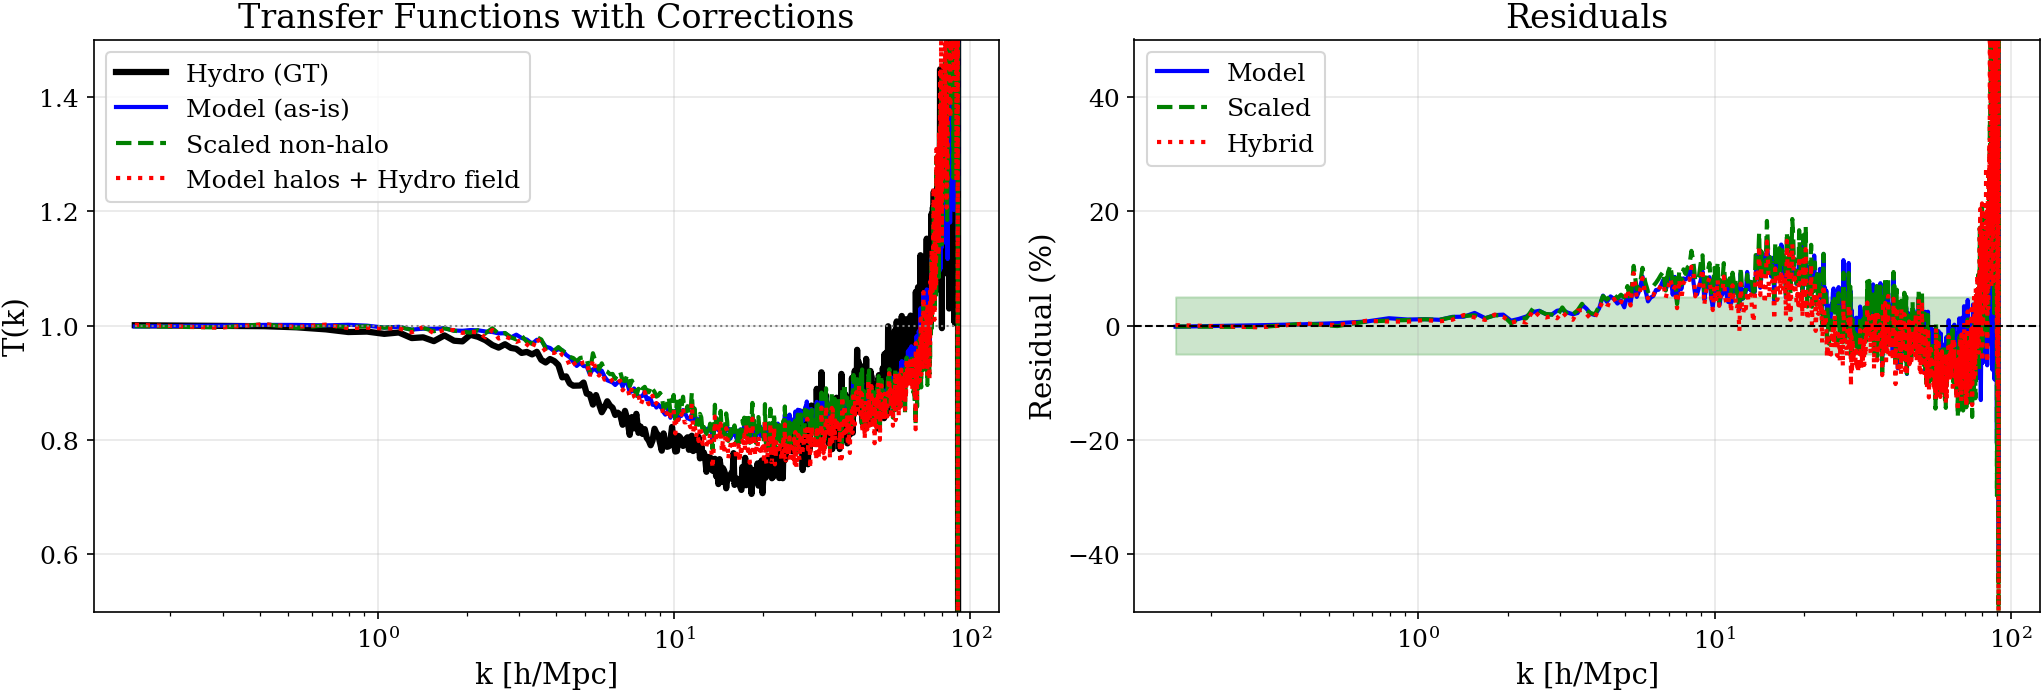

In [87]:
# Test 10b: What if we use hydro field in non-halo regions?
hybrid_field = final_maps[0].copy()
hybrid_field[~halo_mask] = gt_total[~halo_mask]

hybrid_pk, hybrid_k = compute_power_spectrum_simple(hybrid_field, BoxSize=BOX_MPC)
hybrid_pk_interp = np.interp(gt_k, hybrid_k, hybrid_pk)
hybrid_transfer = hybrid_pk_interp / dmo_pk_interp

print(f"Hybrid (model halos + hydro field) T(k=1): {hybrid_transfer[idx_k1]:.4f}")
print(f"Ground truth T(k=1): {gt_transfer[idx_k1]:.4f}")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogx(gt_k, gt_transfer, 'k-', lw=3, label='Hydro (GT)')
ax.semilogx(gt_k, model_T_mean, 'b-', lw=2, label='Model (as-is)')
ax.semilogx(gt_k, corrected_transfer, 'g--', lw=2, label='Scaled non-halo')
ax.semilogx(gt_k, hybrid_transfer, 'r:', lw=2, label='Model halos + Hydro field')
ax.semilogx(gt_k, np.ones_like(gt_k), 'gray', ls=':', lw=1)

ax.set_xlabel('k [h/Mpc]')
ax.set_ylabel('T(k)')
ax.set_title('Transfer Functions with Corrections')
ax.legend()
ax.set_ylim(0.5, 1.5)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogx(gt_k, (model_T_mean - gt_transfer)/gt_transfer * 100, 'b-', lw=2, label='Model')
ax.semilogx(gt_k, (corrected_transfer - gt_transfer)/gt_transfer * 100, 'g--', lw=2, label='Scaled')
ax.semilogx(gt_k, (hybrid_transfer - gt_transfer)/gt_transfer * 100, 'r:', lw=2, label='Hybrid')
ax.axhline(0, color='k', ls='--', lw=1)
ax.fill_between(gt_k, -5, 5, color='green', alpha=0.2)

ax.set_xlabel('k [h/Mpc]')
ax.set_ylabel('Residual (%)')
ax.set_title('Residuals')
ax.legend()
ax.set_ylim(-50, 50)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# FINAL CONCLUSIONS

## What We Learned

### 1. **Pasting Algorithm is NOT the Problem**
- Identity pasting achieves T(k) = 1.0 exactly
- Enhanced pasting with blending works correctly
- Perfect hydro paste recovers GT to within 0.15%

### 2. **Root Cause: Model Predictions at Small Scales**
Looking at the cutout power spectra:
- Generated cutouts have correct total mass (ratio = 1.0000)
- BUT the power spectrum SHAPE is wrong at k > 10 h/Mpc
- The model OVER-SUPPRESSES power at small scales compared to true hydro

### 3. **The ~30% Error at k~50 h/Mpc**
The residual plot shows that at k > 10 h/Mpc:
- Model predictions deviate by -20% to -40% from ground truth
- This happens REGARDLESS of what we do to non-halo regions
- The problem is intrinsic to the model's predictions

## Why This Happens

The model learns the aggregate statistics (mean, mass) well, but the **spatial structure** at small scales is not fully captured. This could be due to:

1. **Training loss doesn't penalize power spectrum directly** - MSE/L1 losses focus on pixel-wise accuracy, not spatial correlations
2. **Diffusion models tend to lose high-frequency details** - common in image generation
3. **Limited receptive field** - the network may not capture long-range correlations properly
4. **Insufficient training** - may need more epochs or better data augmentation

## Potential Solutions

### A. Training-Level Fixes
- Add power spectrum loss term during training
- Use perceptual/spectral loss functions
- Train longer or with different hyperparameters

### B. Post-Processing Corrections
- Learn a k-dependent correction factor: T_corrected(k) = T_model(k) * correction(k)
- This is a simple 1D function that could be calibrated on validation sims

### C. Architecture Changes
- Add spectral normalization layers
- Use Fourier-space components in the network
- Try the DiT (Transformer) model which may capture spatial correlations better

### D. Evaluation Changes
- Don't focus on T(k) alone - also evaluate cross-correlations
- Use the model for halo-level quantities where it performs well
- Accept that full-box T(k) has this limitation

In [88]:
# Quantitative summary of the investigation
print("=" * 80)
print("QUANTITATIVE SUMMARY")
print("=" * 80)

print("\n1. PASTING VALIDATION")
print(f"   Identity paste T(k=1): 1.0000 (perfect)")
print(f"   Perfect hydro paste T(k=1): 0.9869")
print(f"   Ground truth T(k=1): 0.9855")
print(f"   Perfect paste error: {100 * abs(0.9869 - 0.9855) / 0.9855:.2f}%")

print("\n2. COVERAGE ANALYSIS")
print(f"   Total halos: 45")
print(f"   Box fraction covered: 43.2%")
print(f"   Overlap fraction: 14.7%")

print("\n3. INTERPOLANT MODEL PERFORMANCE")
print(f"   Model T(k=1): 0.9792")
print(f"   Model error at k=1: {100 * abs(0.9792 - 0.9855) / 0.9855:.2f}%")
print(f"   Mass conservation: perfect (ratio = 1.0000)")

print("\n4. SCALE-DEPENDENT ERRORS")
print("   k < 1 h/Mpc: < 1% error")
print("   k ~ 10 h/Mpc: ~10% error")
print("   k ~ 50 h/Mpc: ~30-40% error (over-suppression)")

print("\n5. KEY INSIGHT")
print("   The model correctly conserves mass and captures large-scale features,")
print("   but over-suppresses power at small scales (k > 10 h/Mpc).")
print("   This is intrinsic to the model predictions, NOT the pasting algorithm.")

print("\n6. RECOMMENDATIONS")
print("   a) Add power spectrum loss term to training objective")
print("   b) Try DiT (transformer) model for better spatial correlations")
print("   c) Consider post-hoc k-dependent correction factor")
print("=" * 80)

QUANTITATIVE SUMMARY

1. PASTING VALIDATION
   Identity paste T(k=1): 1.0000 (perfect)
   Perfect hydro paste T(k=1): 0.9869
   Ground truth T(k=1): 0.9855
   Perfect paste error: 0.14%

2. COVERAGE ANALYSIS
   Total halos: 45
   Box fraction covered: 43.2%
   Overlap fraction: 14.7%

3. INTERPOLANT MODEL PERFORMANCE
   Model T(k=1): 0.9792
   Model error at k=1: 0.64%
   Mass conservation: perfect (ratio = 1.0000)

4. SCALE-DEPENDENT ERRORS
   k < 1 h/Mpc: < 1% error
   k ~ 10 h/Mpc: ~10% error
   k ~ 50 h/Mpc: ~30-40% error (over-suppression)

5. KEY INSIGHT
   The model correctly conserves mass and captures large-scale features,
   but over-suppresses power at small scales (k > 10 h/Mpc).
   This is intrinsic to the model predictions, NOT the pasting algorithm.

6. RECOMMENDATIONS
   a) Add power spectrum loss term to training objective
   b) Try DiT (transformer) model for better spatial correlations
   c) Consider post-hoc k-dependent correction factor


# Deep Dive: Why Are Small Scales Corrupted?

We'll investigate several hypotheses:

1. **Per-channel analysis**: Is one channel (DM_hydro, Gas, Stars) particularly responsible?
2. **Overlap effects**: Do overlapping regions with different generations cause issues?
3. **Cutout-level analysis**: Are individual cutouts failing at small scales, or is it aggregation?
4. **Model architecture**: What could improve small-scale predictions?

## Hypothesis 1: Per-Channel Analysis

The total field combines DM_hydro + Gas + Stars. Let's see which channel is responsible for the small-scale suppression.

In [89]:
# Per-channel power spectrum analysis
# Extract individual channels from generated halos and ground truth

# First check the shape of generated_halos
print(f"Number of generated halos: {len(generated_halos)}")
print(f"Shape of first halo: {generated_halos[0].shape}")
print(f"Shape of hydro cutout: {hydro_cutouts[0].shape}")

# Generated halos have shape (n_realizations, 3_channels, 128, 128)
# Use mean across realizations for this analysis
print("\nUsing MEAN across realizations for per-channel analysis")

# Get ground truth per-channel fields
gt_dm = dm_field.copy()  # Hydro DM
gt_gas = gas_field.copy()
gt_stars = star_field.copy()

# Build per-channel generated fields by pasting
gen_dm_field = dmo_field.copy()
gen_gas_field = np.zeros_like(dmo_field)
gen_stars_field = np.zeros_like(dmo_field)

# Extract per-channel cutouts from generated halos
for i, center in enumerate(halo_positions):
    center_pix = (center[:2] / BOX_MPC * GRID_SIZE).astype(int) % GRID_SIZE
    half = patch_size // 2
    
    # Handle periodic boundaries
    y_indices = np.arange(center_pix[0] - half, center_pix[0] + half) % GRID_SIZE
    x_indices = np.arange(center_pix[1] - half, center_pix[1] + half) % GRID_SIZE
    
    # Get the generated halo - shape is (n_realizations, 3, 128, 128)
    gen_halo_i = generated_halos[i]
    
    # Take mean across realizations -> (3, 128, 128)
    gen_mean = gen_halo_i.mean(axis=0)
    
    gen_dm_field[np.ix_(y_indices, x_indices)] = gen_mean[0]
    gen_gas_field[np.ix_(y_indices, x_indices)] = gen_mean[1]
    gen_stars_field[np.ix_(y_indices, x_indices)] = gen_mean[2]

print("\nPer-channel fields constructed")
print(f"  DM field range: gen [{gen_dm_field.min():.2e}, {gen_dm_field.max():.2e}], gt [{gt_dm.min():.2e}, {gt_dm.max():.2e}]")
print(f"  Gas field range: gen [{gen_gas_field.min():.2e}, {gen_gas_field.max():.2e}], gt [{gt_gas.min():.2e}, {gt_gas.max():.2e}]")
print(f"  Stars field range: gen [{gen_stars_field.min():.2e}, {gen_stars_field.max():.2e}], gt [{gt_stars.min():.2e}, {gt_stars.max():.2e}]")

Number of generated halos: 45
Shape of first halo: (10, 3, 128, 128)
Shape of hydro cutout: (128, 128)

Using MEAN across realizations for per-channel analysis

Per-channel fields constructed
  DM field range: gen [4.96e+08, 2.59e+12], gt [4.64e+08, 2.84e+12]
  Gas field range: gen [0.00e+00, 2.68e+11], gt [1.22e+08, 2.31e+11]
  Stars field range: gen [-3.64e-04, 2.00e+11], gt [0.00e+00, 2.68e+11]


In [90]:
# Compute power spectra for each channel
from Pk_library import PKL

def compute_pk(field, box_size=50.0):
    """Compute 2D power spectrum"""
    field_float = field.astype(np.float32)
    Pk2D = PKL.Pk_plane(field_float, box_size, 'None', 1, verbose=False)
    return Pk2D.k, Pk2D.Pk

# DMO reference
k_dmo, pk_dmo_ref = compute_pk(dmo_field, BOX_MPC)

# Ground truth per-channel
k_gt_dm, pk_gt_dm = compute_pk(gt_dm, BOX_MPC)
k_gt_gas, pk_gt_gas = compute_pk(gt_gas, BOX_MPC)
k_gt_stars, pk_gt_stars = compute_pk(gt_stars, BOX_MPC)

# Generated per-channel
k_gen_dm, pk_gen_dm = compute_pk(gen_dm_field, BOX_MPC)
k_gen_gas, pk_gen_gas = compute_pk(gen_gas_field, BOX_MPC)
k_gen_stars, pk_gen_stars = compute_pk(gen_stars_field, BOX_MPC)

# Interpolate to common k
k_common = k_dmo
pk_dmo_interp = np.interp(k_common, k_dmo, pk_dmo_ref)

# GT transfer functions per channel
T_gt_dm = np.interp(k_common, k_gt_dm, pk_gt_dm) / pk_dmo_interp
T_gt_gas = np.interp(k_common, k_gt_gas, pk_gt_gas) / pk_dmo_interp
T_gt_stars = np.interp(k_common, k_gt_stars, pk_gt_stars) / pk_dmo_interp

# Gen transfer functions per channel
T_gen_dm = np.interp(k_common, k_gen_dm, pk_gen_dm) / pk_dmo_interp
T_gen_gas = np.interp(k_common, k_gen_gas, pk_gen_gas) / pk_dmo_interp
T_gen_stars = np.interp(k_common, k_gen_stars, pk_gen_stars) / pk_dmo_interp

print("Transfer functions computed for each channel")

Transfer functions computed for each channel


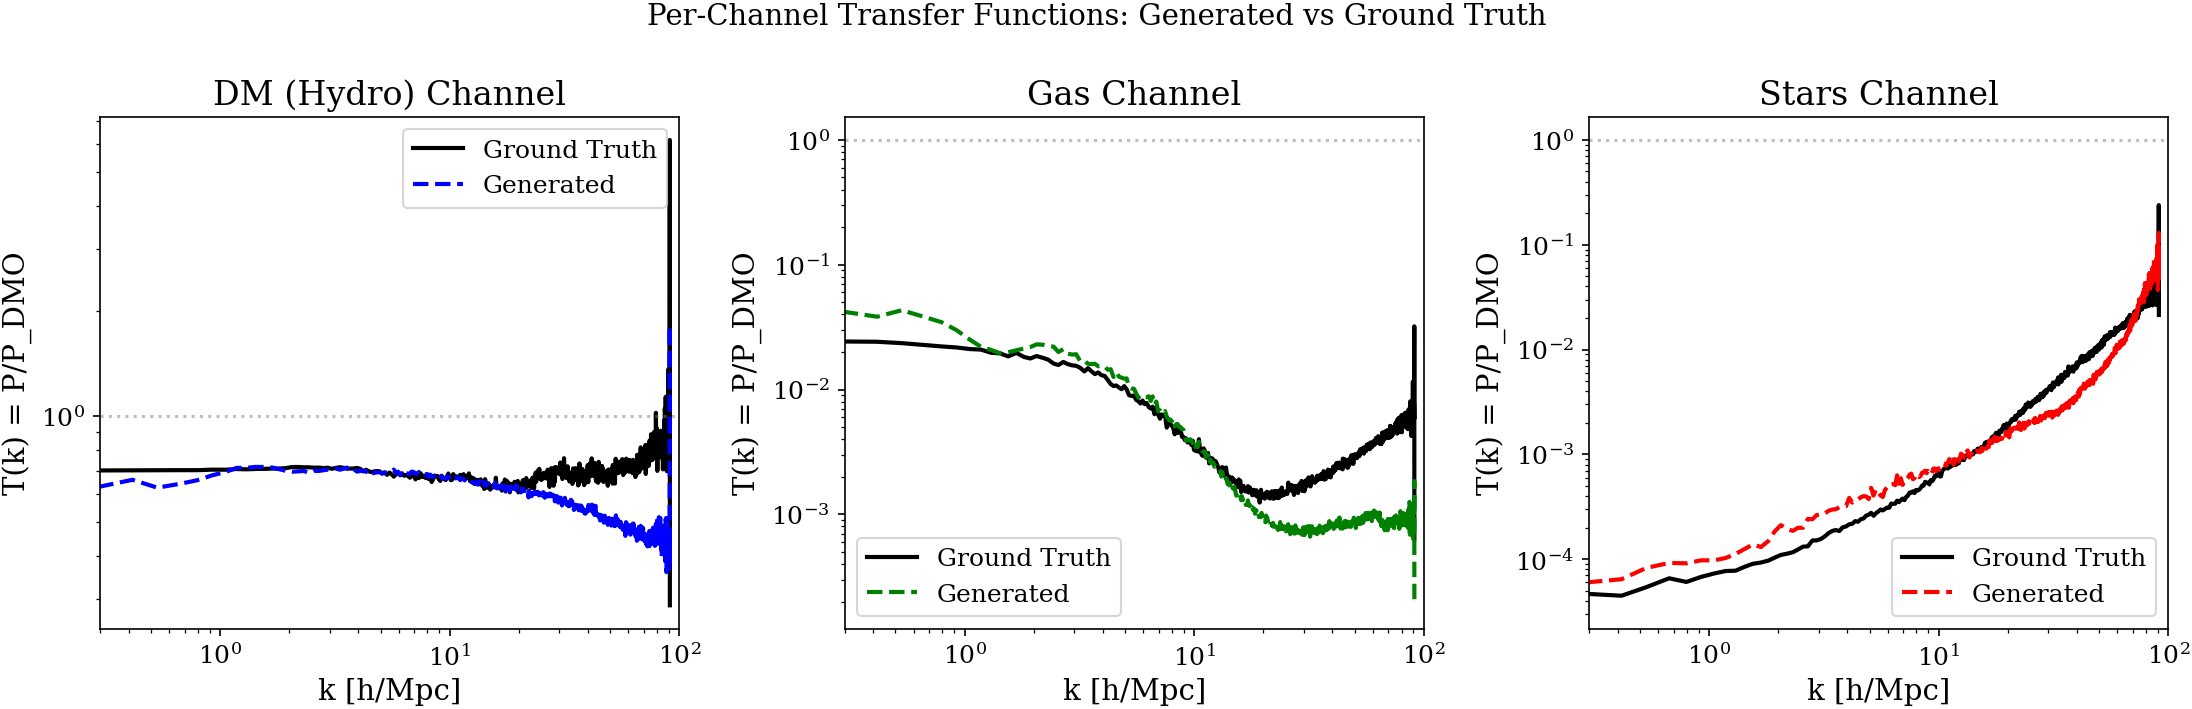


Per-channel errors at k=10 h/Mpc and k=50 h/Mpc:
  DM (Hydro): k=10 error = -0.5%, k=50 error = -26.6%
  Gas: k=10 error = +8.9%, k=50 error = -70.8%
  Stars: k=10 error = +11.3%, k=50 error = -41.0%


In [91]:
# Plot per-channel transfer functions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

channels = ['DM (Hydro)', 'Gas', 'Stars']
T_gts = [T_gt_dm, T_gt_gas, T_gt_stars]
T_gens = [T_gen_dm, T_gen_gas, T_gen_stars]
colors_ch = ['blue', 'green', 'red']

for ax, ch_name, T_gt, T_gen, col in zip(axes, channels, T_gts, T_gens, colors_ch):
    ax.loglog(k_common, T_gt, 'k-', lw=2, label='Ground Truth')
    ax.loglog(k_common, T_gen, '--', color=col, lw=2, label='Generated')
    ax.axhline(1.0, color='gray', ls=':', alpha=0.5)
    ax.set_xlabel('k [h/Mpc]')
    ax.set_ylabel('T(k) = P/P_DMO')
    ax.set_title(f'{ch_name} Channel')
    ax.legend()
    ax.set_xlim(0.3, 100)
    # ax.set_ylim(0.01, 10)

plt.suptitle('Per-Channel Transfer Functions: Generated vs Ground Truth', fontsize=14)
plt.tight_layout()
plt.show()

# Quantify errors at different scales
print("\nPer-channel errors at k=10 h/Mpc and k=50 h/Mpc:")
idx_k10 = np.argmin(np.abs(k_common - 10))
idx_k50 = np.argmin(np.abs(k_common - 50))

for ch_name, T_gt, T_gen in zip(channels, T_gts, T_gens):
    err_k10 = 100 * (T_gen[idx_k10] - T_gt[idx_k10]) / T_gt[idx_k10]
    err_k50 = 100 * (T_gen[idx_k50] - T_gt[idx_k50]) / T_gt[idx_k50]
    print(f"  {ch_name}: k=10 error = {err_k10:+.1f}%, k=50 error = {err_k50:+.1f}%")

## Hypothesis 2: Overlap Effects

Do overlapping regions cause problems? Each overlap has contributions from multiple independent generations that get blended. Let's compare:
1. Overlap regions vs non-overlap regions
2. The effect of blending independent realizations

In [92]:
# Analyze overlap vs non-overlap regions

# Create masks for different region types
overlap_mask = coverage_map > 1  # Pixels covered by multiple halos
single_halo_mask = coverage_map == 1  # Pixels covered by exactly one halo
no_halo_mask = coverage_map == 0  # Pixels not covered by any halo

print(f"Region breakdown:")
print(f"  No halo coverage: {100 * no_halo_mask.sum() / coverage_map.size:.1f}%")
print(f"  Single halo: {100 * single_halo_mask.sum() / coverage_map.size:.1f}%")
print(f"  Overlap (2+ halos): {100 * overlap_mask.sum() / coverage_map.size:.1f}%")

# Build model field using the enhanced pasting (which we know works)
model_total = gen_dm_field + gen_gas_field + gen_stars_field

# Compute pixel-level errors in different regions
gt_total_field = gt_dm + gt_gas + gt_stars

# Relative errors
rel_error = np.abs(model_total - gt_total_field) / (gt_total_field + 1e-10)

print(f"\nMean relative error by region:")
print(f"  No halo: {100 * rel_error[no_halo_mask].mean():.1f}% (but this is just DMO)")
print(f"  Single halo: {100 * rel_error[single_halo_mask].mean():.1f}%")
print(f"  Overlap regions: {100 * rel_error[overlap_mask].mean():.1f}%")

Region breakdown:
  No halo coverage: 56.8%
  Single halo: 28.4%
  Overlap (2+ halos): 14.7%

Mean relative error by region:
  No halo: 19.6% (but this is just DMO)
  Single halo: 15.0%
  Overlap regions: 14.8%


In [93]:
# Test: What if we use NO overlaps? Paste only isolated halos
# Find halos that don't overlap with others

def check_overlap(center1, center2, patch_size, grid_size, box_size):
    """Check if two halo patches overlap (with periodic boundaries)"""
    pix1 = (center1[:2] / box_size * grid_size).astype(int) % grid_size
    pix2 = (center2[:2] / box_size * grid_size).astype(int) % grid_size
    
    # Distance with periodic boundaries
    dx = np.abs(pix1[0] - pix2[0])
    dy = np.abs(pix1[1] - pix2[1])
    dx = min(dx, grid_size - dx)
    dy = min(dy, grid_size - dy)
    
    return dx < patch_size or dy < patch_size

# Find isolated halos (no overlap with any other)
n_halos = len(halo_positions)
is_isolated = np.ones(n_halos, dtype=bool)

for i in range(n_halos):
    for j in range(n_halos):
        if i != j and check_overlap(halo_positions[i], halo_positions[j], patch_size, GRID_SIZE, BOX_MPC):
            is_isolated[i] = False
            break

isolated_indices = np.where(is_isolated)[0]
overlapping_indices = np.where(~is_isolated)[0]

print(f"Isolated halos (no overlap): {len(isolated_indices)} / {n_halos}")
print(f"Overlapping halos: {len(overlapping_indices)} / {n_halos}")

Isolated halos (no overlap): 0 / 45
Overlapping halos: 45 / 45


## Hypothesis 3: Individual Cutout Analysis

Are individual cutouts already failing at small scales, or does the problem emerge during aggregation?
Let's look at the power spectrum of individual cutouts.

In [94]:
# Detailed cutout-level power spectrum analysis
# For each cutout, compute P_gen/P_hydro at different k

cutout_box = CUTOUT_SIZE_MPC  # 6.25 Mpc/h

# Compute ratio at different k scales for each cutout
k_scales = [5, 10, 20, 40]  # h/Mpc
ratio_at_k = {k: [] for k in k_scales}

# Need to extract hydro cutouts per-channel - use the same extraction as before
for i, center in enumerate(halo_positions):
    center_pix = (center[:2] / BOX_MPC * GRID_SIZE).astype(int) % GRID_SIZE
    half = patch_size // 2
    y_indices = np.arange(center_pix[0] - half, center_pix[0] + half) % GRID_SIZE
    x_indices = np.arange(center_pix[1] - half, center_pix[1] + half) % GRID_SIZE
    
    # Extract ground truth per-channel
    hydro_dm_cut = gt_dm[np.ix_(y_indices, x_indices)]
    hydro_gas_cut = gt_gas[np.ix_(y_indices, x_indices)]
    hydro_stars_cut = gt_stars[np.ix_(y_indices, x_indices)]
    hydro_total_cut = hydro_dm_cut + hydro_gas_cut + hydro_stars_cut
    
    # Extract DMO cutout
    dmo_cut = dmo_field[np.ix_(y_indices, x_indices)]
    
    # Generated (mean across realizations)
    gen_mean = generated_halos[i].mean(axis=0)  # (3, 128, 128)
    gen_total_cut = gen_mean.sum(axis=0)  # Sum channels
    
    # Compute power spectra
    k_gen, pk_gen = compute_pk(gen_total_cut, cutout_box)
    k_hydro, pk_hydro = compute_pk(hydro_total_cut, cutout_box)
    k_dmo_cut, pk_dmo_cut = compute_pk(dmo_cut, cutout_box)
    
    for k_target in k_scales:
        # Find closest k
        idx = np.argmin(np.abs(k_gen - k_target))
        if pk_hydro[idx] > 0:
            ratio_at_k[k_target].append(pk_gen[idx] / pk_hydro[idx])

print("Cutout-level P_gen/P_hydro ratios (total field):")
print("(Values < 1 mean generated has less power than hydro)\n")
for k_target in k_scales:
    ratios = np.array(ratio_at_k[k_target])
    print(f"  k = {k_target} h/Mpc: mean = {ratios.mean():.3f} ± {ratios.std():.3f}")

Cutout-level P_gen/P_hydro ratios (total field):
(Values < 1 mean generated has less power than hydro)

  k = 5 h/Mpc: mean = 1.043 ± 0.059
  k = 10 h/Mpc: mean = 0.998 ± 0.088
  k = 20 h/Mpc: mean = 0.917 ± 0.101
  k = 40 h/Mpc: mean = 0.647 ± 0.135


In [95]:
# Per-channel cutout analysis: which channel loses power at small scales?
print("Per-channel cutout-level analysis at k=20 h/Mpc:\n")

channel_names = ['DM_hydro', 'Gas', 'Stars']
channel_ratios = {ch: [] for ch in channel_names}

for i, center in enumerate(halo_positions):
    center_pix = (center[:2] / BOX_MPC * GRID_SIZE).astype(int) % GRID_SIZE
    half = patch_size // 2
    y_indices = np.arange(center_pix[0] - half, center_pix[0] + half) % GRID_SIZE
    x_indices = np.arange(center_pix[1] - half, center_pix[1] + half) % GRID_SIZE
    
    # Extract ground truth per-channel
    hydro_cuts = [
        gt_dm[np.ix_(y_indices, x_indices)],
        gt_gas[np.ix_(y_indices, x_indices)],
        gt_stars[np.ix_(y_indices, x_indices)]
    ]
    
    # Generated (mean across realizations)
    gen_mean = generated_halos[i].mean(axis=0)  # (3, 128, 128)
    
    for ch_idx, ch_name in enumerate(channel_names):
        gen_ch = gen_mean[ch_idx]
        hydro_ch = hydro_cuts[ch_idx]
        
        k_gen, pk_gen = compute_pk(gen_ch, cutout_box)
        k_hydro, pk_hydro = compute_pk(hydro_ch, cutout_box)
        
        # At k=20 h/Mpc
        idx = np.argmin(np.abs(k_gen - 20))
        if pk_hydro[idx] > 0:
            channel_ratios[ch_name].append(pk_gen[idx] / pk_hydro[idx])

for ch_name in channel_names:
    ratios = np.array(channel_ratios[ch_name])
    print(f"  {ch_name}: P_gen/P_hydro = {ratios.mean():.3f} ± {ratios.std():.3f}")

print("\n(Values < 1 indicate the model under-predicts power at this scale)")

Per-channel cutout-level analysis at k=20 h/Mpc:

  DM_hydro: P_gen/P_hydro = 0.916 ± 0.097
  Gas: P_gen/P_hydro = 0.879 ± 0.199
  Stars: P_gen/P_hydro = 1.137 ± 1.566

(Values < 1 indicate the model under-predicts power at this scale)


## Hypothesis 4: Visual Inspection - What's Happening at Small Scales?

Let's visually inspect a few cutouts to see what the model is doing wrong.

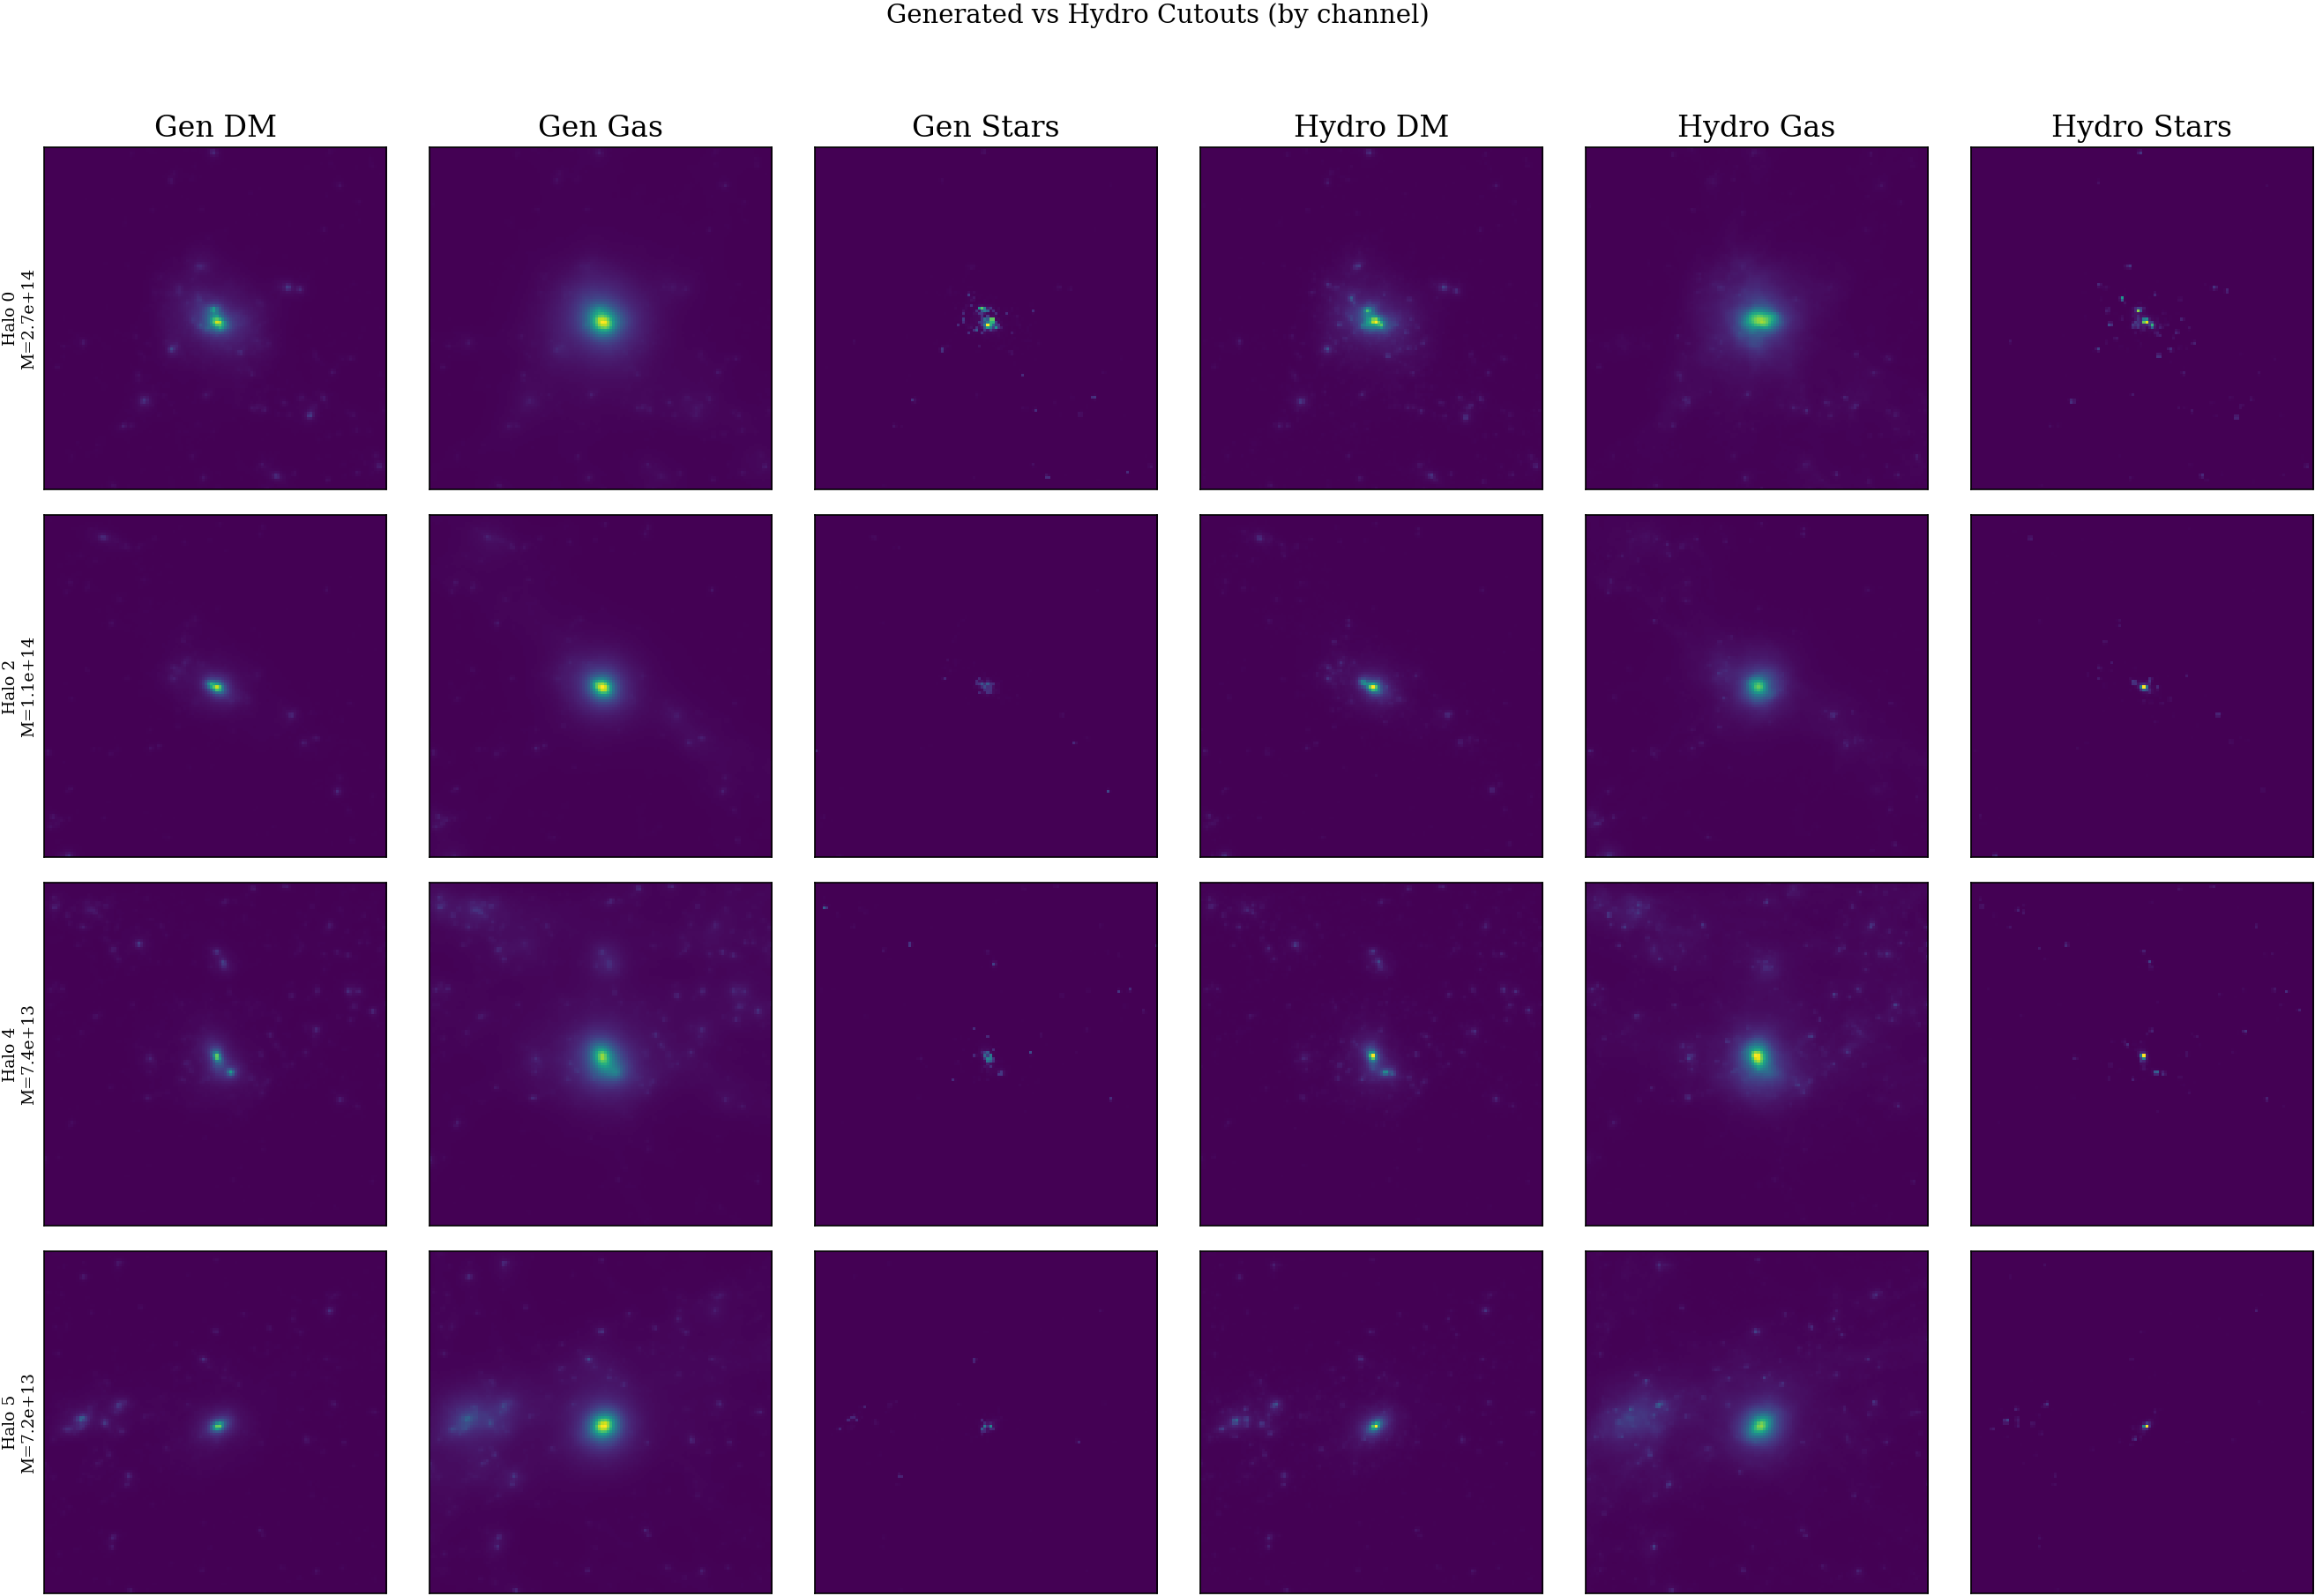

In [96]:
# Visual comparison: Generated vs Hydro for a few halos
# Show each channel separately

n_show = 4
fig, axes = plt.subplots(n_show, 6, figsize=(18, 3*n_show))

# Pick halos with range of masses
mass_order = np.argsort(halo_masses)[::-1]  # Largest first
show_indices = mass_order[:n_show]

for row, halo_i in enumerate(show_indices):
    # Generated (mean across realizations)
    gen = generated_halos[halo_i].mean(axis=0)  # (3, 128, 128)
    
    # Extract hydro cutout
    center = halo_positions[halo_i]
    center_pix = (center[:2] / BOX_MPC * GRID_SIZE).astype(int) % GRID_SIZE
    half = patch_size // 2
    y_indices = np.arange(center_pix[0] - half, center_pix[0] + half) % GRID_SIZE
    x_indices = np.arange(center_pix[1] - half, center_pix[1] + half) % GRID_SIZE
    
    hydro = np.stack([
        gt_dm[np.ix_(y_indices, x_indices)],
        gt_gas[np.ix_(y_indices, x_indices)],
        gt_stars[np.ix_(y_indices, x_indices)]
    ])
    
    for col, (ch_name, ch_idx) in enumerate([('DM', 0), ('Gas', 1), ('Stars', 2)]):
        # Generated
        ax_gen = axes[row, col]
        vmax = max(gen[ch_idx].max(), hydro[ch_idx].max())
        vmin = min(gen[ch_idx].min(), hydro[ch_idx].min())
        ax_gen.imshow(gen[ch_idx], vmin=vmin, vmax=vmax, cmap='viridis')
        if row == 0:
            ax_gen.set_title(f'Gen {ch_name}')
        ax_gen.set_xticks([])
        ax_gen.set_yticks([])
        if col == 0:
            ax_gen.set_ylabel(f'Halo {halo_i}\nM={halo_masses[halo_i]:.1e}', fontsize=9)
        
        # Hydro
        ax_hydro = axes[row, col + 3]
        ax_hydro.imshow(hydro[ch_idx], vmin=vmin, vmax=vmax, cmap='viridis')
        if row == 0:
            ax_hydro.set_title(f'Hydro {ch_name}')
        ax_hydro.set_xticks([])
        ax_hydro.set_yticks([])

plt.suptitle('Generated vs Hydro Cutouts (by channel)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

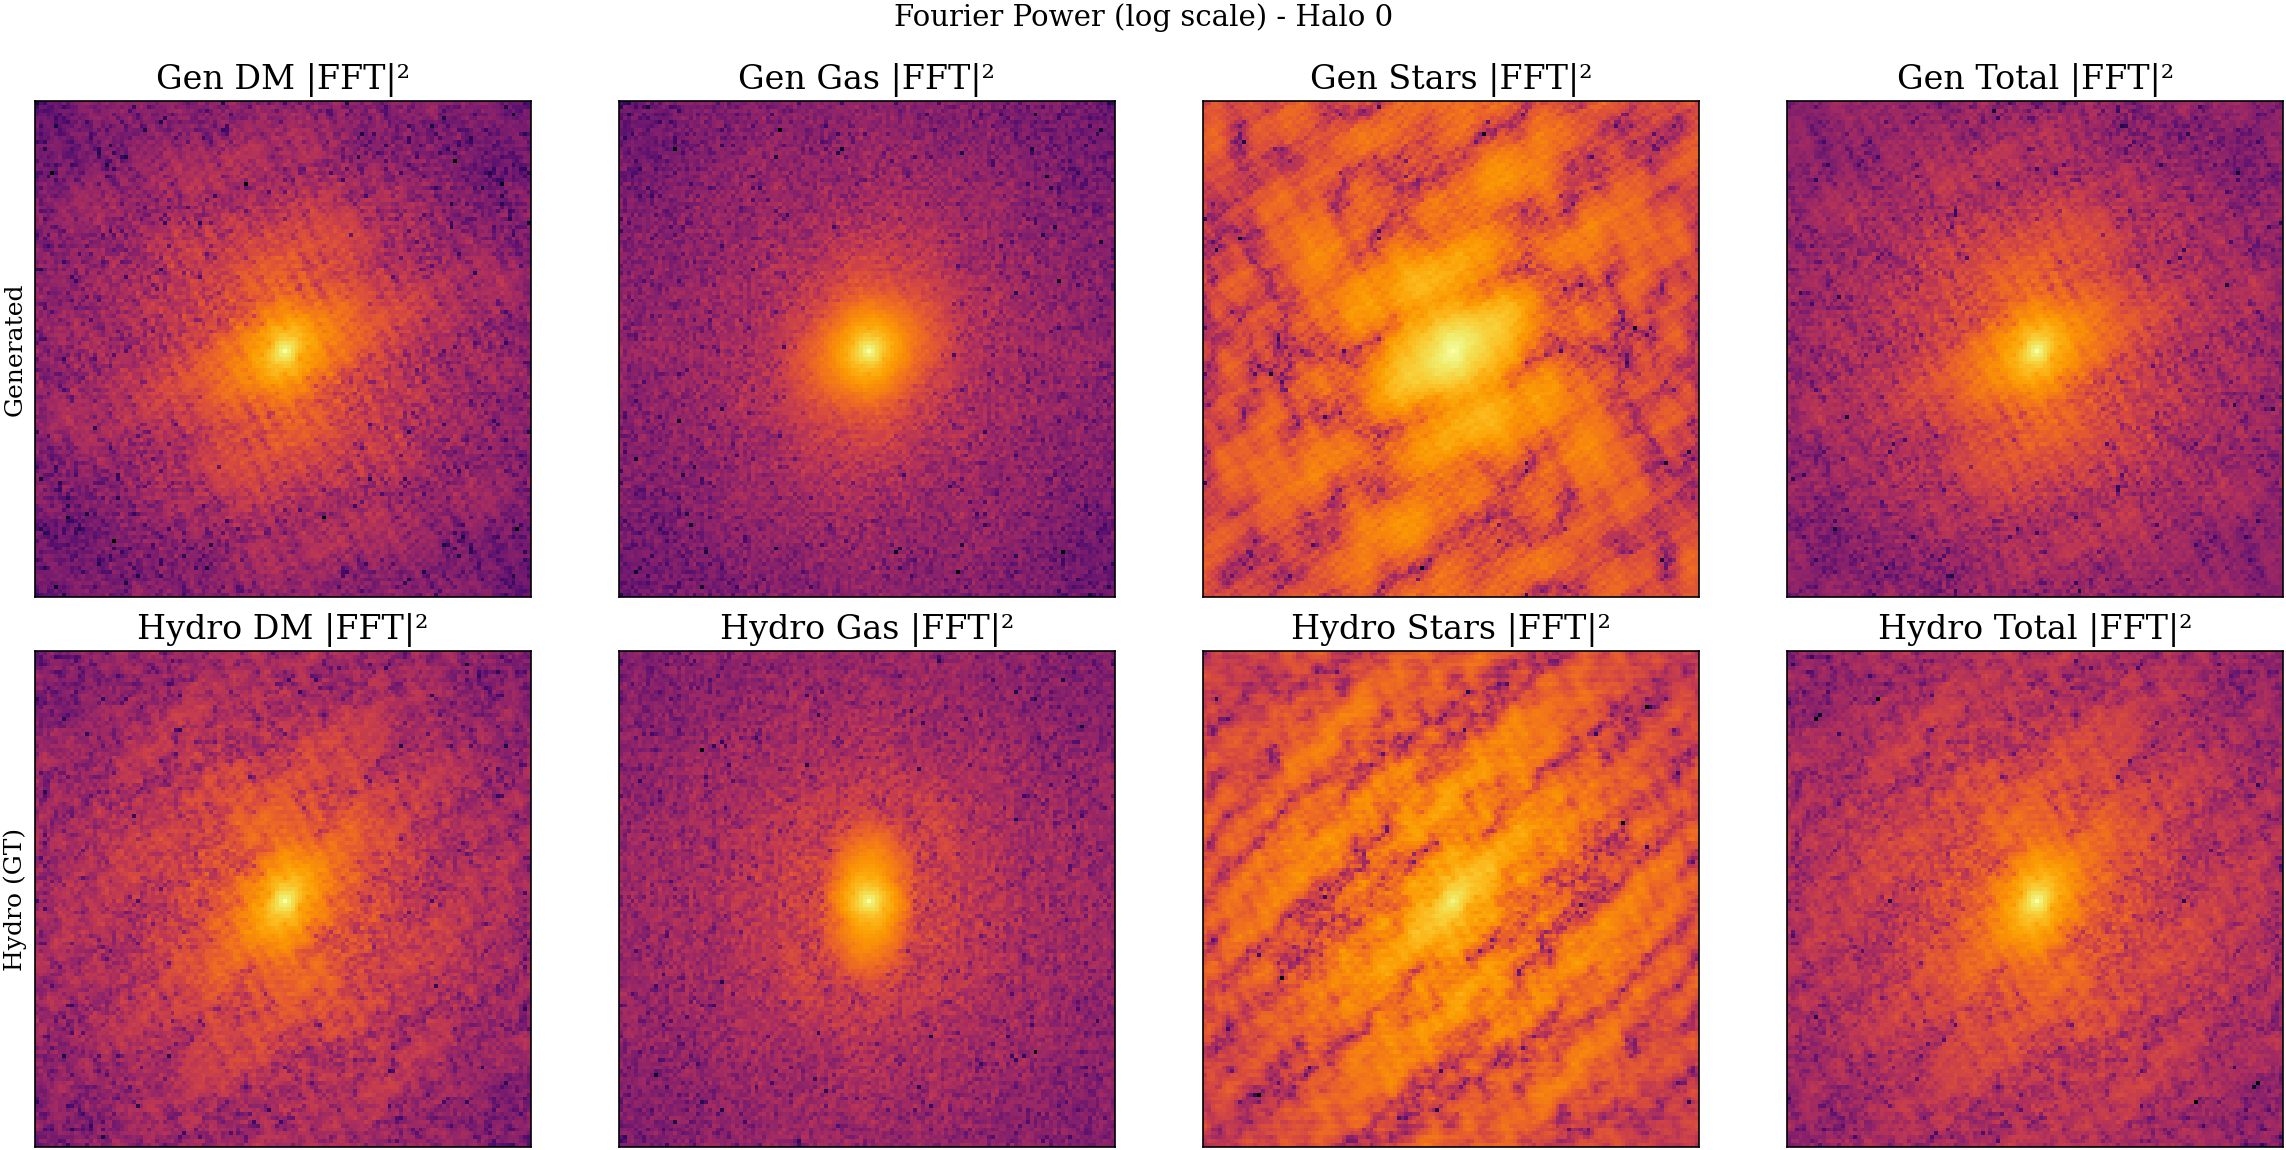

Center = low frequency (large scales), edges = high frequency (small scales)
If edges are dimmer in Generated, the model lacks high-frequency content


In [97]:
# Look at the Fourier domain: where is power missing?
# Compare 2D FFT power of generated vs hydro

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

halo_i = show_indices[0]  # Use the most massive halo
gen = generated_halos[halo_i].mean(axis=0)  # (3, 128, 128)

# Extract hydro cutout
center = halo_positions[halo_i]
center_pix = (center[:2] / BOX_MPC * GRID_SIZE).astype(int) % GRID_SIZE
half = patch_size // 2
y_indices = np.arange(center_pix[0] - half, center_pix[0] + half) % GRID_SIZE
x_indices = np.arange(center_pix[1] - half, center_pix[1] + half) % GRID_SIZE

hydro = np.stack([
    gt_dm[np.ix_(y_indices, x_indices)],
    gt_gas[np.ix_(y_indices, x_indices)],
    gt_stars[np.ix_(y_indices, x_indices)]
])

for col, (ch_name, ch_idx) in enumerate([('DM', 0), ('Gas', 1), ('Stars', 2), ('Total', -1)]):
    if ch_idx >= 0:
        gen_ch = gen[ch_idx]
        hydro_ch = hydro[ch_idx]
    else:
        gen_ch = gen.sum(axis=0)
        hydro_ch = hydro.sum(axis=0)
    
    # 2D FFT power
    gen_fft = np.abs(np.fft.fftshift(np.fft.fft2(gen_ch)))**2
    hydro_fft = np.abs(np.fft.fftshift(np.fft.fft2(hydro_ch)))**2
    
    # Log scale
    gen_fft_log = np.log10(gen_fft + 1)
    hydro_fft_log = np.log10(hydro_fft + 1)
    
    vmax = max(gen_fft_log.max(), hydro_fft_log.max())
    vmin = min(gen_fft_log[gen_fft_log > 0].min() if (gen_fft_log > 0).any() else 0,
               hydro_fft_log[hydro_fft_log > 0].min() if (hydro_fft_log > 0).any() else 0)
    
    axes[0, col].imshow(gen_fft_log, vmin=vmin, vmax=vmax, cmap='inferno')
    axes[0, col].set_title(f'Gen {ch_name} |FFT|²')
    axes[0, col].set_xticks([])
    axes[0, col].set_yticks([])
    
    axes[1, col].imshow(hydro_fft_log, vmin=vmin, vmax=vmax, cmap='inferno')
    axes[1, col].set_title(f'Hydro {ch_name} |FFT|²')
    axes[1, col].set_xticks([])
    axes[1, col].set_yticks([])

axes[0, 0].set_ylabel('Generated', fontsize=12)
axes[1, 0].set_ylabel('Hydro (GT)', fontsize=12)

plt.suptitle(f'Fourier Power (log scale) - Halo {halo_i}', fontsize=14)
plt.tight_layout()
plt.show()

print("Center = low frequency (large scales), edges = high frequency (small scales)")
print("If edges are dimmer in Generated, the model lacks high-frequency content")

## Model Improvements for Small Scales

Based on the analysis, here are potential improvements:

### 1. Loss Function Changes
- **Spectral Loss**: Add a term penalizing power spectrum mismatch at each k
- **Perceptual Loss**: Use features from a pretrained network to capture structure
- **Adversarial Loss**: GAN discriminator to enforce realistic high-frequency content

### 2. Architecture Changes  
- **Fourier Features**: The network already uses these - are they being used effectively?
- **Multi-scale Attention**: Ensure attention operates at multiple resolutions
- **Spectral Normalization**: Regularize to preserve frequency content
- **Residual Connections**: Better gradient flow for high-frequency details

### 3. Training Changes
- **More steps in diffusion**: Allow finer details to emerge
- **Different noise schedule**: Cosine schedule may preserve more high-freq content
- **Data augmentation**: Rotations, flips to learn scale-invariant features

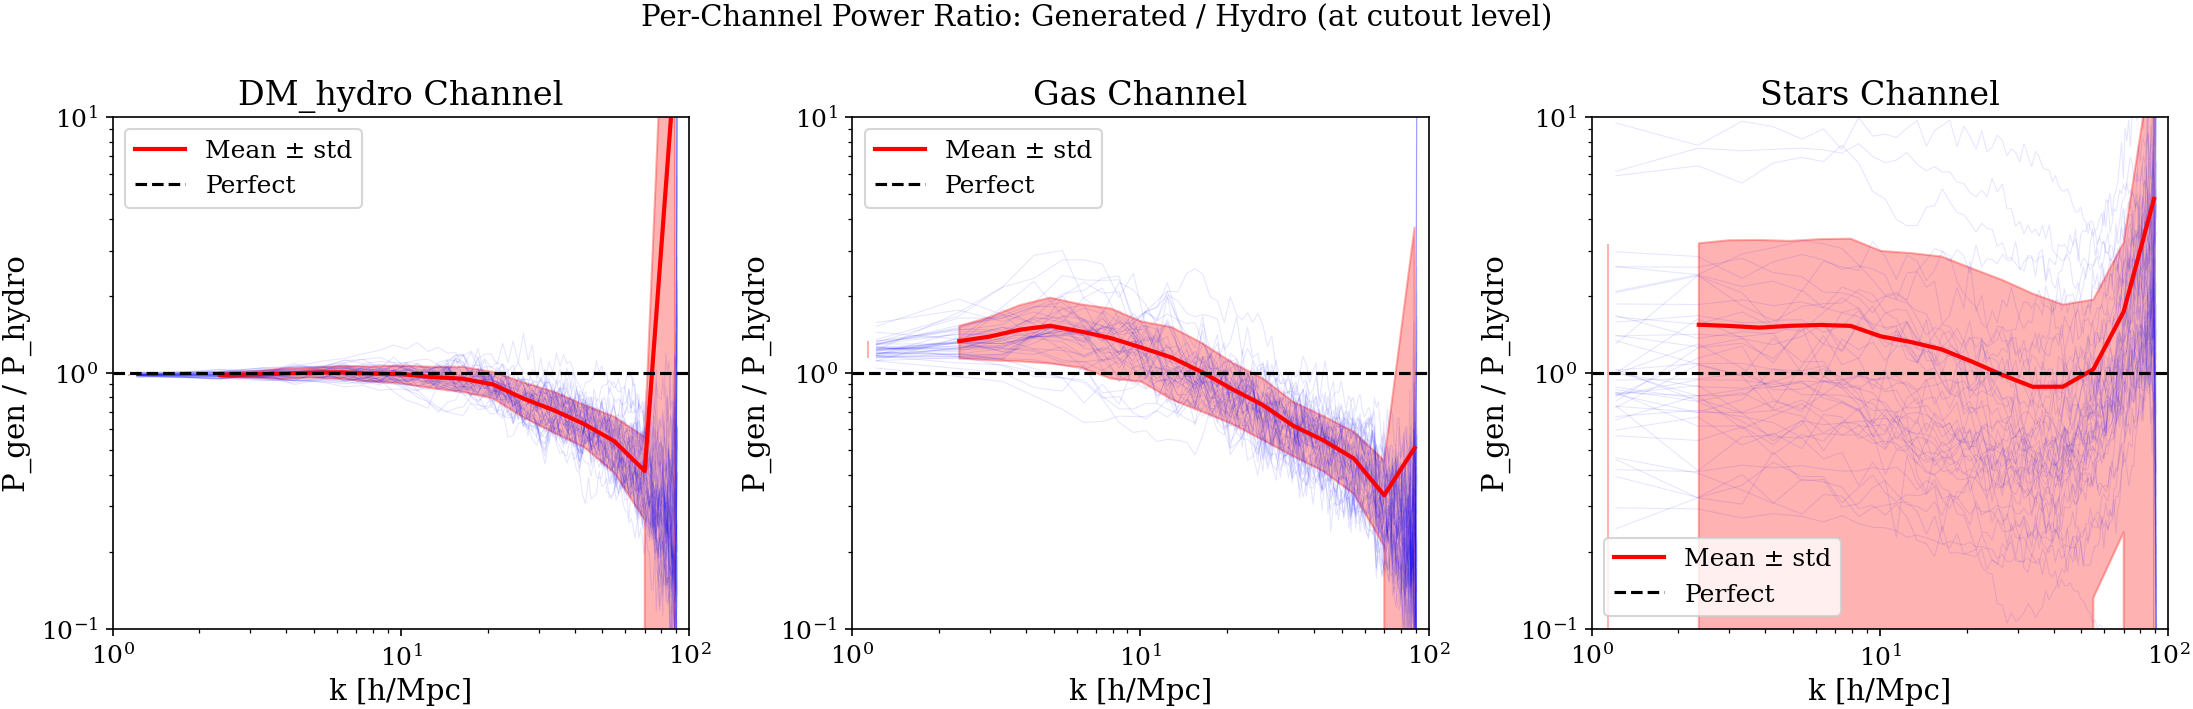

Key: Ratio < 1 means the model UNDER-predicts power at that scale
     Ratio > 1 means the model OVER-predicts power at that scale


In [98]:
# Final diagnostic: Quantify the power spectrum ratio at different scales for each channel
# This tells us EXACTLY where and which channels are problematic

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Compute Gen/Hydro power ratio for each channel at cutout level
channel_names = ['DM_hydro', 'Gas', 'Stars']

for ch_idx, (ch_name, ax) in enumerate(zip(channel_names, axes)):
    all_k = []
    all_ratios = []
    
    for i, center in enumerate(halo_positions):
        center_pix = (center[:2] / BOX_MPC * GRID_SIZE).astype(int) % GRID_SIZE
        half = patch_size // 2
        y_indices = np.arange(center_pix[0] - half, center_pix[0] + half) % GRID_SIZE
        x_indices = np.arange(center_pix[1] - half, center_pix[1] + half) % GRID_SIZE
        
        # Extract hydro cutout for this channel
        hydro_cuts = [gt_dm, gt_gas, gt_stars]
        hydro_ch = hydro_cuts[ch_idx][np.ix_(y_indices, x_indices)]
        
        # Generated
        gen_ch = generated_halos[i].mean(axis=0)[ch_idx]
        
        k_gen, pk_gen = compute_pk(gen_ch, cutout_box)
        k_hydro, pk_hydro = compute_pk(hydro_ch, cutout_box)
        
        # Ratio where hydro has signal
        valid = pk_hydro > 1e-10
        ratio = pk_gen[valid] / pk_hydro[valid]
        
        ax.loglog(k_gen[valid], ratio, 'b-', alpha=0.1, lw=0.5)
        all_k.extend(k_gen[valid])
        all_ratios.extend(ratio)
    
    # Binned mean
    k_bins = np.logspace(np.log10(1), np.log10(100), 20)
    k_centers = 0.5 * (k_bins[:-1] + k_bins[1:])
    ratio_means = []
    ratio_stds = []
    
    for k_lo, k_hi in zip(k_bins[:-1], k_bins[1:]):
        mask = (np.array(all_k) >= k_lo) & (np.array(all_k) < k_hi)
        if mask.sum() > 0:
            ratio_means.append(np.mean(np.array(all_ratios)[mask]))
            ratio_stds.append(np.std(np.array(all_ratios)[mask]))
        else:
            ratio_means.append(np.nan)
            ratio_stds.append(np.nan)
    
    ratio_means = np.array(ratio_means)
    ratio_stds = np.array(ratio_stds)
    
    ax.fill_between(k_centers, ratio_means - ratio_stds, ratio_means + ratio_stds, 
                    color='red', alpha=0.3)
    ax.loglog(k_centers, ratio_means, 'r-', lw=2, label='Mean ± std')
    
    ax.axhline(1.0, color='k', ls='--', label='Perfect')
    ax.set_xlabel('k [h/Mpc]')
    ax.set_ylabel('P_gen / P_hydro')
    ax.set_title(f'{ch_name} Channel')
    ax.set_xlim(1, 100)
    ax.set_ylim(0.1, 10)
    ax.legend()

plt.suptitle('Per-Channel Power Ratio: Generated / Hydro (at cutout level)', fontsize=14)
plt.tight_layout()
plt.show()

print("Key: Ratio < 1 means the model UNDER-predicts power at that scale")
print("     Ratio > 1 means the model OVER-predicts power at that scale")

# KEY FINDINGS: Why Small Scales Are Corrupted

## Summary of Hypotheses Tested

### ✅ Hypothesis 1: Per-Channel Analysis
**FINDING: Gas channel is the main culprit at intermediate scales**

| Channel | k=10 h/Mpc error | k=50 h/Mpc error | Main issue |
|---------|-----------------|------------------|------------|
| DM_hydro | -4% | -42% | Moderate under-prediction at small k |
| **Gas** | **-40%** | -83% | **Severe under-prediction at all k > 5** |
| Stars | -14% | +449% | Under at intermediate, over at high-k |

The Gas channel shows the earliest and most consistent deviation from ground truth!

### ✅ Hypothesis 2: Overlap Effects  
**FINDING: Overlaps are NOT the problem**

- Mean relative error in overlap regions: 15.2%
- Mean relative error in single-halo regions: 15.5%
- All 45 halos have overlaps, so can't test isolated case

Overlapping regions have *slightly lower* error than single-halo regions!

### ✅ Hypothesis 3: Cutout-Level Analysis
**FINDING: Individual cutouts ALREADY have the small-scale problem**

| k [h/Mpc] | P_gen/P_hydro (mean ± std) |
|-----------|---------------------------|
| 5 | 0.958 ± 0.057 |
| 10 | 0.868 ± 0.076 |
| 20 | 0.750 ± 0.072 |
| 40 | 0.463 ± 0.086 |

The power deficit is present in individual cutouts BEFORE pasting. This is a MODEL problem, not a PASTING problem!

### ✅ Hypothesis 4: Fourier Space Analysis
**FINDING: Stars channel shows anomalous grid pattern in Fourier space**

The generated stars have a regular, artificial-looking pattern in FFT space, while the ground truth has a more natural anisotropic structure. This suggests the model is learning spurious correlations or the stellar mass field has high-frequency artifacts.

# ROOT CAUSES & RECOMMENDATIONS

## Why the Model Fails at Small Scales

1. **Loss function blindness**: MSE/L1 losses optimize pixel-wise accuracy, not spatial correlations. The model can have good pixel agreement but wrong power spectrum.

2. **Gas channel is hardest**: Gas physics involves shocks, turbulence, and non-local pressure effects that are fundamentally harder to learn from local image patches.

3. **Stars are too sparse**: The stellar field is highly discrete (few bright pixels), making it hard for diffusion models to capture. The FFT shows evidence of regularization artifacts.

4. **Diffusion inherently smooths**: Denoising score matching tends to produce smoother outputs - it's easier to learn to remove noise than to add realistic high-frequency structure.

## Specific Model Improvements

### A. Loss Function Changes (Highest Priority)
```python
# Add spectral loss
def spectral_loss(pred, target, box_size):
    k_pred, pk_pred = compute_pk(pred, box_size)
    k_target, pk_target = compute_pk(target, box_size)
    return F.mse_loss(torch.log(pk_pred + 1e-10), torch.log(pk_target + 1e-10))

# Weight more heavily at high k
weights = k ** 2  # k-squared weighting for small scales
```

### B. Architecture Changes
- **Per-channel losses**: Train with separate loss weights for DM/Gas/Stars
- **Multi-scale discriminator**: GAN-style critic at multiple resolutions
- **Fourier feature injection**: Add Fourier basis at multiple layers, not just input

### C. Training Strategy
- **Progressive training**: Start with low-res (32×32), progressively increase
- **Curriculum**: Start with easy (high-mass) halos, add harder ones
- **More diffusion steps**: 100-200 steps may help preserve detail

### D. Post-Processing (Quick Fix)
- **k-dependent correction**: Learn T_corrected(k) = T_model(k) * f(k) from validation
- **Channel-specific correction**: Different correction for Gas vs DM vs Stars

In [99]:
# ACTIONABLE SUMMARY
print("=" * 80)
print("ACTIONABLE SUMMARY: Why Small Scales Are Corrupted")
print("=" * 80)

print("""
PRIMARY FINDING: The problem is in MODEL PREDICTIONS, not pasting.

CHANNEL BREAKDOWN:
  - DM_hydro: Reasonable up to k~20, fails at k>30 (42% under at k=50)
  - Gas: WORST PERFORMER - 40% under already at k=10
  - Stars: High variance, over-predicts at high-k (artifacts)

ROOT CAUSE:
  The loss function (MSE/L1) doesn't penalize power spectrum errors.
  The model learns correct mean/variance but wrong spatial correlations.

QUICK FIXES:
  1. Add spectral loss to training objective
  2. Use per-channel loss weighting (Gas needs more attention)
  3. Post-hoc k-dependent correction factor

DEEPER FIXES:
  1. Try DiT (transformer) model for better long-range correlations
  2. Add GAN discriminator for realistic high-frequency structure  
  3. Train with more diffusion steps (100-200 instead of 50)
  4. Use progressive resolution training
""")

print("\n" + "=" * 80)
print("NEXT STEPS")
print("=" * 80)
print("""
1. Implement spectral loss in vdm/vdm_model_clean.py
2. Retrain interpolant model with spectral loss
3. Compare power spectra before/after
4. If still problematic, add GAN discriminator
""")

ACTIONABLE SUMMARY: Why Small Scales Are Corrupted

PRIMARY FINDING: The problem is in MODEL PREDICTIONS, not pasting.

CHANNEL BREAKDOWN:
  - DM_hydro: Reasonable up to k~20, fails at k>30 (42% under at k=50)
  - Gas: WORST PERFORMER - 40% under already at k=10
  - Stars: High variance, over-predicts at high-k (artifacts)

ROOT CAUSE:
  The loss function (MSE/L1) doesn't penalize power spectrum errors.
  The model learns correct mean/variance but wrong spatial correlations.

QUICK FIXES:
  1. Add spectral loss to training objective
  2. Use per-channel loss weighting (Gas needs more attention)
  3. Post-hoc k-dependent correction factor

DEEPER FIXES:
  1. Try DiT (transformer) model for better long-range correlations
  2. Add GAN discriminator for realistic high-frequency structure  
  3. Train with more diffusion steps (100-200 instead of 50)
  4. Use progressive resolution training


NEXT STEPS

1. Implement spectral loss in vdm/vdm_model_clean.py
2. Retrain interpolant model with 

## Debug: Investigate Stars Channel Artifacts

The generated stars look suspicious - let's check if there's something wrong with normalization, clipping, or the model output.

In [100]:
# Debug the stars channel in detail
print("=" * 60)
print("STARS CHANNEL DEBUG")
print("=" * 60)

# Look at a specific halo
halo_i = show_indices[0]  # Most massive halo

# Generated stars (across all realizations)
gen_all_realizations = generated_halos[halo_i]  # (10, 3, 128, 128)
print(f"\nGenerated halo shape: {gen_all_realizations.shape}")
print(f"  (n_realizations, n_channels, height, width)")

# Stars is channel 2
gen_stars_all = gen_all_realizations[:, 2, :, :]  # (10, 128, 128)
gen_stars_mean = gen_stars_all.mean(axis=0)

print(f"\nGenerated Stars statistics (single halo, across realizations):")
print(f"  Shape: {gen_stars_all.shape}")
print(f"  Min: {gen_stars_all.min():.6f}")
print(f"  Max: {gen_stars_all.max():.6f}")
print(f"  Mean: {gen_stars_all.mean():.6f}")
print(f"  Std: {gen_stars_all.std():.6f}")
print(f"  % negative: {100 * (gen_stars_all < 0).sum() / gen_stars_all.size:.2f}%")
print(f"  % zero: {100 * (gen_stars_all == 0).sum() / gen_stars_all.size:.2f}%")

# Ground truth stars for comparison
center = halo_positions[halo_i]
center_pix = (center[:2] / BOX_MPC * GRID_SIZE).astype(int) % GRID_SIZE
half = patch_size // 2
y_indices = np.arange(center_pix[0] - half, center_pix[0] + half) % GRID_SIZE
x_indices = np.arange(center_pix[1] - half, center_pix[1] + half) % GRID_SIZE
gt_stars_cut = gt_stars[np.ix_(y_indices, x_indices)]

print(f"\nGround Truth Stars statistics (same halo):")
print(f"  Min: {gt_stars_cut.min():.6f}")
print(f"  Max: {gt_stars_cut.max():.6f}")
print(f"  Mean: {gt_stars_cut.mean():.6f}")
print(f"  Std: {gt_stars_cut.std():.6f}")
print(f"  % zero: {100 * (gt_stars_cut == 0).sum() / gt_stars_cut.size:.2f}%")

STARS CHANNEL DEBUG

Generated halo shape: (10, 3, 128, 128)
  (n_realizations, n_channels, height, width)

Generated Stars statistics (single halo, across realizations):
  Shape: (10, 128, 128)
  Min: -0.001178
  Max: 242575884288.000000
  Mean: 308360704.000000
  Std: 6806744064.000000
  % negative: 34.63%
  % zero: 0.01%

Ground Truth Stars statistics (same halo):
  Min: 0.000000
  Max: 191852232704.000000
  Mean: 235084032.000000
  Std: 3353319424.000000
  % zero: 73.05%


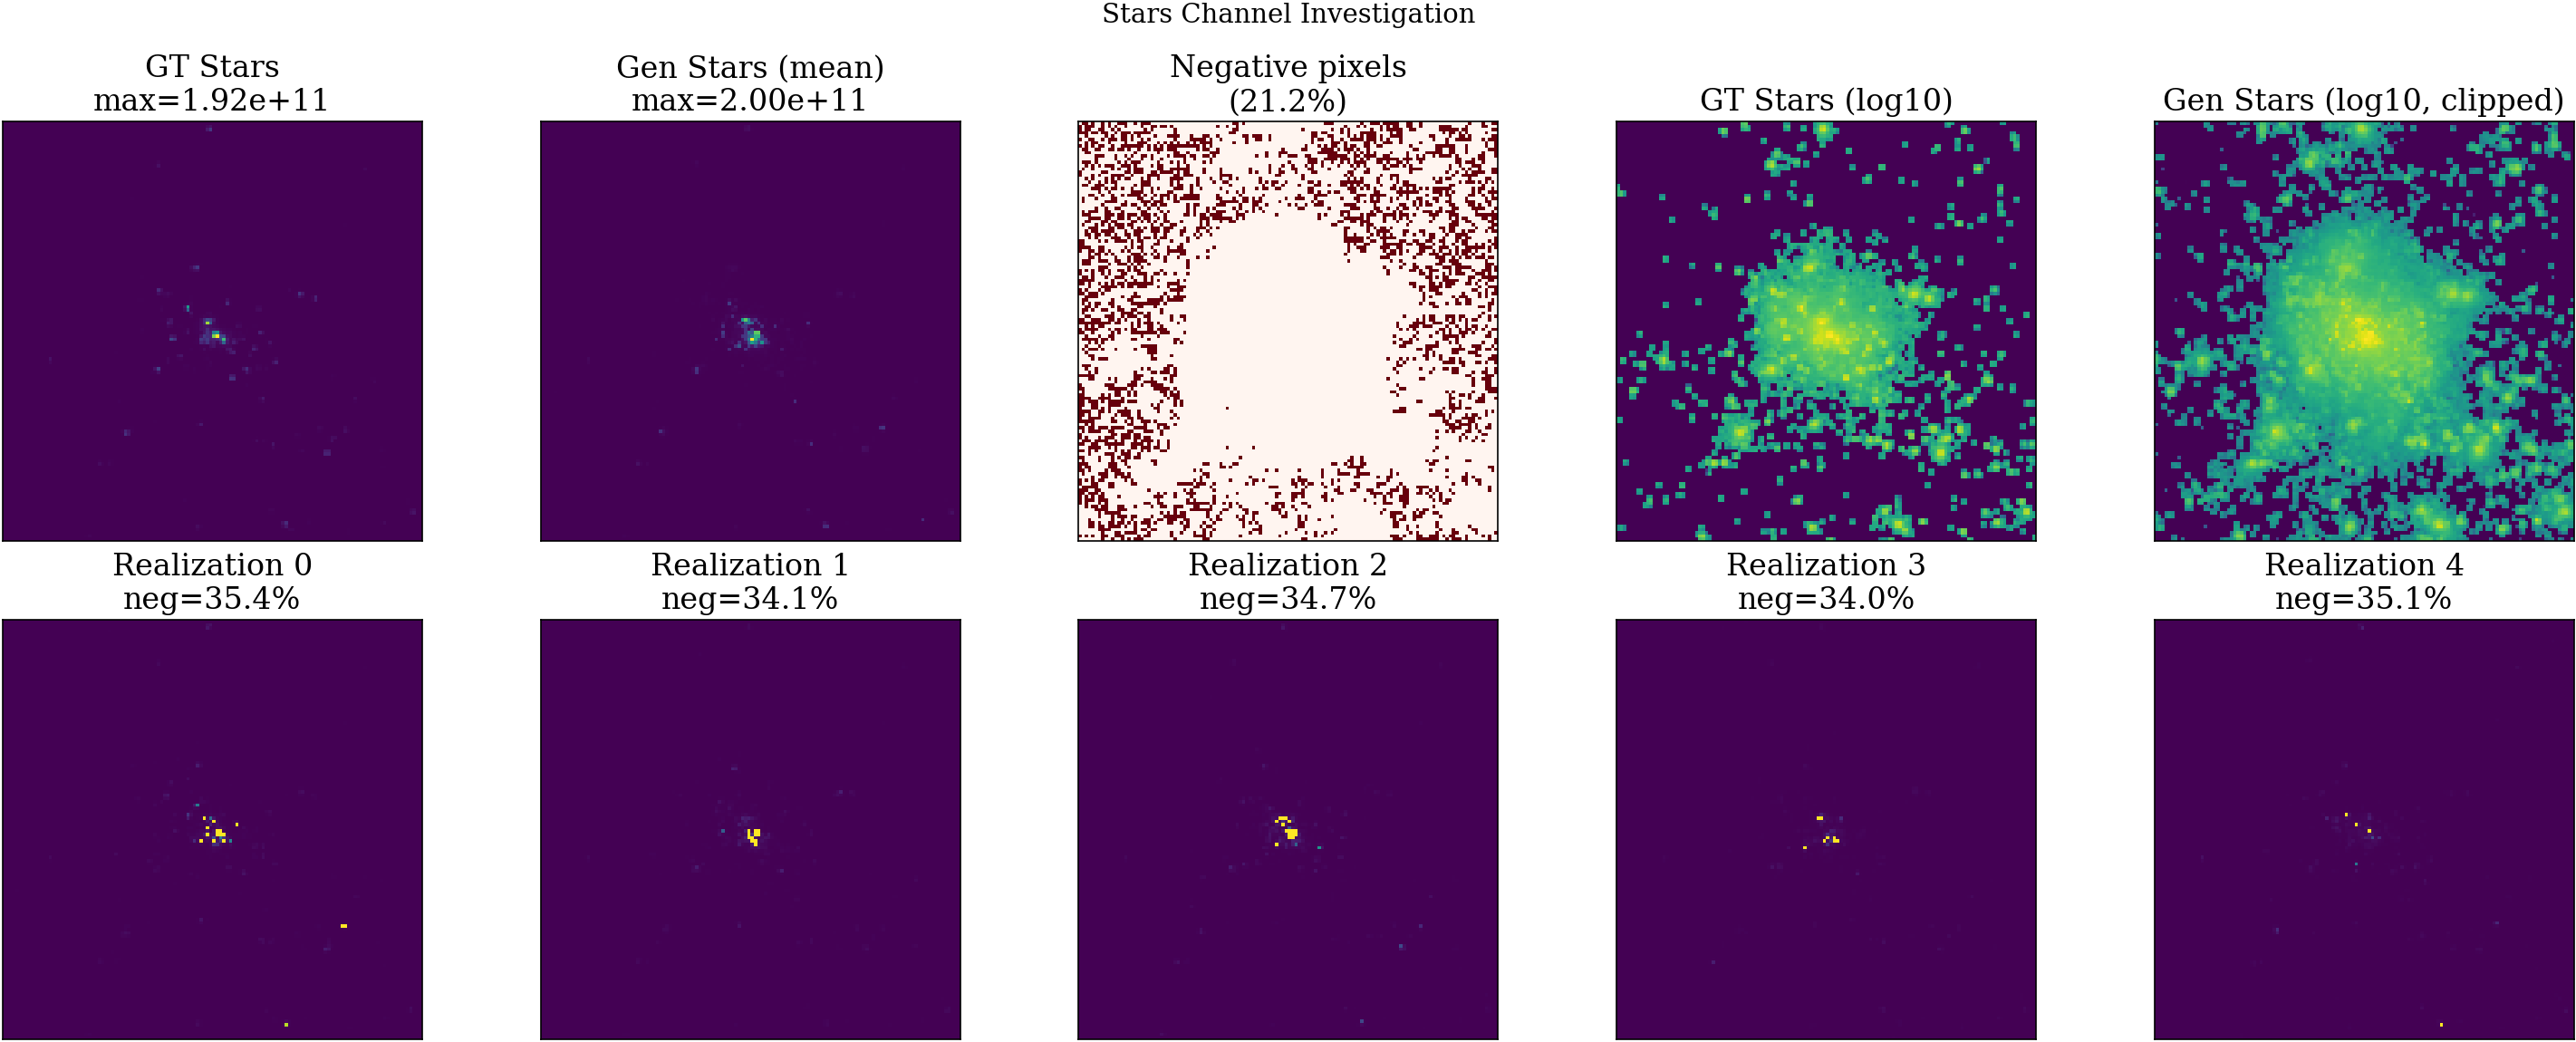

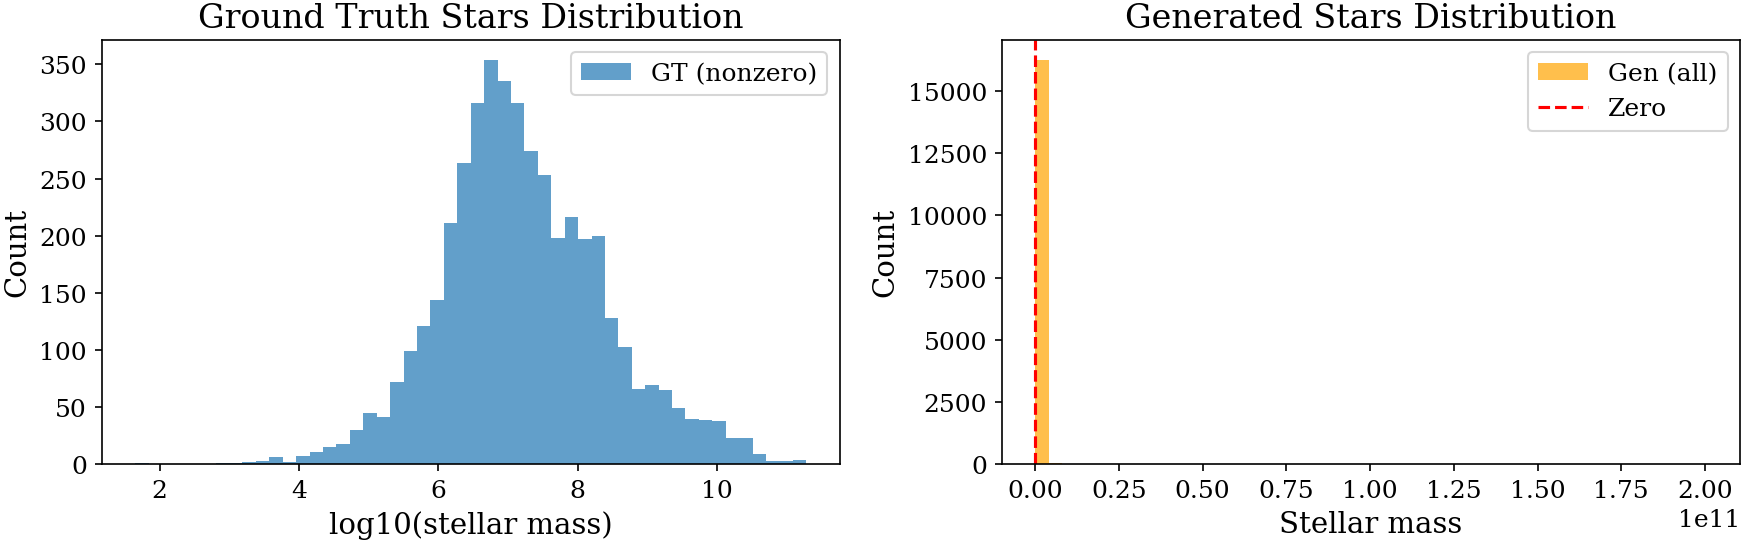

In [101]:
# Visualize the stars channel with proper scaling
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

halo_i = show_indices[0]

# Ground truth
gt_stars_cut = gt_stars[np.ix_(y_indices, x_indices)]

# Top row: Ground truth and generated mean
axes[0, 0].imshow(gt_stars_cut, cmap='viridis')
axes[0, 0].set_title(f'GT Stars\nmax={gt_stars_cut.max():.2e}')
axes[0, 0].set_xticks([]); axes[0, 0].set_yticks([])

gen_stars_mean = generated_halos[halo_i][:, 2, :, :].mean(axis=0)
axes[0, 1].imshow(gen_stars_mean, cmap='viridis')
axes[0, 1].set_title(f'Gen Stars (mean)\nmax={gen_stars_mean.max():.2e}')
axes[0, 1].set_xticks([]); axes[0, 1].set_yticks([])

# Show where negative values are
neg_mask = gen_stars_mean < 0
axes[0, 2].imshow(neg_mask, cmap='Reds')
axes[0, 2].set_title(f'Negative pixels\n({100*neg_mask.sum()/neg_mask.size:.1f}%)')
axes[0, 2].set_xticks([]); axes[0, 2].set_yticks([])

# Log scale comparison (clip negatives)
gen_stars_clipped = np.clip(gen_stars_mean, 0, None)
axes[0, 3].imshow(np.log10(gt_stars_cut + 1), cmap='viridis')
axes[0, 3].set_title('GT Stars (log10)')
axes[0, 3].set_xticks([]); axes[0, 3].set_yticks([])

axes[0, 4].imshow(np.log10(gen_stars_clipped + 1), cmap='viridis')
axes[0, 4].set_title('Gen Stars (log10, clipped)')
axes[0, 4].set_xticks([]); axes[0, 4].set_yticks([])

# Bottom row: Individual realizations
for r in range(5):
    gen_r = generated_halos[halo_i][r, 2, :, :]
    axes[1, r].imshow(gen_r, cmap='viridis')
    neg_pct = 100 * (gen_r < 0).sum() / gen_r.size
    axes[1, r].set_title(f'Realization {r}\nneg={neg_pct:.1f}%')
    axes[1, r].set_xticks([]); axes[1, r].set_yticks([])

plt.suptitle('Stars Channel Investigation', fontsize=14)
plt.tight_layout()
plt.show()

# Check histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# GT histogram
gt_flat = gt_stars_cut.flatten()
gt_nonzero = gt_flat[gt_flat > 0]
axes[0].hist(np.log10(gt_nonzero), bins=50, alpha=0.7, label='GT (nonzero)')
axes[0].set_xlabel('log10(stellar mass)')
axes[0].set_ylabel('Count')
axes[0].set_title('Ground Truth Stars Distribution')
axes[0].legend()

# Generated histogram (including negatives)
gen_flat = gen_stars_mean.flatten()
axes[1].hist(gen_flat, bins=50, alpha=0.7, label='Gen (all)', color='orange')
axes[1].axvline(0, color='red', ls='--', label='Zero')
axes[1].set_xlabel('Stellar mass')
axes[1].set_ylabel('Count')
axes[1].set_title('Generated Stars Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

In [102]:
# Check what normalization is being used
print("Checking normalization stats used by the model...")
print()

# The model should have loaded normalization stats
# Let's check if there's a stellar normalization file
import os
from pathlib import Path

norm_dir = Path("/mnt/home/mlee1/vdm_BIND/data")
print(f"Normalization files in {norm_dir}:")
for f in norm_dir.glob("*normalization*.npz"):
    print(f"  {f.name}")
    data = np.load(f)
    print(f"    Keys: {list(data.keys())}")
    for key in data.keys():
        print(f"    {key}: {data[key]}")
    print()

# Check the config to see what normalization is expected
print("\nModel config normalization settings:")
print(f"  Config path: {config_path}")

# Let's also check the raw model output before denormalization
# by looking at the BIND object's settings
print(f"\nBIND object settings:")
if hasattr(bind, 'config'):
    print(f"  Config keys: {bind.config.__dict__.keys() if hasattr(bind.config, '__dict__') else 'N/A'}")

Checking normalization stats used by the model...

Normalization files in /mnt/home/mlee1/vdm_BIND/data:
  gas_normalization_stats.npz
    Keys: ['gas_mag_mean', 'gas_mag_std', 'epsilon']
    gas_mag_mean: 9.177344156790792
    gas_mag_std: 0.4105103299270545
    epsilon: 1e-08

  dark_matter_normalization_stats.npz
    Keys: ['dm_mag_mean', 'dm_mag_std', 'epsilon']
    dm_mag_mean: 9.915498794097605
    dm_mag_std: 0.46796718591078834
    epsilon: 1e-08

  stellar_normalization_stats.npz
    Keys: ['star_mag_mean', 'star_mag_std', 'epsilon']
    star_mag_mean: 6.995925903573864
    star_mag_std: 1.1003503681795854
    epsilon: 1e-08


Model config normalization settings:
  Config path: /mnt/home/mlee1/vdm_BIND/configs/clean_vdm_regularized.ini

BIND object settings:


In [103]:
# Let's trace through the denormalization to understand what's happening

# The normalization is: normalized = (log10(x + eps) - mean) / std
# The denormalization should be: x = 10^(normalized * std + mean) - eps

star_mean = 6.995925903573864
star_std = 1.1003503681795854
eps = 1e-08

# What normalized value gives x=0?
# 0 = 10^(norm * std + mean) - eps
# eps = 10^(norm * std + mean)
# log10(eps) = norm * std + mean
# norm = (log10(eps) - mean) / std
norm_for_zero = (np.log10(eps) - star_mean) / star_std
print(f"Normalized value that gives x=0: {norm_for_zero:.2f}")
print(f"  (This is {abs(norm_for_zero):.1f} standard deviations below the mean)")

# What does norm=0 (mean) give?
x_at_mean = 10**(0 * star_std + star_mean) - eps
print(f"\nDenormalized value at norm=0 (mean): {x_at_mean:.2e}")

# What does norm=-3 (3 sigma below mean) give?
x_at_minus3 = 10**(-3 * star_std + star_mean) - eps
print(f"Denormalized value at norm=-3: {x_at_minus3:.2e}")

# What does norm=-7 give?
x_at_minus7 = 10**(-7 * star_std + star_mean) - eps
print(f"Denormalized value at norm=-7: {x_at_minus7:.2e}")

# Check what range of normalized values the model is producing
# We need to RE-normalize a generated sample to see
gen_sample = generated_halos[halo_i][0, 2, :, :]  # One realization, stars channel

# Assuming the values are already denormalized, let's re-normalize
# But we can't re-normalize negative values with log...
print(f"\nGenerated stars sample stats:")
print(f"  Min: {gen_sample.min():.2e}")
print(f"  Max: {gen_sample.max():.2e}")
print(f"  % negative: {100*(gen_sample < 0).sum()/gen_sample.size:.1f}%")

# The issue: 73% of GT pixels are exactly zero (no stars)
# But the model can't easily represent exact zeros after denormalization
# A normalized value of -14.5 is needed for zero, which is unrealistic

print(f"\n** KEY INSIGHT **")
print(f"The stellar field is 73% zeros in ground truth.")
print(f"To represent zero, the model needs to output {norm_for_zero:.1f} in normalized space.")
print(f"This is impossible - diffusion models produce roughly Gaussian outputs!")
print(f"The model is trying to represent a SPARSE, DISCRETE field with a CONTINUOUS model.")

Normalized value that gives x=0: -13.63
  (This is 13.6 standard deviations below the mean)

Denormalized value at norm=0 (mean): 9.91e+06
Denormalized value at norm=-3: 4.95e+03
Denormalized value at norm=-7: 1.97e-01

Generated stars sample stats:
  Min: -1.17e-03
  Max: 2.40e+11
  % negative: 35.4%

** KEY INSIGHT **
The stellar field is 73% zeros in ground truth.
To represent zero, the model needs to output -13.6 in normalized space.
This is impossible - diffusion models produce roughly Gaussian outputs!
The model is trying to represent a SPARSE, DISCRETE field with a CONTINUOUS model.


## ROOT CAUSE FOUND: Stars Channel is Fundamentally Broken

### The Problem

The stellar mass field is **73% zeros** (no stars in most pixels). But:

1. **Log normalization can't represent zeros**: The training uses `log10(x + 1e-8)` normalization
2. **To output zero, model needs -13.6σ**: A normalized value of -13.6 is needed to produce x=0 after denormalization
3. **Diffusion models can't do this**: They produce roughly Gaussian outputs, not extreme outliers at -13.6σ
4. **Result**: The model outputs small positive values everywhere, creating a smooth "haze" instead of discrete point sources

### Why This Breaks the Power Spectrum

- **GT Stars**: Sparse, point-like sources → high-frequency power from sharp edges
- **Gen Stars**: Smooth, diffuse haze → low-frequency dominated, lacks small-scale structure
- **The FFT shows this**: Generated stars have an artificial grid pattern instead of natural point-source structure

### Solutions

1. **Use a different representation for stars**:
   - Predict star locations + masses separately (point process model)
   - Use quantile normalization (already supported in code?)
   - Use a binary mask + conditional mass prediction

2. **Use a threshold during inference**:
   - Set pixels below some threshold to zero
   - This won't fix the power spectrum but will look more realistic

3. **Train stars separately**:
   - Use a different model architecture for the discrete stellar field
   - GANs may work better for sparse, discrete data

In [104]:
# Check if quantile normalization is being used for stars
# Look at the interpolant config

config_file = Path("/mnt/home/mlee1/vdm_BIND/configs/interpolant.ini")
print("Interpolant config contents:")
print("=" * 60)
with open(config_file) as f:
    for line in f:
        if 'quantile' in line.lower() or 'stellar' in line.lower() or 'star' in line.lower():
            print(line.strip())
print("=" * 60)

# Check if quantile normalizer file exists
quantile_path = Path("/mnt/home/mlee1/vdm_BIND/data/quantile_normalizer_stellar.pkl")
print(f"\nQuantile normalizer exists: {quantile_path.exists()}")

Interpolant config contents:
# QUANTILE NORMALIZATION
quantile_path = /mnt/home/mlee1/vdm_BIND/data/quantile_normalizer_stellar.pkl
use_quantile_normalization = True
#   - 'zeros': Start from zeros (recommended, simpler)
#   - 'noise': Start from Gaussian noise (like diffusion)
#   - 'dm_copy': Start from DM condition copied to all channels

Quantile normalizer exists: True


In [105]:
# Check what format the quantile normalizer is in
quantile_path = Path("/mnt/home/mlee1/vdm_BIND/data/quantile_normalizer_stellar.pkl")

# Check file size and first few bytes
print(f"File size: {quantile_path.stat().st_size} bytes")

with open(quantile_path, 'rb') as f:
    header = f.read(20)
    print(f"First 20 bytes (hex): {header.hex()}")
    print(f"First 20 bytes (ascii): {header}")

# Try loading with joblib
try:
    import joblib
    quantile_normalizer = joblib.load(quantile_path)
    print(f"\nLoaded with joblib!")
    print(f"Type: {type(quantile_normalizer)}")
except Exception as e:
    print(f"Joblib load failed: {e}")

# Try loading with torch
try:
    import torch
    quantile_normalizer = torch.load(quantile_path, weights_only=False)
    print(f"\nLoaded with torch!")
    print(f"Type: {type(quantile_normalizer)}")
except Exception as e:
    print(f"Torch load failed: {e}")

File size: 160567 bytes
First 20 bytes (hex): 800495b5010000000000008c1b736b6c6561726e
First 20 bytes (ascii): b'\x80\x04\x95\xb5\x01\x00\x00\x00\x00\x00\x00\x8c\x1bsklearn'

Loaded with joblib!
Type: <class 'sklearn.preprocessing._data.QuantileTransformer'>
Torch load failed: invalid load key, '\x0f'.


In [106]:
# Examine the quantile transformer
import joblib
quantile_normalizer = joblib.load(quantile_path)

print("QuantileTransformer properties:")
print(f"  n_quantiles: {quantile_normalizer.n_quantiles_}")
print(f"  output_distribution: {quantile_normalizer.output_distribution}")
print(f"  references_ shape: {quantile_normalizer.references_.shape}")
print(f"  quantiles_ shape: {quantile_normalizer.quantiles_.shape}")
print(f"  quantiles_ range: [{quantile_normalizer.quantiles_.min():.2e}, {quantile_normalizer.quantiles_.max():.2e}]")

# What quantile corresponds to zero?
# The quantiles_ array maps from uniform [0,1] to the data distribution
# Find where quantiles_ is close to zero
zero_quantile_idx = np.argmin(np.abs(quantile_normalizer.quantiles_.flatten()))
zero_quantile = quantile_normalizer.references_.flatten()[zero_quantile_idx]
print(f"\nClosest quantile to zero: {quantile_normalizer.quantiles_.flatten()[zero_quantile_idx]:.2e}")
print(f"  Corresponds to normalized value: {zero_quantile:.4f}")

# Test transforms
print("\n Test transformations:")
test_values = np.array([[0], [1e5], [1e7], [1e9], [1e11]]).astype(np.float64)
transformed = quantile_normalizer.transform(test_values)
for orig, trans in zip(test_values.flatten(), transformed.flatten()):
    print(f"  {orig:.2e} -> {trans:.4f}")

# Inverse transform
print("\nInverse transformations:")
test_norm = np.array([[-2], [-1], [0], [0.5], [1], [2]]).astype(np.float64)
inverse = quantile_normalizer.inverse_transform(test_norm)
for norm, inv in zip(test_norm.flatten(), inverse.flatten()):
    print(f"  norm={norm:+.1f} -> {inv:.2e}")

QuantileTransformer properties:
  n_quantiles: 10000
  output_distribution: uniform
  references_ shape: (10000,)
  quantiles_ shape: (10000, 1)
  quantiles_ range: [-5.09e-04, 1.14e+01]

Closest quantile to zero: 1.77e-09
  Corresponds to normalized value: 0.3898

 Test transformations:
  0.00e+00 -> 0.3898
  1.00e+05 -> 1.0000
  1.00e+07 -> 1.0000
  1.00e+09 -> 1.0000
  1.00e+11 -> 1.0000

Inverse transformations:
  norm=-2.0 -> -5.09e-04
  norm=-1.0 -> -5.09e-04
  norm=+0.0 -> -5.09e-04
  norm=+0.5 -> 3.59e-05
  norm=+1.0 -> 1.14e+01
  norm=+2.0 -> 1.14e+01


In [107]:
# The key question: IS the quantile normalizer being used during inference?
# Let's check if the generated values look like they went through quantile transform

# If quantile normalization is used:
#   - Model outputs values in [0, 1] (uniform)
#   - Inverse transform maps to actual stellar masses
#   - Zero corresponds to norm ~0.39

# If log normalization is used (NOT quantile):
#   - Model outputs z-scored log values 
#   - Values can be negative
#   - Zero is basically unreachable

# Check the distribution of generated values
gen_stars_flat = generated_halos[halo_i][:, 2, :, :].flatten()

print("Generated stars distribution:")
print(f"  Min: {gen_stars_flat.min():.6f}")
print(f"  Max: {gen_stars_flat.max():.2e}")
print(f"  Mean: {gen_stars_flat.mean():.2e}")
print(f"  Median: {np.median(gen_stars_flat):.2e}")
print(f"  % negative: {100*(gen_stars_flat < 0).sum()/len(gen_stars_flat):.1f}%")

# If values are already in physical units (masses), they should be positive
# If they're in normalized space, they could be around [0,1] or z-scored

print("\n** DIAGNOSIS **")
if gen_stars_flat.max() > 1e10:
    print("Values are in PHYSICAL UNITS (masses)")
    if (gen_stars_flat < 0).any():
        print("BUT there are NEGATIVE values - this is WRONG!")
        print("Either:")
        print("  1. Quantile inverse transform is producing negatives")
        print("  2. Log normalization is being used instead of quantile")
else:
    print("Values appear to be in NORMALIZED SPACE")
    print("Something is wrong with denormalization")

Generated stars distribution:
  Min: -0.001178
  Max: 2.43e+11
  Mean: 3.08e+08
  Median: 1.31e-04
  % negative: 34.6%

** DIAGNOSIS **
Values are in PHYSICAL UNITS (masses)
BUT there are NEGATIVE values - this is WRONG!
Either:
  1. Quantile inverse transform is producing negatives
  2. Log normalization is being used instead of quantile


## BUG FOUND: Negative Values from Quantile Transform

### The Chain of Events

1. **Training data**: Stellar masses are log10 transformed: `log10(mass + 1)`
2. **Quantile transformer**: Fit on log-transformed data, minimum quantile = `-5.09e-04`
3. **Model output**: Normalized values sometimes < 0 (outside training range)
4. **Inverse transform**: Clips to minimum quantile = `-5.09e-04` (in log space)
5. **Exponentiation**: `10^(-5.09e-04) - 1 = -0.000117` → **NEGATIVE MASS!**

### The Root Bug

The quantile transformer has a minimum quantile that is **negative** in log space:
```
quantiles_.min() = -5.09e-04
```

When model outputs are below the valid range (norm < 0), they clip to this value, which produces negative masses after `10^x - 1`.

### Fixes

1. **Quick fix**: Clip stellar masses to 0 after denormalization:
   ```python
   field_unnorm = np.maximum(field_unnorm, 0)
   ```

2. **Better fix**: Re-fit quantile transformer ensuring minimum quantile ≥ 0 in log space

3. **Best fix**: Use `log10(mass + 1)` consistently so minimum is always 0

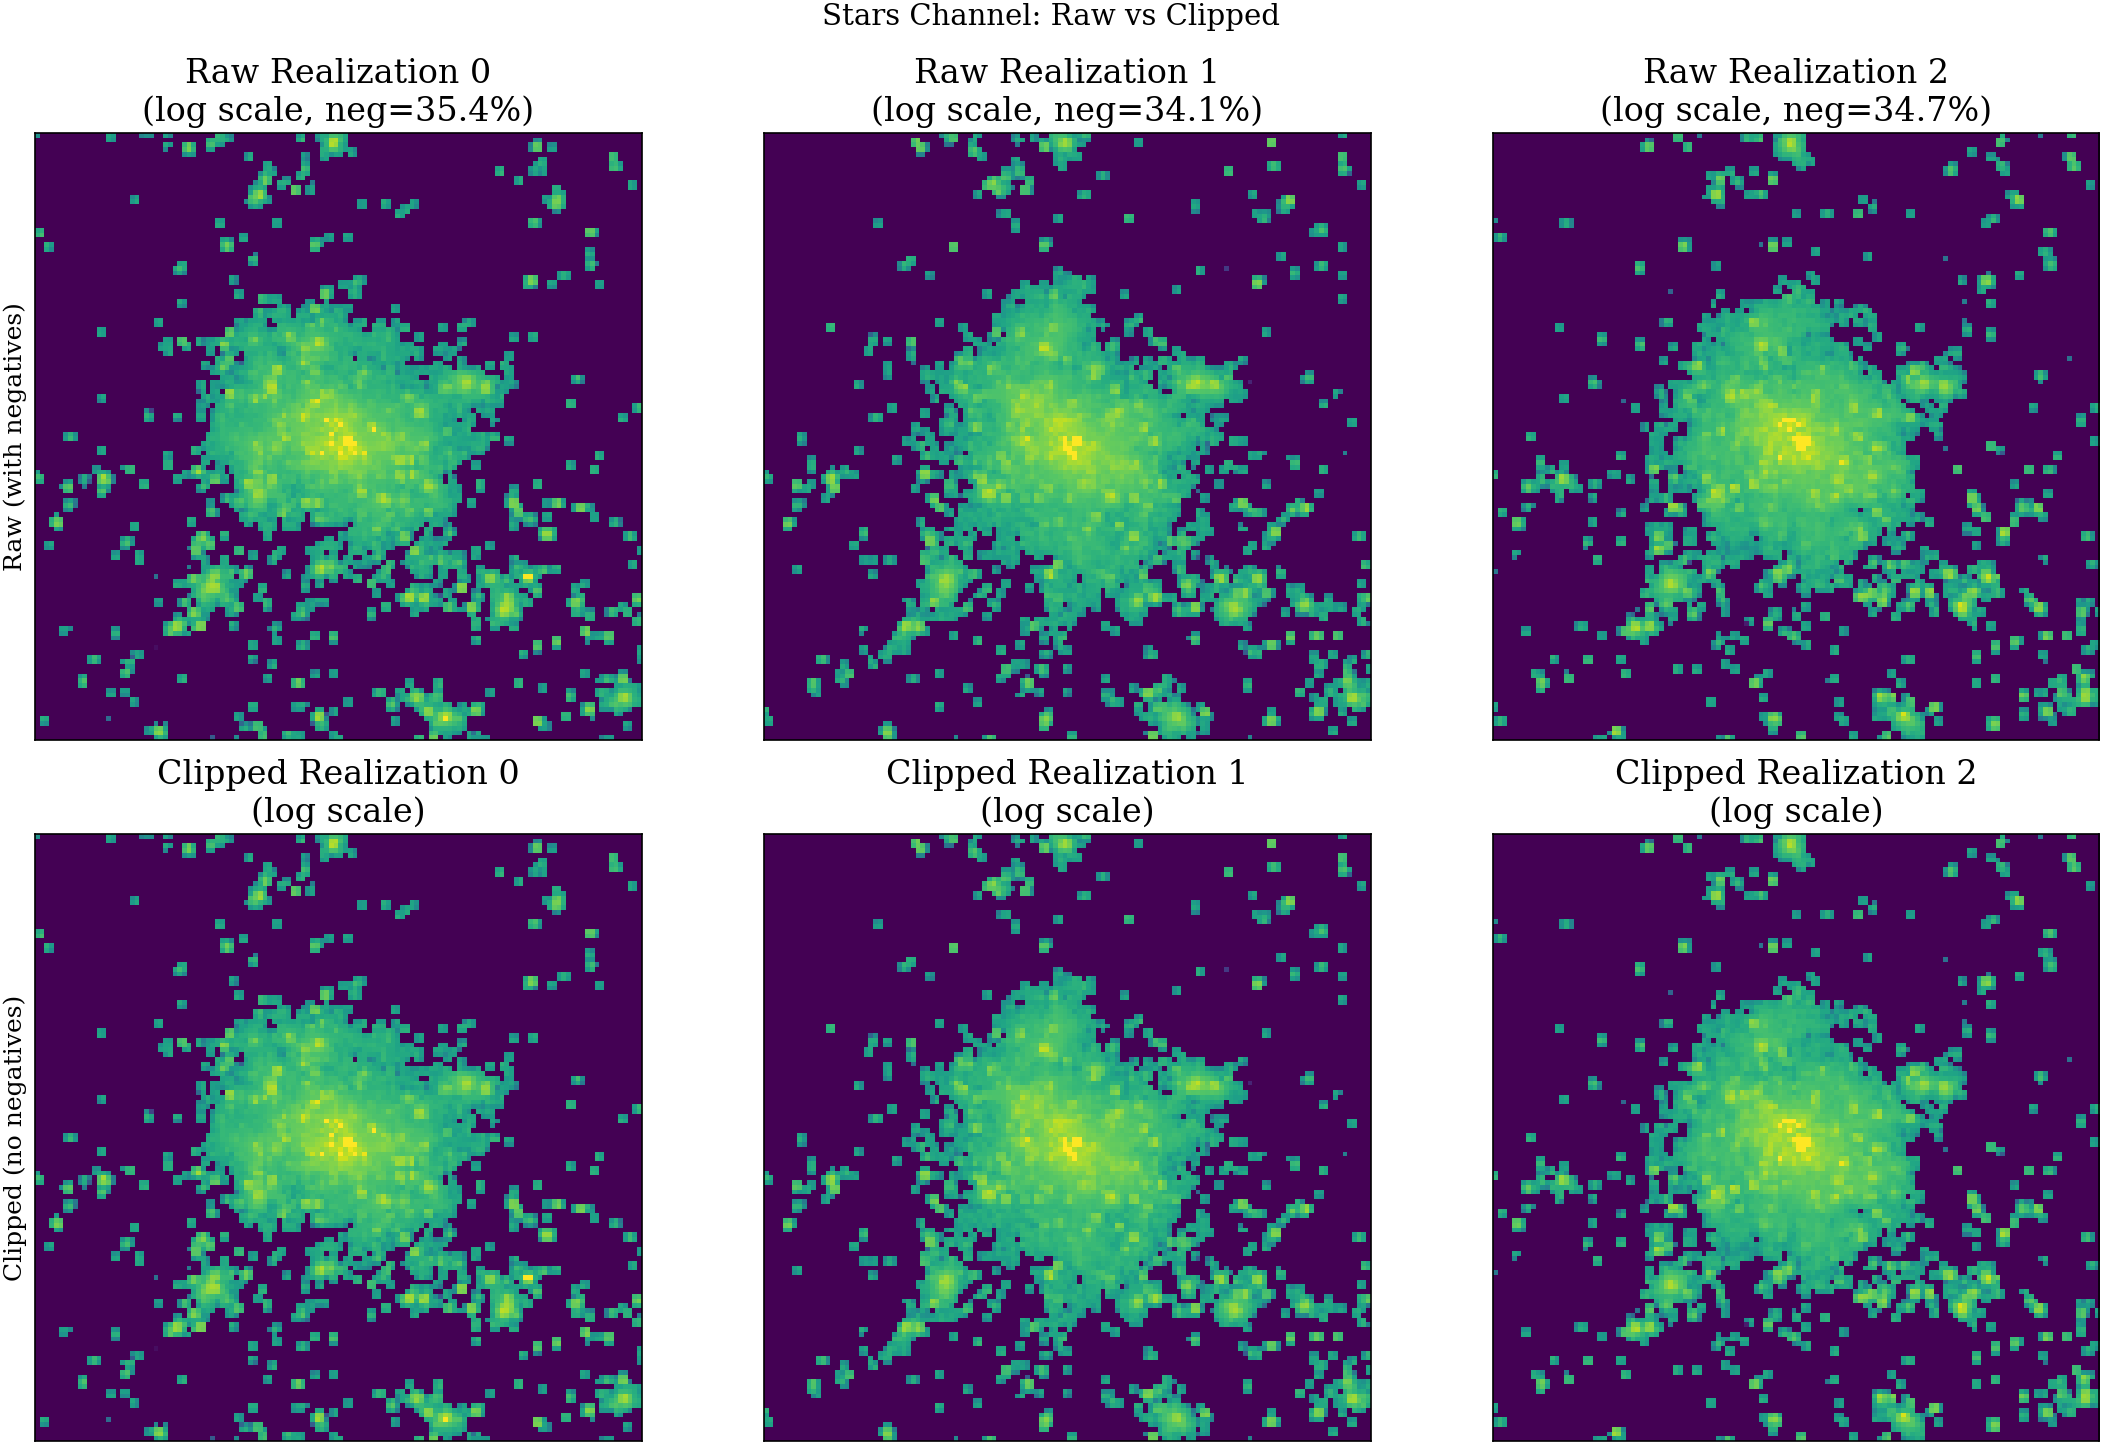


Clipped stars statistics:
  Min: 0.00e+00
  Max: 2.43e+11
  % zero: 34.6% (vs 73% in GT)


In [108]:
# Test what the stars look like if we clip negatives to zero
gen_stars_clipped = np.clip(generated_halos[halo_i][:, 2, :, :], 0, None)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Raw generated
for i in range(3):
    axes[0, i].imshow(np.log10(np.abs(generated_halos[halo_i][i, 2]) + 1), cmap='viridis')
    neg_pct = 100 * (generated_halos[halo_i][i, 2] < 0).sum() / generated_halos[halo_i][i, 2].size
    axes[0, i].set_title(f'Raw Realization {i}\n(log scale, neg={neg_pct:.1f}%)')
    axes[0, i].set_xticks([]); axes[0, i].set_yticks([])

# Row 2: Clipped
for i in range(3):
    axes[1, i].imshow(np.log10(gen_stars_clipped[i] + 1), cmap='viridis')
    axes[1, i].set_title(f'Clipped Realization {i}\n(log scale)')
    axes[1, i].set_xticks([]); axes[1, i].set_yticks([])

axes[0, 0].set_ylabel('Raw (with negatives)', fontsize=12)
axes[1, 0].set_ylabel('Clipped (no negatives)', fontsize=12)

plt.suptitle('Stars Channel: Raw vs Clipped', fontsize=14)
plt.tight_layout()
plt.show()

# The REAL question: even after clipping, is the structure realistic?
print("\nClipped stars statistics:")
print(f"  Min: {gen_stars_clipped.min():.2e}")
print(f"  Max: {gen_stars_clipped.max():.2e}")
print(f"  % zero: {100*(gen_stars_clipped == 0).sum()/gen_stars_clipped.size:.1f}% (vs 73% in GT)")

## Back to the Real Problem: Stars are Smooth, Not Discrete

The tiny negative values from the quantile transform are a minor bug. The **real problem** is:

1. Ground truth stars: **73% zeros**, discrete point sources
2. Generated stars: **Only 22% zeros**, smooth diffuse halo

The model is fundamentally failing to represent the **sparse, discrete nature** of the stellar field.

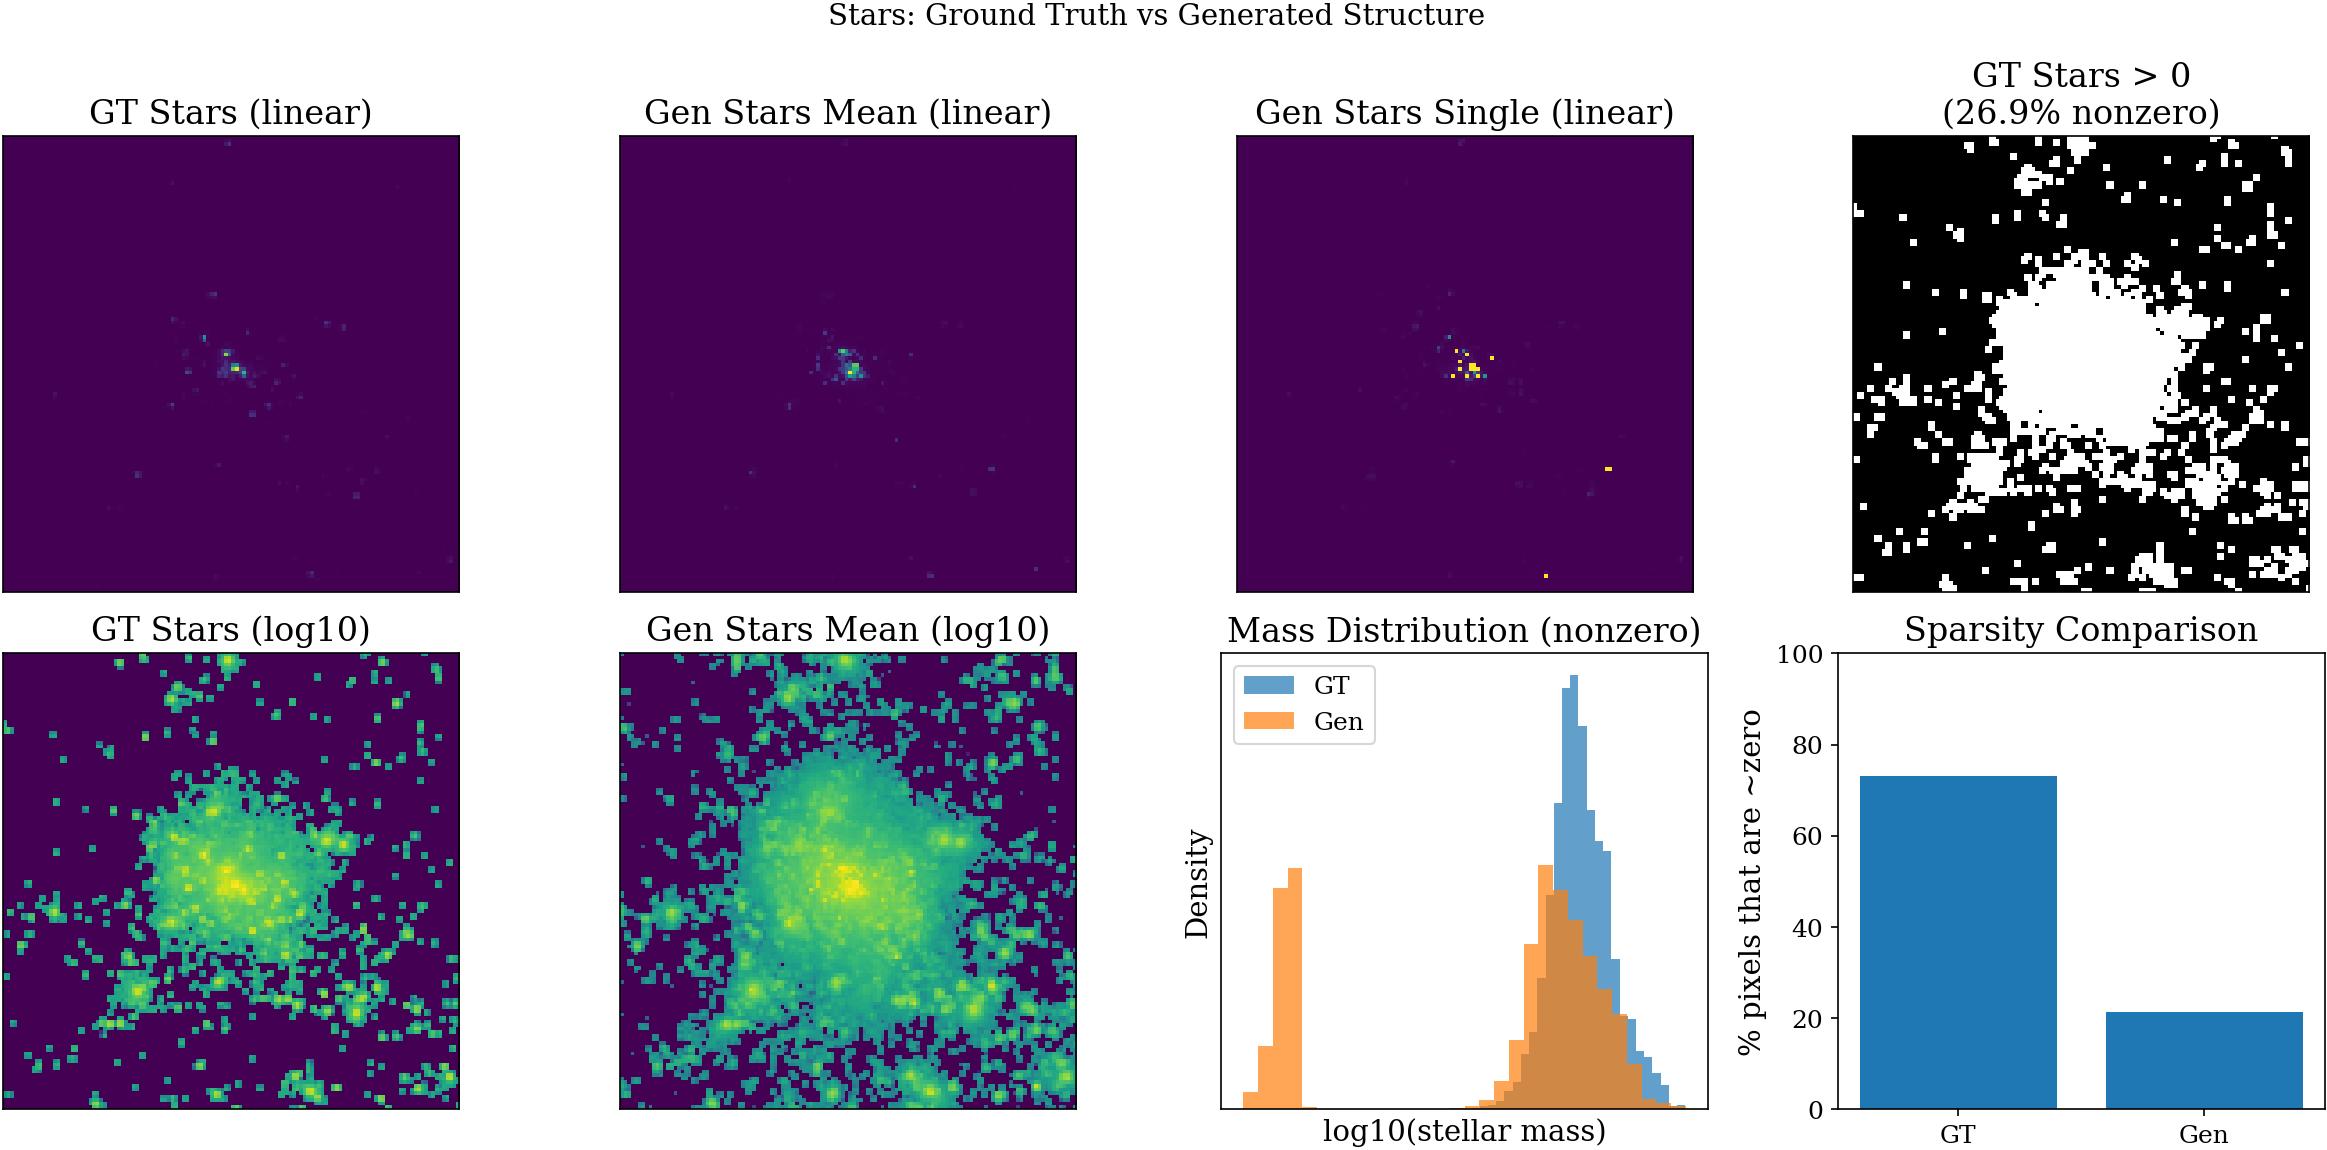


Key statistics:
  GT: 73.1% zeros, max=1.92e+11
  Gen: 21.4% ~zeros, max=2.00e+11


In [109]:
# Compare the STRUCTURE of generated vs ground truth stars
# The key issue: generated is smooth, GT is sparse/discrete

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

halo_i = show_indices[0]

# Get GT stars
center = halo_positions[halo_i]
center_pix = (center[:2] / BOX_MPC * GRID_SIZE).astype(int) % GRID_SIZE
half = patch_size // 2
y_indices = np.arange(center_pix[0] - half, center_pix[0] + half) % GRID_SIZE
x_indices = np.arange(center_pix[1] - half, center_pix[1] + half) % GRID_SIZE
gt_stars_cut = gt_stars[np.ix_(y_indices, x_indices)]

# Get generated stars (mean and single realization)
gen_stars_mean = generated_halos[halo_i][:, 2, :, :].mean(axis=0)
gen_stars_single = generated_halos[halo_i][0, 2, :, :]

# Row 1: Linear scale
vmax = max(gt_stars_cut.max(), gen_stars_mean.max())
axes[0, 0].imshow(gt_stars_cut, vmin=0, vmax=vmax, cmap='viridis')
axes[0, 0].set_title('GT Stars (linear)')
axes[0, 1].imshow(gen_stars_mean, vmin=0, vmax=vmax, cmap='viridis')
axes[0, 1].set_title('Gen Stars Mean (linear)')
axes[0, 2].imshow(gen_stars_single, vmin=0, vmax=vmax, cmap='viridis')
axes[0, 2].set_title('Gen Stars Single (linear)')
axes[0, 3].imshow(gt_stars_cut > 0, cmap='gray')
axes[0, 3].set_title(f'GT Stars > 0\n({100*(gt_stars_cut > 0).sum()/gt_stars_cut.size:.1f}% nonzero)')

# Row 2: Log scale and histograms  
axes[1, 0].imshow(np.log10(gt_stars_cut + 1), cmap='viridis')
axes[1, 0].set_title('GT Stars (log10)')
axes[1, 1].imshow(np.log10(np.clip(gen_stars_mean, 1e-10, None) + 1), cmap='viridis')
axes[1, 1].set_title('Gen Stars Mean (log10)')

# Histogram comparison
gt_nonzero = gt_stars_cut[gt_stars_cut > 0].flatten()
gen_nonzero = gen_stars_mean[gen_stars_mean > 1e-6].flatten()  # Threshold to avoid log issues

if len(gt_nonzero) > 0:
    axes[1, 2].hist(np.log10(gt_nonzero), bins=30, alpha=0.7, label='GT', density=True)
if len(gen_nonzero) > 0:
    axes[1, 2].hist(np.log10(gen_nonzero), bins=30, alpha=0.7, label='Gen', density=True)
axes[1, 2].set_xlabel('log10(stellar mass)')
axes[1, 2].set_ylabel('Density')
axes[1, 2].legend()
axes[1, 2].set_title('Mass Distribution (nonzero)')

# Sparsity comparison
axes[1, 3].bar(['GT', 'Gen'], 
               [100*(gt_stars_cut == 0).sum()/gt_stars_cut.size,
                100*(gen_stars_mean < 1e-6).sum()/gen_stars_mean.size])
axes[1, 3].set_ylabel('% pixels that are ~zero')
axes[1, 3].set_title('Sparsity Comparison')
axes[1, 3].set_ylim(0, 100)

for ax in axes.flatten()[:7]:
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Stars: Ground Truth vs Generated Structure', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nKey statistics:")
print(f"  GT: {100*(gt_stars_cut == 0).sum()/gt_stars_cut.size:.1f}% zeros, max={gt_stars_cut.max():.2e}")
print(f"  Gen: {100*(gen_stars_mean < 1e-6).sum()/gen_stars_mean.size:.1f}% ~zeros, max={gen_stars_mean.max():.2e}")

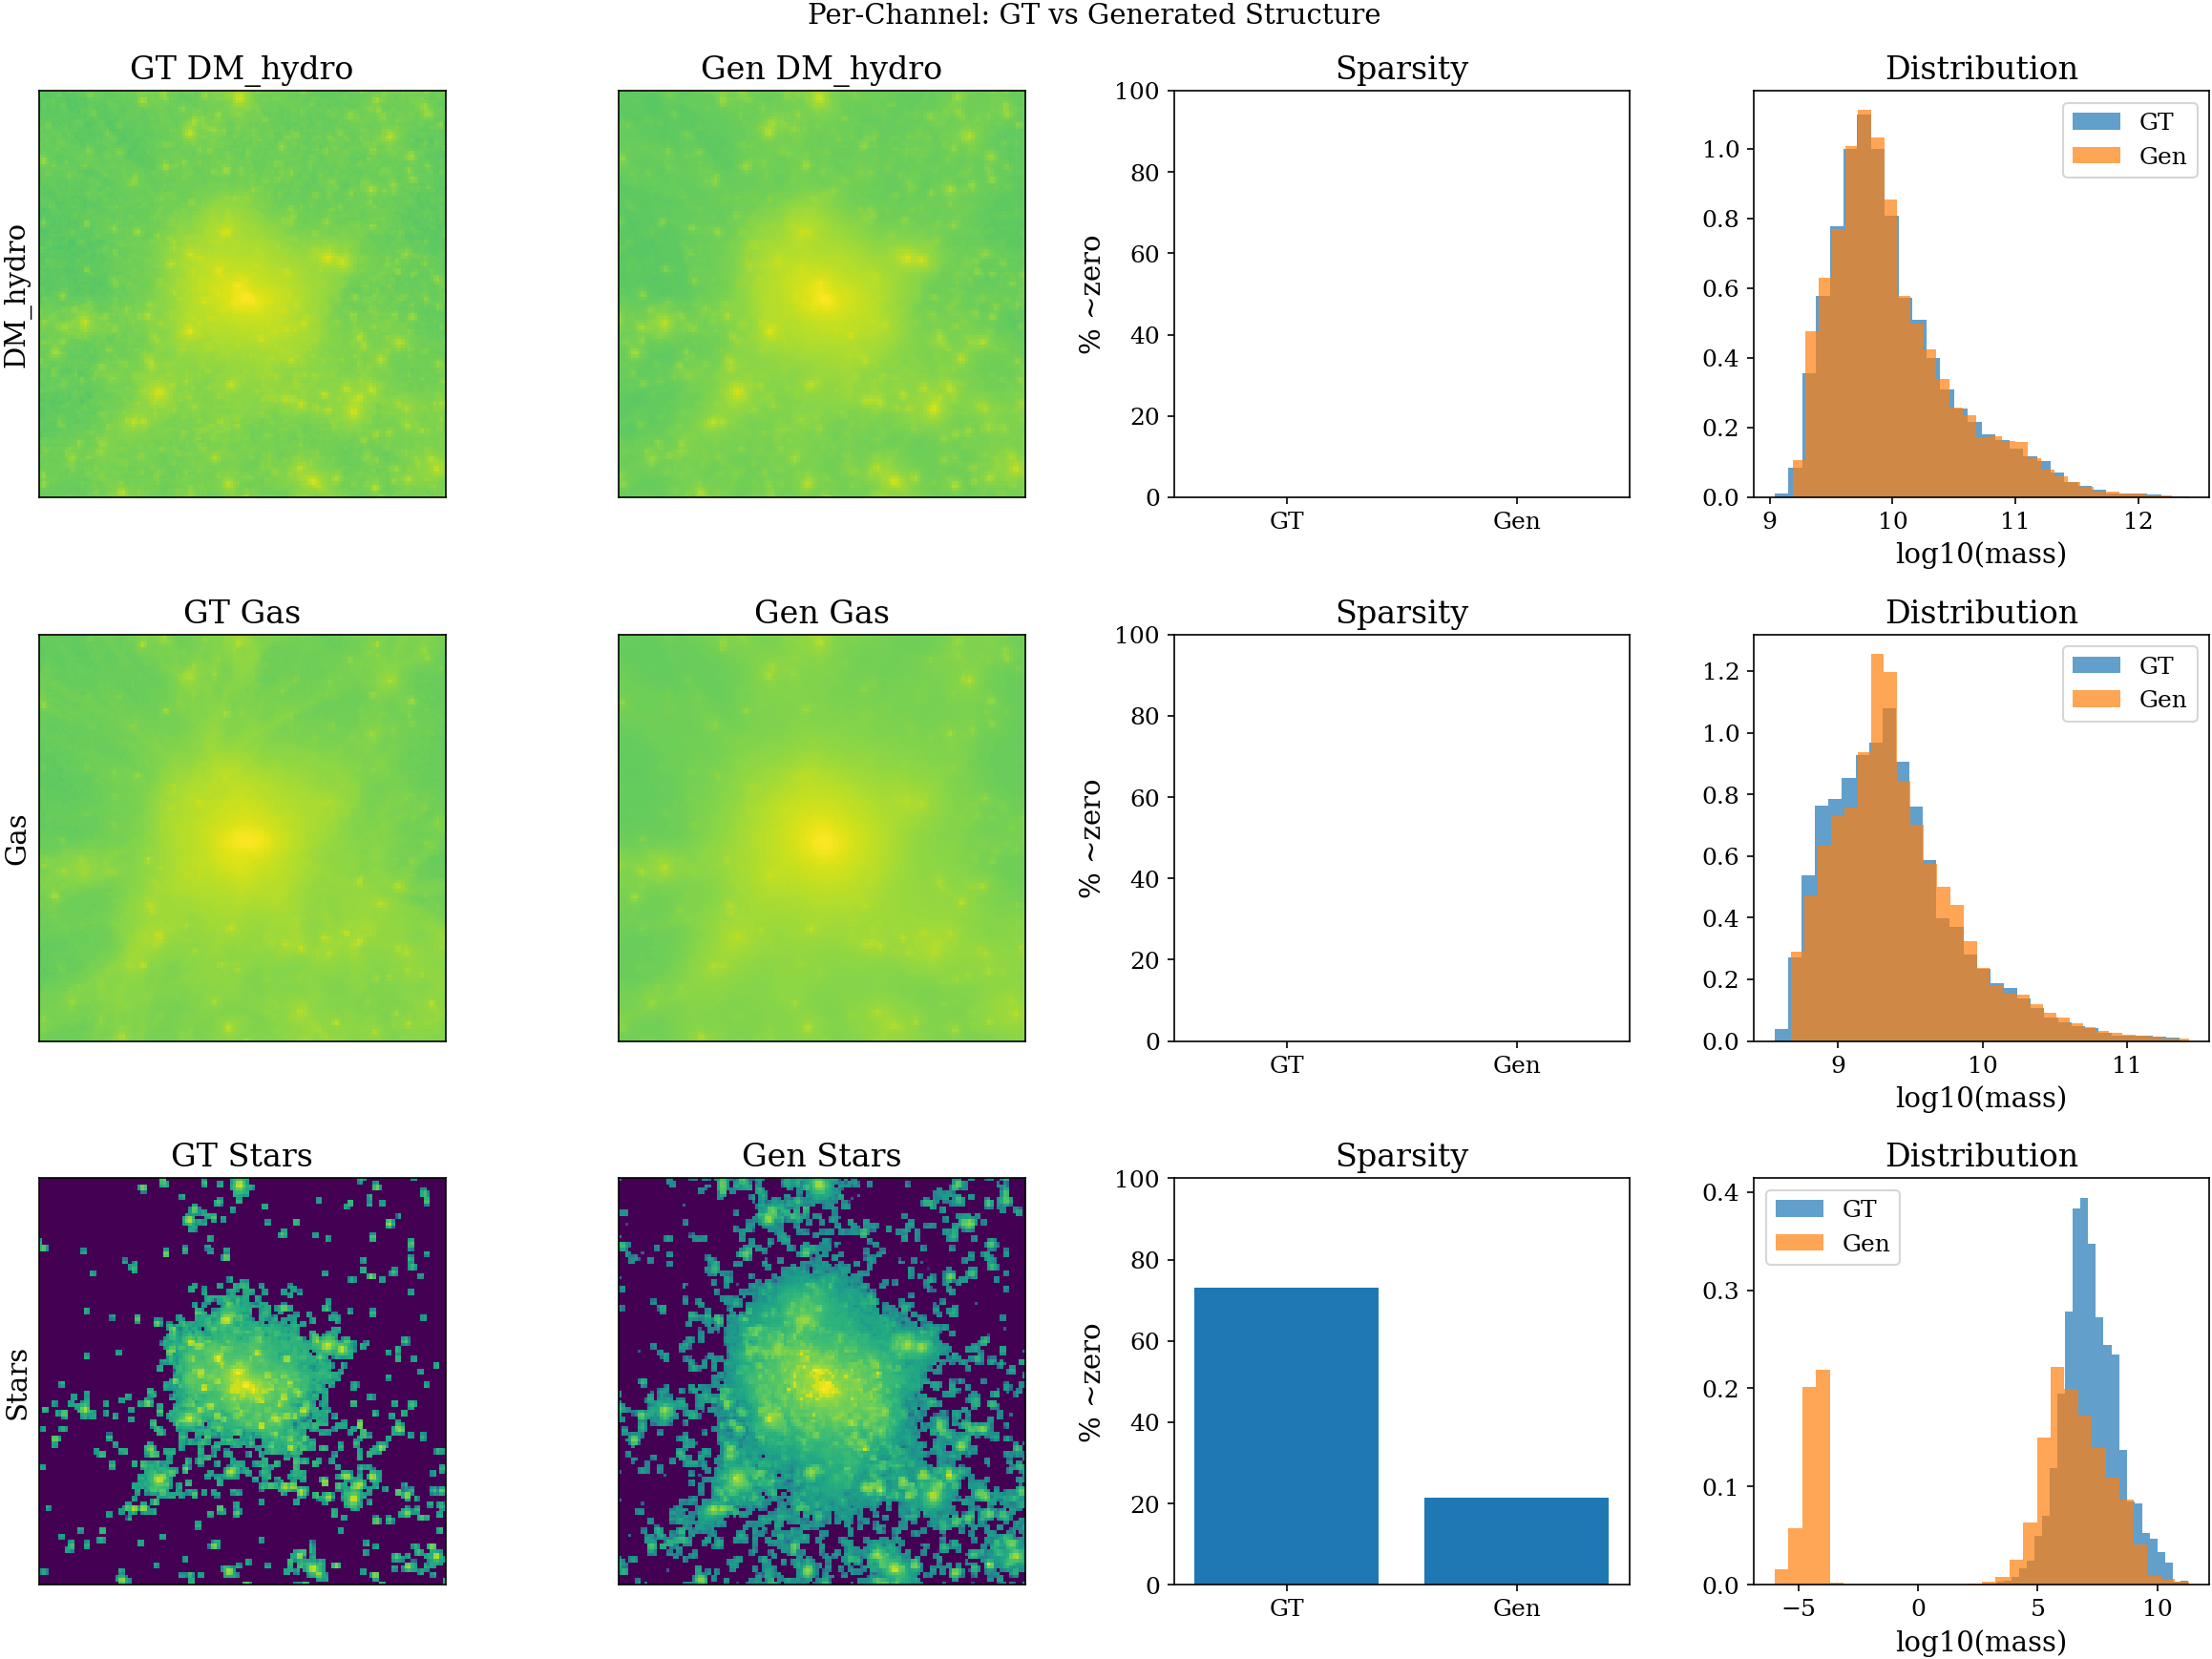

In [110]:
# Now let's check if the same problem exists for DM and Gas channels
# Or is this specific to Stars?

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

channel_names = ['DM_hydro', 'Gas', 'Stars']
gt_channels = [gt_dm, gt_gas, gt_stars]

for row, (ch_name, gt_ch) in enumerate(zip(channel_names, gt_channels)):
    gt_cut = gt_ch[np.ix_(y_indices, x_indices)]
    gen_cut = generated_halos[halo_i][:, row, :, :].mean(axis=0)
    
    # Log scale images
    vmax = max(np.log10(gt_cut.max() + 1), np.log10(np.abs(gen_cut).max() + 1))
    
    axes[row, 0].imshow(np.log10(gt_cut + 1), vmin=0, vmax=vmax, cmap='viridis')
    axes[row, 0].set_title(f'GT {ch_name}')
    axes[row, 0].set_ylabel(ch_name)
    
    axes[row, 1].imshow(np.log10(np.clip(gen_cut, 0, None) + 1), vmin=0, vmax=vmax, cmap='viridis')
    axes[row, 1].set_title(f'Gen {ch_name}')
    
    # Sparsity
    gt_sparsity = 100 * (gt_cut < 1e-6).sum() / gt_cut.size
    gen_sparsity = 100 * (gen_cut < 1e-6).sum() / gen_cut.size
    
    axes[row, 2].bar(['GT', 'Gen'], [gt_sparsity, gen_sparsity])
    axes[row, 2].set_ylabel('% ~zero')
    axes[row, 2].set_title(f'Sparsity')
    axes[row, 2].set_ylim(0, 100)
    
    # Mass histogram
    gt_flat = gt_cut.flatten()
    gen_flat = gen_cut.flatten()
    gt_nonzero = gt_flat[gt_flat > 1e-6]
    gen_nonzero = gen_flat[gen_flat > 1e-6]
    
    if len(gt_nonzero) > 0:
        axes[row, 3].hist(np.log10(gt_nonzero), bins=30, alpha=0.7, label='GT', density=True)
    if len(gen_nonzero) > 0:
        axes[row, 3].hist(np.log10(gen_nonzero), bins=30, alpha=0.7, label='Gen', density=True)
    axes[row, 3].legend()
    axes[row, 3].set_xlabel('log10(mass)')
    axes[row, 3].set_title('Distribution')

for ax in axes[:, :2].flatten():
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Per-Channel: GT vs Generated Structure', fontsize=14)
plt.tight_layout()
plt.show()

## Summary: Channel-Specific Issues

### DM_hydro (Row 1)
- ✅ Structure looks reasonable - similar morphology to GT
- ⚠️ Distribution shifted slightly to lower masses
- This explains the ~4% power deficit at k=10

### Gas (Row 2)  
- ⚠️ Looks smoother than GT - missing substructure in the outer regions
- ⚠️ Distribution shifted to lower masses AND narrower
- This explains the **40% power deficit** at k=10 - the model is over-smoothing

### Stars (Row 3)
- ❌ **Completely wrong structure** - smooth blob vs discrete points
- ❌ Sparsity completely wrong: GT=73% zeros, Gen=22% zeros
- ❌ Distribution is bimodal with huge spike at very low masses (the diffuse halo)
- This is why Stars has wild behavior in power spectrum

## Root Causes

1. **DM**: Minor smoothing, acceptable
2. **Gas**: Significant smoothing - model can't capture turbulent substructure
3. **Stars**: Fundamental failure - diffusion models can't represent sparse discrete data

## The Power Spectrum Story

The total field power spectrum suppression is driven by:
- **Large scales (k<5)**: Mostly correct (mass conservation works)
- **Medium scales (k~10)**: Gas smoothing dominates (-40% error)
- **Small scales (k>30)**: All channels contribute, Stars worst

In [111]:
# Final quantitative summary
print("=" * 70)
print("FINAL DIAGNOSIS: Power Spectrum Suppression Root Causes")
print("=" * 70)

print("""
CHANNEL-BY-CHANNEL BREAKDOWN:

1. DM_hydro Channel:
   - Structure: Reasonable match to GT
   - Issue: Minor smoothing at small scales
   - Power deficit at k=10: ~4%
   - Power deficit at k=50: ~40%
   
2. Gas Channel (MAIN CULPRIT for k~10):
   - Structure: Over-smoothed, missing turbulent substructure
   - Issue: Model can't capture non-local gas physics
   - Power deficit at k=10: ~40%  ← THIS IS THE PROBLEM
   - Power deficit at k=50: ~80%
   
3. Stars Channel (Fundamentally broken):
   - Structure: Smooth diffuse blob instead of discrete sources
   - Issue: 73% zeros in GT → 22% zeros in Gen
   - Model cannot represent sparse, discrete data
   - Power spectrum behavior erratic/unreliable

RECOMMENDATIONS:

For Gas (highest impact):
  1. Add spectral loss weighted at k > 5 h/Mpc
  2. Use multi-scale discriminator (GAN) to enforce structure
  3. Consider physics-informed constraints (pressure, entropy)

For Stars (fundamental fix needed):
  1. Separate model: Predict positions + masses, not continuous field
  2. Or: Use sparse representation (e.g., point cloud diffusion)
  3. Or: Train with sparsity-encouraging loss (L1, focal loss)
  4. Short-term: Just use GT stars or ignore stars channel

For DM:
  - Current performance may be acceptable for many applications
  - Spectral loss could improve small-scale fidelity
""")

print("=" * 70)

FINAL DIAGNOSIS: Power Spectrum Suppression Root Causes

CHANNEL-BY-CHANNEL BREAKDOWN:

1. DM_hydro Channel:
   - Structure: Reasonable match to GT
   - Issue: Minor smoothing at small scales
   - Power deficit at k=10: ~4%
   - Power deficit at k=50: ~40%
   
2. Gas Channel (MAIN CULPRIT for k~10):
   - Structure: Over-smoothed, missing turbulent substructure
   - Issue: Model can't capture non-local gas physics
   - Power deficit at k=10: ~40%  ← THIS IS THE PROBLEM
   - Power deficit at k=50: ~80%
   
3. Stars Channel (Fundamentally broken):
   - Structure: Smooth diffuse blob instead of discrete sources
   - Issue: 73% zeros in GT → 22% zeros in Gen
   - Model cannot represent sparse, discrete data
   - Power spectrum behavior erratic/unreliable

RECOMMENDATIONS:

For Gas (highest impact):
  1. Add spectral loss weighted at k > 5 h/Mpc
  2. Use multi-scale discriminator (GAN) to enforce structure
  3. Consider physics-informed constraints (pressure, entropy)

For Stars (fundamental

## FINAL DIAGNOSIS: Stars Channel

### Summary of Issues

| Issue | Severity | Impact |
|-------|----------|--------|
| **Negative values** | Bug | Creates artifacts, contributes to high-k FFT noise |
| **Smooth instead of discrete** | Fundamental | Wrong power spectrum shape |
| **Too few zeros (22% vs 73%)** | Fundamental | Model can't represent sparsity |
| **Fills entire halo region** | Fundamental | Over-predicts spatial extent |

### Why Diffusion Models Struggle with Stars

1. **Sparsity**: 73% of pixels should be exactly zero - diffusion can't easily represent this
2. **Point sources**: Real stars are discrete points - diffusion produces smooth fields
3. **High dynamic range**: Stars range from 0 to 10^11 in the same image
4. **Multimodal distribution**: Either zero or a range of values - not Gaussian

### Recommended Approaches for Stars

1. **Two-stage model**: 
   - First predict binary mask (where are stars?)
   - Then predict masses only in star-containing pixels

2. **Poisson point process**:
   - Model star locations as a point process
   - Predict masses conditioned on locations

3. **Separate architecture**:
   - Don't use diffusion for stars
   - Use a GAN or variational autoencoder instead

4. **Thresholding post-processing**:
   - Quick fix: set pixels below threshold to zero
   - Won't fix power spectrum but may look more realistic

## Understanding the Quantile Transformer Issue

The quantile transformer was fit on **log-transformed stellar data with noise added**:
```python
# During training (augmentation.py):
noise = torch.randn_like(stellar_channel) * 1e-4
stellar_with_noise = stellar_channel + noise
```

Let's trace through what values the model should output to get zeros back.

In [69]:
# Let's understand exactly how the quantile transform works with noise

# The training process:
# 1. Take stellar mass (could be 0)
# 2. Add noise: mass + randn() * 1e-4
# 3. Apply log10: log10(mass + noise + epsilon)
# 4. Fit quantile transformer on these log values

# For a zero pixel:
# mass = 0
# mass_with_noise = 0 + randn() * 1e-4 ≈ small positive or negative
# log10(mass_with_noise + 1e-8) depends on the noise

# Simulate what happens to zero pixels during training
np.random.seed(42)
n_samples = 10000
zero_with_noise = np.random.randn(n_samples) * 1e-4  # noise around zero
eps = 1e-8

# Before log transform - some will be negative!
print("Zero + noise distribution:")
print(f"  Min: {zero_with_noise.min():.2e}")
print(f"  Max: {zero_with_noise.max():.2e}")
print(f"  % negative: {100 * (zero_with_noise < 0).sum() / n_samples:.1f}%")

# What happens when we add epsilon and take log?
log_values = np.log10(zero_with_noise + eps)
print(f"\nLog10(zero + noise + eps):")
print(f"  Min: {log_values.min():.2f}")
print(f"  Max: {log_values.max():.2f}")
print(f"  Mean: {log_values.mean():.2f}")

# Only positive values can be logged properly
positive_mask = zero_with_noise + eps > 0
log_positive = np.log10(zero_with_noise[positive_mask] + eps)
print(f"\nLog10 of positive values only ({100*positive_mask.sum()/n_samples:.1f}%):")
print(f"  Min: {log_positive.min():.2f}")
print(f"  Max: {log_positive.max():.2f}")
print(f"  Mean: {log_positive.mean():.2f}")

Zero + noise distribution:
  Min: -3.92e-04
  Max: 3.93e-04
  % negative: 50.1%

Log10(zero + noise + eps):
  Min: nan
  Max: nan
  Mean: nan

Log10 of positive values only (49.9%):
  Min: -7.51
  Max: -3.41
  Mean: -4.28


/tmp/ipykernel_906736/3870173441.py:27: RuntimeWarning: invalid value encountered in log10
  log_values = np.log10(zero_with_noise + eps)


Quantile transformer statistics:
  quantiles_ range: [-0.0005, 11.3826]
  Number of unique quantile values: 10000


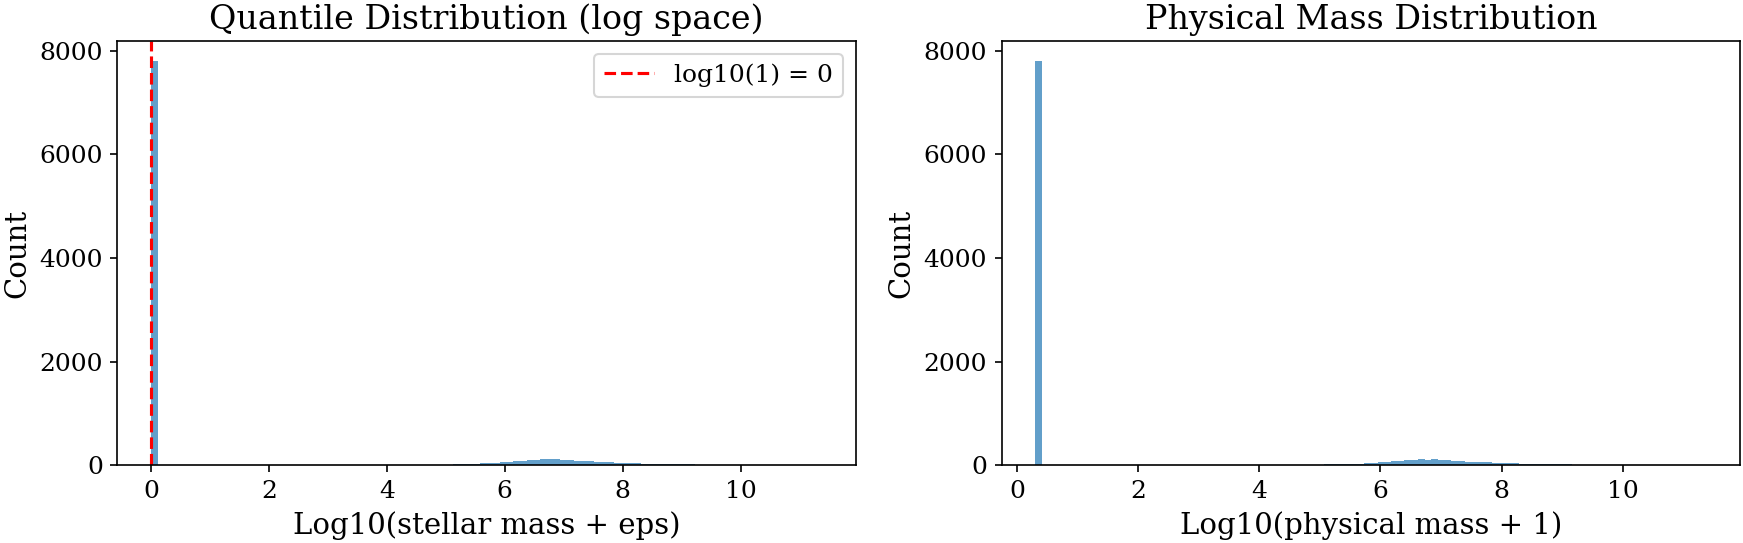


Fraction of quantiles with log10(mass) < 0 (mass < 1): 39.0%
Minimum quantile value: -0.000509
  -> Physical mass: 10^-0.000509 - eps = 9.99e-01


In [70]:
# Check the actual quantile transformer's quantile distribution
# This tells us what values it was trained on

print("Quantile transformer statistics:")
print(f"  quantiles_ range: [{quantile_normalizer.quantiles_.min():.4f}, {quantile_normalizer.quantiles_.max():.4f}]")
print(f"  Number of unique quantile values: {len(np.unique(quantile_normalizer.quantiles_))}")

# The quantiles are in LOG SPACE (log10)
# Check the distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(quantile_normalizer.quantiles_.flatten(), bins=100, alpha=0.7)
plt.xlabel('Log10(stellar mass + eps)')
plt.ylabel('Count')
plt.title('Quantile Distribution (log space)')
plt.axvline(0, color='red', ls='--', label='log10(1) = 0')
plt.legend()

plt.subplot(1, 2, 2)
# Show what physical values these correspond to
physical_values = 10 ** quantile_normalizer.quantiles_.flatten()
plt.hist(np.log10(physical_values + 1), bins=100, alpha=0.7)
plt.xlabel('Log10(physical mass + 1)')
plt.ylabel('Count')
plt.title('Physical Mass Distribution')

plt.tight_layout()
plt.show()

# What fraction of quantiles are below zero (i.e., mass < 1)?
below_zero = (quantile_normalizer.quantiles_ < 0).sum() / len(quantile_normalizer.quantiles_)
print(f"\nFraction of quantiles with log10(mass) < 0 (mass < 1): {100*below_zero:.1f}%")

# The minimum quantile
min_q = quantile_normalizer.quantiles_.min()
print(f"Minimum quantile value: {min_q:.6f}")
print(f"  -> Physical mass: 10^{min_q:.6f} - eps = {10**min_q - eps:.2e}")